# 01. EDA — ESS 배터리 수명 예측

- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- 목표: Batch 1 / 2 / 3의 특성을 비교하고, 그 결과를 근거로 모델 설계 전략을 세운다.

## 환경 설정

**목적**: 분석에 쓰는 라이브러리, 경로, 그래프 설정, 난수 시드를 한곳에 모아 재현 가능하게 한다.

In [9]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import mat73
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 경고 및 mat73의 string 타입 로딩 메시지 숨김
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.CRITICAL)

# 재현성
SEED = 42
np.random.seed(SEED)

# 경로
DATA_DIR = '../data'
PROC_DIR = '../data/processed'
FIG_DIR = '../results/figures'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# 그래프 설정 (한글 폰트 포함)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# 표 출력 설정
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 데이터 준비

**목적**: 세 배치의 사이클별 요약(`summary`)을 하나의 DataFrame으로 모은다.
원본 파일은 배치당 2~3GB라 매번 읽기 어려우므로, 추출 결과를 파일로 저장해 이후에는 그 파일만 사용한다.

In [10]:
def load_mat(path):
    """.mat 파일 로더. v7.3(HDF5)은 mat73, 그 이하는 scipy로 읽는다."""
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
    return data


def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환한다."""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d


def extract_summary(batch, batch_no):
    """배치 내 모든 셀의 summary를 사이클 단위 DataFrame으로 변환한다."""
    records = []
    for i, cell in enumerate(batch):
        s = cell['summary']
        qd = np.array(s['QDischarge'])
        qc = np.array(s['QCharge'])
        ir = np.array(s['IR'])
        tmax = np.array(s['Tmax'])
        tavg = np.array(s['Tavg'])
        tmin = np.array(s['Tmin'])
        ct = np.array(s['chargetime'])

        cycle_life = float(cell['cycle_life'])
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

        for c in range(len(qd)):
            records.append({
                'batch': batch_no,
                'cell_id': f'b{batch_no}c{i}',
                'cycle': c + 1,
                'cycle_life': cycle_life,
                'charging_policy': policy,
                'QD': qd[c],
                'QC': qc[c],
                'IR': ir[c],
                'Tmax': tmax[c],
                'Tavg': tavg[c],
                'Tmin': tmin[c],
                'chargetime': ct[c],
            })
    return pd.DataFrame(records)

**세 배치 로딩과 저장**

세 배치의 원본 파일을 하나씩 읽어 `summary`를 추출하고 하나의 DataFrame으로 합친 뒤 저장한다. 원본 파일을 읽는 데 약 5분이 걸리므로 최초 1회만 실행한다.

In [11]:
FILES = {
    1: '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    2: '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    3: '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

dfs = []
for b, fname in FILES.items():
    print(f'Batch {b} 로딩 중...')
    mat = load_mat(os.path.join(DATA_DIR, fname))
    batch = to_list_of_dicts(mat['batch'])
    dfs.append(extract_summary(batch, b))
    del mat, batch

df = pd.concat(dfs, ignore_index=True)
df.to_parquet(os.path.join(PROC_DIR, 'summary.parquet'))

print(df.shape)
print(df.groupby('batch')['cell_id'].nunique())

Batch 1 로딩 중...
Batch 2 로딩 중...
Batch 3 로딩 중...
(116722, 12)
batch
1    46
2    47
3    46
Name: cell_id, dtype: int64


**결과 해석**
- 세 배치를 합친 summary는 116,722행(사이클 단위), 12열이다.
- 셀 수는 Batch 1 46개, Batch 2 47개, Batch 3 46개로 총 139개다.
- 추출 결과를 `data/processed/summary.parquet`으로 저장했다. 이후 분석은 이 파일에서 시작한다.

In [12]:
df = pd.read_parquet(os.path.join(PROC_DIR, 'summary.parquet'))
df.head()

,batch,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,1,b1c0,1,1190.0,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,b1c0,2,1190.0,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,1,b1c0,3,1190.0,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,1,b1c0,4,1190.0,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,1,b1c0,5,1190.0,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


## Q1. Cycle Life 분포는 어떻게 생겼는가?

**목적**: 학습 배치(Batch 1)와 테스트 배치(Batch 2, 3)의 수명 분포를 비교한다.
- 분포의 범위와 형태는 배치마다 같은가
- 장수명(>1,000) / 단수명(<500) 셀의 비율은 어떤가
- 유독 짧거나 값이 이상한 셀이 있는가

In [13]:
cells = df.drop_duplicates('cell_id')[['batch', 'cell_id', 'cycle_life', 'charging_policy']].reset_index(drop=True)

print('수명 값이 없는 셀 수')
print(cells[cells['cycle_life'].isna()].groupby('batch').size())

cells.groupby('batch')['cycle_life'].describe().round(1)

수명 값이 없는 셀 수
batch
2    8
3    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1,46.0,844.7,184.6,534.0,703.2,858.5,914.2,1227.0
2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


**결과 해석 — 기술통계**

- **수명 값이 없는 셀이 있다.** Batch 2에서 8개, Batch 3에서 2개. 어떤 셀인지는 아래에서 확인한다.
- **세 배치의 수명 수준이 다르다.** 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
- **Batch 2는 한쪽으로 치우친 분포다.** 75% 지점이 508.5인데 최댓값은 1,186이고, 평균(565.7)이 중앙값(472)보다 크다. 대부분의 셀이 400~500대에 몰려 있고 일부만 멀리 떨어져 있다.
- **Batch 2의 대부분은 Batch 1의 범위 밖이다.** Batch 1의 최솟값은 534인데, Batch 2는 75% 지점이 508.5다. Batch 2 셀의 4분의 3 이상이 Batch 1에서 가장 짧은 셀보다 수명이 짧다.

**시사점**: Batch 1로 학습해 Batch 2를 평가하면, 모델은 학습 때 본 적 없는 짧은 수명 구간을 예측해야 한다.

In [14]:
cells[cells['cycle_life'].isna()]

,batch,cell_id,cycle_life,charging_policy
68,2,b2c22,NaN,VarCharge-2C-100cycles
69,2,b2c23,NaN,VarCharge-4C-100cycles
81,2,b2c35,NaN,VarCharge-6C-100cycles
82,2,b2c36,NaN,VarCharge-8C-100cycles
83,2,b2c37,NaN,3.6C(80%)-3.6C(SLOWCYCLE
84,2,b2c38,NaN,4.8C(80%)-4.8C(SLOWCYCLE
85,2,b2c39,NaN,3.6C(9%)-5C(SLOWCYCLE
86,2,b2c40,NaN,5.2C(58%)-4C(SLOWCYCLE
116,3,b3c23,NaN,4.8C(80%)-4.8C-newstructure
125,3,b3c32,NaN,4.8C(80%)-4.8C-newstructure


**결과 해석 — 수명 값이 없는 셀**

- **Batch 2의 8셀은 이름부터 다른 실험이다.** 충전 정책이 `VarCharge-...` (4셀)과 `...(SLOWCYCLE` (4셀)로 표기되어 있다. 다른 셀들의 정책 표기(`C1(Q1%)-C2`)와 형식이 다르다.
- **Batch 3의 2셀은 정책 표기가 정상이다.** 둘 다 `4.8C(80%)-4.8C-newstructure`로, 수명 값만 비어 있다. 왜 비어 있는지는 이 표만으로는 알 수 없다.

**결정**: 수명 값이 없는 10셀은 타깃이 없어 수명 예측의 학습·평가에 쓸 수 없으므로 분석 대상에서 제외한다.
Batch 3의 2셀이 왜 비어 있는지는 열화 곡선(Q2)에서 확인한다.

In [17]:
cells['newstructure'] = cells['charging_policy'].str.contains('newstructure')
cells.groupby(['batch', 'newstructure']).size()

batch  newstructure
1      False           46
2      False           38
       True             9
3      True            46
dtype: int64

**결과 해석 — `newstructure` 표기**

- Batch 1은 전부 표기가 없고, Batch 3은 전부 `newstructure`다.
- **Batch 2에는 두 부류가 섞여 있다**: 표기 없는 38셀과 `newstructure` 9셀.
- 이 표기가 무엇을 의미하는지는 데이터에 설명이 없다. 다만 Batch 2의 9셀이 Batch 3과 같은 표기를 공유하므로, Batch 2를 하나의 균일한 집단으로 보기 전에 두 부류의 수명이 같은지 확인할 필요가 있다.

In [18]:
cells.dropna(subset=['cycle_life']).groupby(['batch', 'newstructure'])['cycle_life'].describe().round(1)

count    mean    std    min    25%     50%     75%     max
batch newstructure                                                            
1     False          46.0   844.7  184.6  534.0  703.2   858.5   914.2  1227.0
2     False          30.0   453.0   34.8  392.0  425.2   451.0   476.2   514.0
      True            9.0   941.6  153.6  777.0  809.0   904.0  1029.0  1186.0
3     True           44.0  1059.7  313.9  541.0  828.0  1005.5  1155.2  1935.0

**결과 해석 — Batch 2 안의 두 집단**

- **Batch 2의 두 부류는 수명 범위가 겹치지 않는다.** 표기 없는 30셀은 392~514, `newstructure` 9셀은 777~1,186이다.
- **표기 없는 30셀은 수명이 매우 균일하다.** 표준편차가 34.8로, Batch 1(184.6)이나 Batch 3(313.9)보다 훨씬 작다.
- **`newstructure` 9셀은 Batch 3과 수준이 비슷하다.** 중앙값이 904로 Batch 3(1,005.5)에 가깝고, Batch 2의 나머지 셀(451)과는 2배 차이가 난다.
- Batch 2 전체 통계에서 평균(565.7)이 중앙값(472)보다 컸던 것은 한쪽으로 치우친 분포여서가 아니라, **성격이 다른 두 집단이 섞여 있었기 때문**이다.

**시사점**
- Batch 2를 하나의 집단으로 평가하면 두 집단의 결과가 섞여 해석이 어렵다. 테스트 성능은 Batch 2 전체와 함께 **두 집단으로 나눠서** 본다.
- Batch 1의 최소 수명은 534인데, Batch 2의 표기 없는 30셀은 최대가 514다. 이 30셀은 **전부 Batch 1의 수명 범위 밖**에 있다.

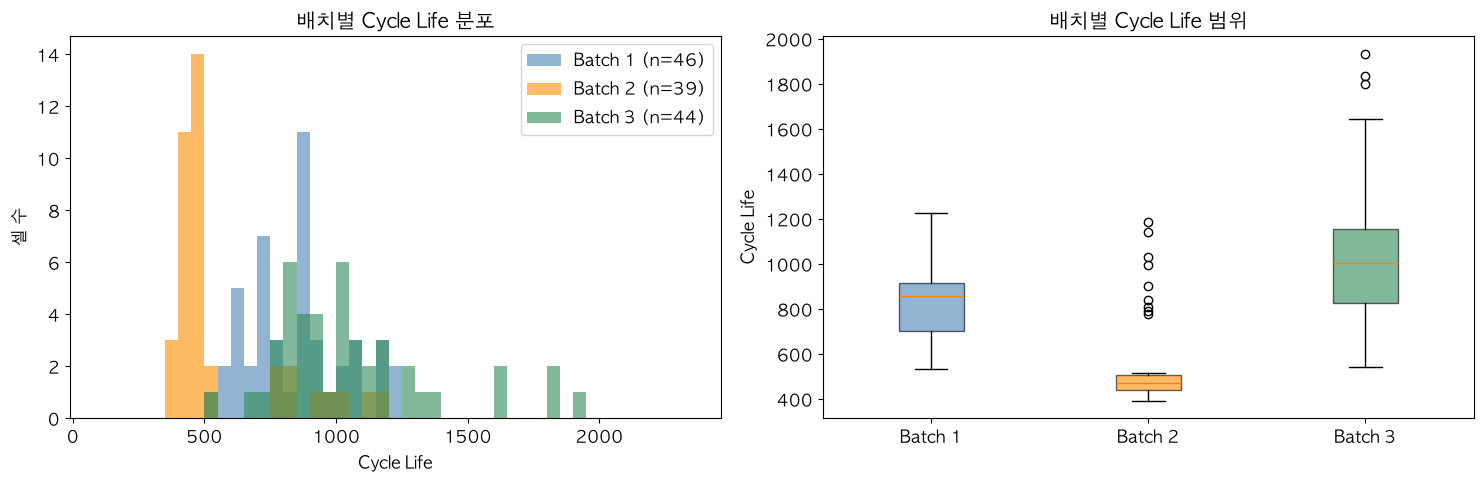

In [15]:
colors = {1: 'steelblue', 2: 'darkorange', 3: 'seagreen'}
bins = np.arange(100, 2400, 50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for b in [1, 2, 3]:
    life = cells.loc[cells['batch'] == b, 'cycle_life'].dropna()
    axes[0].hist(life, bins=bins, alpha=0.6, color=colors[b], label=f'Batch {b} (n={len(life)})')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('셀 수')
axes[0].set_title('배치별 Cycle Life 분포')
axes[0].legend()

data = [cells.loc[cells['batch'] == b, 'cycle_life'].dropna() for b in [1, 2, 3]]
bp = axes[1].boxplot(data, tick_labels=['Batch 1', 'Batch 2', 'Batch 3'], patch_artist=True)
for patch, b in zip(bp['boxes'], [1, 2, 3]):
    patch.set(facecolor=colors[b], alpha=0.6)
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('배치별 Cycle Life 범위')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q1_cycle_life.png'), dpi=150)
plt.show()

**결과 해석 — 분포 그래프**

- **Batch 1과 Batch 2는 거의 겹치지 않는다.** Batch 2의 대부분은 350~550 구간에 몰려 있고, Batch 1은 그 오른쪽인 534부터 시작한다.
- **박스플롯이 Batch 2의 이상치로 표시한 9개 점은 이상치가 아니다.** 앞에서 확인한 `newstructure` 9셀(777~1,186)과 일치한다. 값이 튀는 개별 셀이 아니라 성격이 다른 집단이다.
- **Batch 3은 범위가 가장 넓다.** 541~1,935에 걸쳐 있고, 1,600 이상인 셀이 일부 있어 오른쪽 꼬리가 길다.
- 세 배치 모두 Batch 1과 겹치는 구간(약 550~1,200)에 셀이 있지만, 그 밖의 구간은 Batch 2(짧은 쪽)와 Batch 3(긴 쪽)에만 있다.

**시사점**: 학습 배치의 수명 범위(534~1,227)보다 테스트 배치의 범위가 양쪽으로 더 넓다. Batch 2는 짧은 쪽으로, Batch 3은 긴 쪽으로 학습 범위를 벗어난다.

In [19]:
ratio = cells.dropna(subset=['cycle_life']).groupby('batch')['cycle_life'].agg(
    셀수='size',
    단수명_500미만=lambda x: (x < 500).sum(),
    장수명_1000초과=lambda x: (x > 1000).sum(),
    분류기준_550미만=lambda x: (x < 550).sum(),
)
ratio

,셀수,단수명_500미만,장수명_1000초과,분류기준_550미만
batch,,,,
1,46,0,10,1
2,39,28,3,30
3,44,0,23,1


**결과 해석 — 장수명/단수명 비율**

- **단수명(<500) 셀은 Batch 2에만 있다.** Batch 2는 39셀 중 28셀이 단수명이고, Batch 1과 Batch 3에는 한 개도 없다.
- **장수명(>1,000) 셀은 Batch 3에 가장 많다.** Batch 3은 44셀 중 23셀, Batch 1은 46셀 중 10셀, Batch 2는 39셀 중 3셀이다.
- **분류 기준(550사이클)으로 나누면 Batch 1에는 단수명 클래스가 1개뿐이다.** 46셀 중 45셀이 장수명 클래스다. 반면 Batch 2는 39셀 중 30셀이 단수명 클래스다.

**시사점**: Batch 1로 분류 모델을 학습하면 단수명 클래스의 표본이 1개라 그 클래스의 특징을 배울 수 없다. 그런데 테스트 배치(Batch 2)는 대부분이 단수명 클래스다. 과제 조건(Batch 1 학습 → Batch 2 평가)에서는 **Classification이 성립하지 않는다.**

### Q1 결론

**확인한 사실**
1. 수명 값이 없는 셀이 10개 있다. Batch 2의 8셀은 다른 실험(`VarCharge`, `SLOWCYCLE`)이고, Batch 3의 2셀은 원인 미확인이다.
2. 세 배치의 수명 분포가 다르다. 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
3. Batch 2는 두 집단의 혼합이다. 표기 없는 30셀(392~514)과 `newstructure` 9셀(777~1,186)의 수명 범위가 겹치지 않는다.
4. Batch 2의 표기 없는 30셀은 전부 Batch 1의 최소 수명(534)보다 짧다.
5. 분류 기준 550사이클 미만인 셀이 Batch 1에는 1개뿐이다.

**모델 설계에 주는 시사점**
- **Regression을 선택한다.** Batch 1에는 단수명 클래스가 1개뿐이라 분류 모델을 학습할 수 없다. (사실 5)
- **학습 범위 밖을 예측해야 하는 문제다.** 테스트 셀의 다수가 학습 배치의 수명 범위 밖에 있으므로, 모델을 고를 때 학습 범위 밖에서도 예측이 가능한지를 기준에 넣는다. (사실 2, 4)
- **테스트 성능은 Batch 2의 두 집단을 나눠서 본다.** (사실 3)

**남은 질문**
- Batch 3의 2셀은 왜 수명 값이 없는가 → Q2에서 열화 곡선으로 확인
- Batch 1의 `cycle_life` 46개는 모두 실제 EOL 도달 시점인가 → Q2에서 확인
- `newstructure`는 무엇을 의미하며, Batch 2의 두 집단은 왜 수명이 다른가

> **수정 (Q2-3 이후)**: Batch 1의 10셀이 EOL 미도달로 확인되어 제외했다. Batch 1의 통계는 36셀 기준으로 중앙값 772.5, 범위 534~1,074다. Q1의 결론(Regression 선택, 학습 범위 밖 예측, Batch 2 두 집단)은 그대로 유지된다.

## Q2. 열화 곡선: 방전 용량은 어떻게 감소하는가?

**목적**: 사이클이 진행됨에 따라 방전 용량(QD)이 어떻게 줄어드는지 배치별로 확인한다.
- 열화 속도는 일정한가, 중간에 가속되는가
- 급격한 열화가 시작되는 지점(knee point)은 어디인가
- 모델이 사용할 초기 100사이클 구간에서 셀 간 차이가 보이는가
- (Q1의 남은 질문) `cycle_life` 값은 실제 EOL 도달 시점과 일치하는가

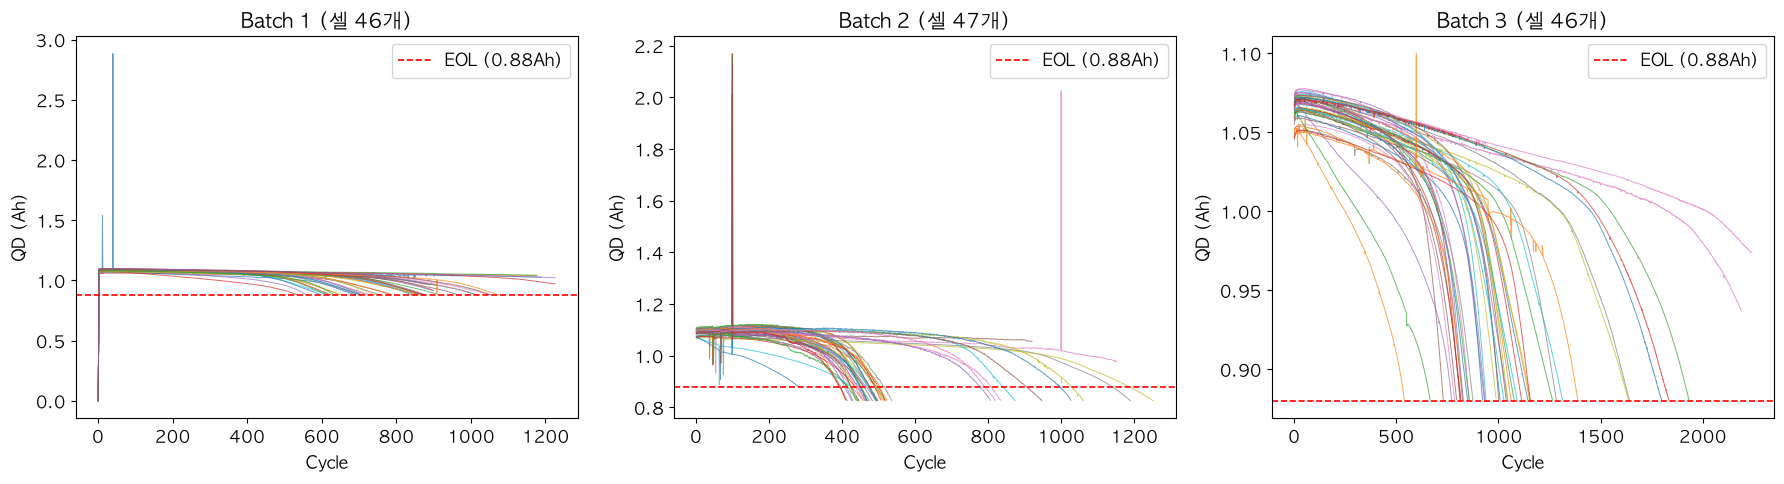

In [20]:
EOL = 0.88   # 공칭 용량 1.1Ah의 80%

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, b in zip(axes, [1, 2, 3]):
    sub = df[df['batch'] == b]
    for cid, g in sub.groupby('cell_id'):
        ax.plot(g['cycle'], g['QD'], linewidth=0.7, alpha=0.7)
    ax.axhline(EOL, color='red', linestyle='--', linewidth=1.2, label='EOL (0.88Ah)')
    ax.set_title(f'Batch {b} (셀 {sub["cell_id"].nunique()}개)')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('QD (Ah)')
    ax.legend()

plt.tight_layout()
plt.show()

**결과 해석 — 원본 열화 곡선**

- **측정 오류로 보이는 값이 있다.** Batch 1에는 0Ah와 1.5~2.9Ah, Batch 2에는 2Ah 이상의 값이 있다. 공칭 용량 1.1Ah인 셀에서 나올 수 없는 값이므로 열화 분석 전에 걸러야 한다.
- **곡선이 끝나는 높이가 배치마다 다르다.** Batch 3은 0.88Ah 부근에서 끝나고, Batch 2는 그 아래(약 0.83Ah)까지 내려간 뒤 끝난다. 시험을 멈춘 기준이 배치마다 달랐던 것으로 보인다.
- **EOL 선에 닿지 않고 끝나는 곡선이 있다.** Batch 3에서 2,000사이클을 넘긴 2개 곡선은 0.94~0.97Ah에서 끝난다. Batch 1과 Batch 2에도 1.0Ah 부근에서 끝나는 곡선이 보인다.

**다음 단계**: 이상값을 걸러낸 뒤 다시 그리고, 셀별로 마지막 방전 용량을 확인해 EOL 도달 여부를 판정한다.

**이상값 범위 탐색**

원본 그래프에서 본 튀는 값이 정상 값과 얼마나 떨어져 있는지 확인한다. 정상 값과 이상값 사이에 빈 구간이 있으면, 그 구간을 기준으로 삼을 수 있다.

In [22]:
print(df['QD'].describe())
print(df['QD'].quantile([0, 0.0001, 0.001, 0.01, 0.5, 0.99, 0.999, 0.9999, 1]))

count    116722.000000
mean          1.038783
std           0.055874
min           0.000000
25%           1.022585
50%           1.053118
75%           1.071628
max           2.884085
Name: QD, dtype: float64
0.0000    0.000000
0.0001    0.000000
0.0010    0.829123
0.0100    0.881012
0.5000    1.053118
0.9900    1.108376
0.9990    1.118073
0.9999    1.694559
1.0000    2.884085
Name: QD, dtype: float64


**범위 밖 값 나열**

분위수만으로는 이상값이 정상 값과 얼마나 떨어져 있는지 알기 어렵다. 0.8Ah 미만과 1.15Ah 초과인 값을 직접 나열해, 그 사이에 값이 없는 구간이 있는지 확인한다. 0.8과 1.15는 기준이 아니라 탐색을 위해 넉넉하게 잡은 값이다.

In [23]:
print('QD < 0.8 인 값들:')
print(df.loc[df['QD'] < 0.8, 'QD'].sort_values().round(3).tolist())
print('QD > 1.15 인 값들:')
print(df.loc[df['QD'] > 1.15, 'QD'].sort_values().round(3).tolist())

QD < 0.8 인 값들:
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
QD > 1.15 인 값들:
[1.539, 2.013, 2.026, 2.061, 2.127, 2.15, 2.162, 2.162, 2.165, 2.167, 2.168, 2.169, 2.884]


**QD가 0인 행의 위치 확인**

0.0인 값이 46개로 Batch 1의 셀 수와 같다. 무작위로 흩어진 오류인지, 특정 배치와 사이클에 몰려 있는지 확인한다.

In [24]:
df[df['QD'] == 0].groupby(['batch', 'cycle']).size()

batch  cycle
1      1        46
dtype: int64

### Q2-1. 이상값 기준과 EOL 도달 여부

**목적**: 측정 오류로 보이는 QD 값을 걸러내고, 각 셀이 실제로 EOL(0.88Ah)에 도달했는지 마지막 방전 용량으로 판정한다.

**기준을 정한 과정**

1. 원본 열화 곡선에서 0Ah 부근과 2Ah 이상으로 튀는 값을 확인했다. 공칭 용량이 1.1Ah인 셀에서 나올 수 없는 값이다.
2. QD 전체 분포를 확인했다.
   - 0.8Ah 미만인 값은 46개이고 전부 0.0이다. 그다음으로 작은 값은 약 0.82Ah다.
   - 1.15Ah 초과인 값은 13개이고 가장 작은 것이 1.539Ah다. 정상 값은 약 1.12Ah에서 끝난다.
3. QD가 0인 46개 행은 전부 Batch 1의 `cycle` 1이다. 무작위 오류가 아니라 Batch 1의 첫 사이클 기록이 비어 있는 구조적 특징이다.

**정상 범위: 0.8Ah ≤ QD ≤ 1.15Ah**

- 0~0.82Ah와 1.12~1.54Ah 구간에 값이 하나도 없다. 기준을 이 구간 안 어디에 두어도 걸러지는 행은 같은 59개(0.0인 46개, 1.5Ah 이상인 13개)다.
- 하한 0.8Ah: Batch 2는 0.88Ah 아래 약 0.83Ah까지 열화가 진행된 뒤 시험이 끝난다. 이 구간은 정상 데이터이므로 남겨야 한다.
- 상한 1.15Ah: 초기 방전 용량이 약 1.05~1.11Ah이므로 그보다 조금 위에 두었다.
- 스크래치 노트북의 기준(공칭 용량의 ±20%, 0.864~1.296Ah)은 쓰지 않았다. Batch 1만 볼 때는 문제가 없지만, Batch 2에 적용하면 0.83~0.864Ah 구간의 정상 열화 데이터가 잘려 나간다.

**EOL 도달 판정**: 이상값을 제외한 마지막 QD가 0.885Ah 이하이면 도달한 것으로 본다. 0.88Ah 바로 위에서 시험이 끝난 셀을 포함하기 위해 0.005Ah의 여유를 두었다.

In [25]:
QD_MIN, QD_MAX = 0.8, 1.15   # 직접 정한 정상 범위

df['qd_ok'] = df['QD'].between(QD_MIN, QD_MAX)
print('범위 밖 행 수:', (~df['qd_ok']).sum(), '/', len(df))
print(df[~df['qd_ok']].groupby('batch').size())

last = (df[df['qd_ok']]
        .groupby('cell_id')
        .agg(n_cycles=('cycle', 'max'), qd_last=('QD', 'last'))
        .reset_index())
cells2 = cells.merge(last, on='cell_id')
cells2['reached_eol'] = cells2['qd_last'] <= 0.885

cells2.groupby(['batch', 'reached_eol']).size()

범위 밖 행 수: 59 / 116722
batch
1    48
2    11
dtype: int64


batch  reached_eol
1      False          10
       True           36
2      False           4
       True           43
3      False           2
       True           44
dtype: int64

**결과 해석 — 이상값과 EOL 도달 여부**

- 범위 밖 행은 59개(전체의 0.05%)다. Batch 1의 48개는 첫 사이클의 0.0 값 46개와 스파이크 2개이고, Batch 2의 11개는 2Ah 이상의 스파이크다. Batch 3에는 없다.
- **EOL(0.88Ah)에 도달하지 않은 셀이 16개 있다.** Batch 1 10셀, Batch 2 4셀, Batch 3 2셀.
- **Batch 1의 10셀은 `cycle_life` 값이 있는데도 EOL에 도달하지 않았다.** Q1에서 Batch 1은 46셀 모두 수명 값이 있었다. 이 10셀의 `cycle_life`가 무엇을 뜻하는지 확인이 필요하다.

### Q2-2. EOL에 도달하지 않은 셀 확인

**목적**: EOL 미도달로 판정된 16셀이 어떤 셀인지 확인한다.
- Batch 1의 10셀은 `cycle_life` 값이 있는데 왜 EOL에 도달하지 않았는가
- Batch 2, 3의 미도달 셀은 Q1에서 수명 값이 없던 셀과 같은가

In [26]:
cols = ['batch', 'cell_id', 'charging_policy', 'cycle_life', 'n_cycles', 'qd_last']
cells2[~cells2['reached_eol']][cols].round(3)

,batch,cell_id,charging_policy,cycle_life,n_cycles,qd_last
0,1,b1c0,3.6C(80%)-3.6C,1190.0,1189,1.026
1,1,b1c1,3.6C(80%)-3.6C,1179.0,1178,1.038
2,1,b1c2,3.6C(80%)-3.6C,1177.0,1176,1.043
3,1,b1c3,4C(80%)-4C,1226.0,1225,0.971
4,1,b1c4,4C(80%)-4C,1227.0,1226,1.022
8,1,b1c8,5.4C(40%)-3.6C,879.0,878,0.969
10,1,b1c10,5.4C(50%)-3C,906.0,905,0.961
12,1,b1c12,5.4C(50%)-3.6C,902.0,901,0.913
13,1,b1c13,5.4C(50%)-3.6C,897.0,896,0.923
22,1,b1c22,6C(30%)-3.6C,891.0,890,0.963


**결과 해석 — EOL 미도달 16셀**

**Batch 1의 10셀: `cycle_life`는 수명이 아니라 시험 종료 시점이다.**
- 10셀 모두 `cycle_life` = `n_cycles` + 1이다. (예: 1190과 1189, 879와 878)
- 마지막 방전 용량은 0.913~1.043Ah로, EOL 기준 0.88Ah에 도달하지 않았다.
- 실제 수명은 기록된 값보다 길다. 얼마나 긴지는 이 데이터로 알 수 없다.
- 가장 느린 충전 정책인 `3.6C(80%)-3.6C` 3셀과 `4C(80%)-4C` 2셀이 모두 여기에 포함된다. 기록상 수명이 가장 긴 5셀(1,177~1,227)이 전부 중도절단된 값이다.

**Batch 2의 4셀과 Batch 3의 2셀**: Q1에서 수명 값이 없던 셀이다.
- Batch 3의 2셀(b3c23, b3c32)은 2,189 / 2,237사이클까지 진행했지만 마지막 용량이 0.937 / 0.974Ah다. EOL에 도달하지 않아 수명 값이 비어 있었던 것이다. (Q1의 남은 질문에 대한 답)
- Batch 2의 4셀은 `VarCharge`, `SLOWCYCLE` 실험 셀이다.

**결정**
- EOL 도달이 확인된 셀만 분석에 사용한다. Batch 1에서 10셀을 제외해 36셀이 남는다.
- 중도절단된 값을 수명으로 학습하면 실제보다 짧은 수명을 정답으로 가르치게 된다. 특히 장수명 구간의 정답이 전부 왜곡된다.
- Q1에서 계산한 Batch 1의 통계는 이 10셀이 포함된 값이므로 다시 계산한다.

### Q2-3. 분석 대상 셀 확정

**목적**: 수명 예측에 쓸 수 있는 셀을 확정하고, Q1의 배치별 통계를 다시 계산한다.

**선별 조건**: 수명 값이 있고(`cycle_life` 결측 아님) EOL에 도달한 셀(`reached_eol`).
- EOL 도달 여부만으로는 부족하다. Batch 2의 다른 실험 셀 8개 중 4개는 EOL에 도달했지만 수명 값이 없다.

In [27]:
cells2['use'] = cells2['reached_eol'] & cells2['cycle_life'].notna()
print(cells2.groupby('batch')['use'].agg(['sum', 'size']))

cells2[cells2['use']].groupby('batch')['cycle_life'].describe().round(1)

       sum  size
batch           
1       36    46
2       39    47
3       44    46


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1,36.0,788.4,148.7,534.0,681.0,772.5,871.5,1074.0
2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


**결과 해석 — 분석 대상 셀 확정**

- 분석 대상은 **Batch 1 36셀, Batch 2 39셀, Batch 3 44셀**, 총 119셀이다. 전체 139셀 중 20셀을 제외했다.
- Batch 2와 Batch 3의 통계는 Q1과 같다. 제외된 셀은 원래 수명 값이 없어 Q1 통계에 포함되지 않았기 때문이다.
- **Batch 1의 통계는 달라졌다.** 중앙값이 858.5에서 772.5로, 최댓값이 1,227에서 1,074로 내려갔다. 기록상 수명이 길었던 셀 다수가 중도절단된 값이었다.
- Batch 1의 최솟값은 534로 변함없다. Batch 2 일반 30셀(최대 514)이 전부 Batch 1의 수명 범위 밖이라는 Q1의 결론은 유지된다.

**시사점**
- 학습 데이터의 수명 범위는 **534~1,074**다. Q1에서 본 것보다 위쪽이 좁아졌다.
- Batch 3은 최대 1,935까지 있으므로, Batch 3에서는 긴 쪽으로도 학습 범위를 벗어나는 셀이 더 많아진다.
- 학습 셀이 36개로 적다. 모델 복잡도를 정할 때 고려해야 한다.

In [88]:
u = cells2[cells2['use']]
print(u.groupby('batch')['cycle_life'].agg(
    셀수='size',
    단수명_500미만=lambda x: (x < 500).sum(),
    장수명_1000초과=lambda x: (x > 1000).sum(),
    분류기준_550미만=lambda x: (x < 550).sum()))

       셀수  단수명_500미만  장수명_1000초과  분류기준_550미만
batch                                       
1      36          0           5           1
2      39         28           3          30
3      44          0          23           1


### Q2-4. 정제 후 열화 곡선

**목적**: 이상값과 분석 대상이 아닌 셀을 제외한 뒤 열화 곡선을 다시 그려, Q2의 원래 질문에 답한다.
- 열화 속도는 일정한가, 중간에 가속되는가
- 모델이 사용할 초기 100사이클 구간에서 셀 간 차이가 보이는가

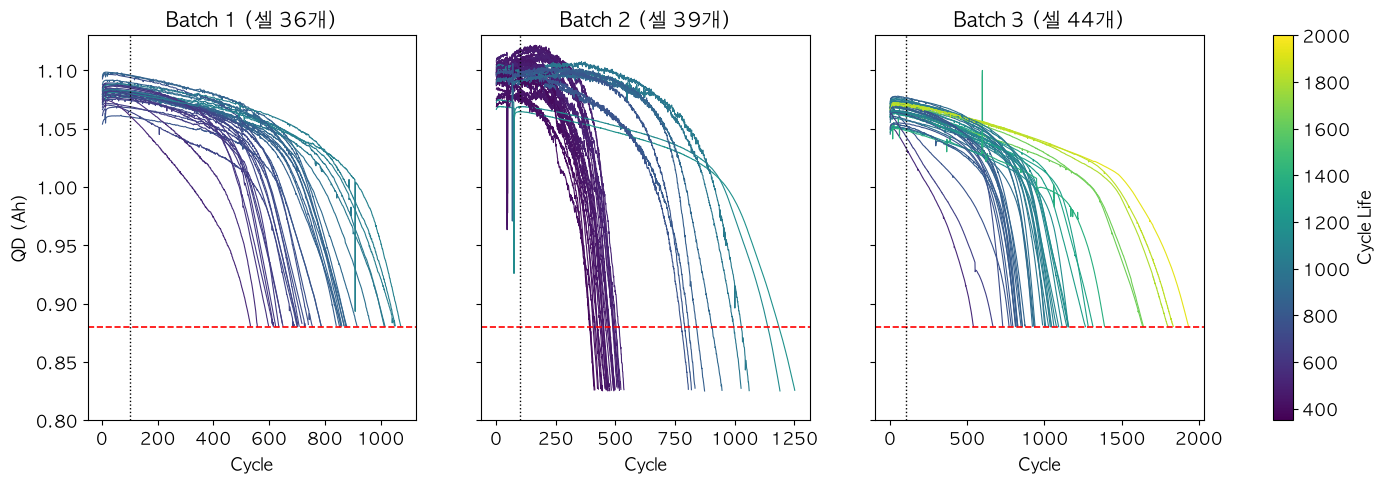

In [28]:
use_ids = cells2.loc[cells2['use'], 'cell_id']
d = df[df['cell_id'].isin(use_ids) & df['qd_ok']]

norm = plt.Normalize(350, 2000)
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, [1, 2, 3]):
    sub = d[d['batch'] == b]
    for cid, g in sub.groupby('cell_id'):
        ax.plot(g['cycle'], g['QD'], color=cmap(norm(g['cycle_life'].iloc[0])), linewidth=0.8)
    ax.axhline(EOL, color='red', linestyle='--', linewidth=1.2)
    ax.axvline(100, color='black', linestyle=':', linewidth=1)
    ax.set_title(f'Batch {b} (셀 {sub["cell_id"].nunique()}개)')
    ax.set_xlabel('Cycle')
    ax.set_ylim(0.8, 1.13)
axes[0].set_ylabel('QD (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='Cycle Life')
plt.savefig(os.path.join(FIG_DIR, 'q2_fade_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — 정제 후 열화 곡선**

- **열화 속도는 일정하지 않다.** 세 배치 모두 초반에는 완만하게 줄다가, 특정 지점부터 급격히 꺾여 EOL에 도달한다. 직선이 아니라 무릎(knee) 모양이다.
- **초기 100사이클에서는 수명이 긴 셀과 짧은 셀이 구분되지 않는다.** 곡선들이 한 덩어리로 겹쳐 있고, 갈라지는 것은 100사이클을 한참 지난 뒤다.
- **배치마다 초기 용량 수준이 다르다.** Batch 2가 가장 높고(약 1.07~1.11Ah) Batch 3이 가장 낮다(약 1.05~1.08Ah).
- Batch 2의 일부 셀은 초반 100~200사이클에서 용량이 오히려 증가한다.
- 정상 범위 안에 있는 스파이크가 일부 남아 있다(Batch 2의 사이클 50~80 부근, Batch 3의 사이클 600 부근).

**시사점**
- 모델이 쓸 수 있는 초기 100사이클 구간에서, 방전 용량 값 자체는 수명을 구분하는 신호가 되기 어렵다.
- 배치마다 초기 용량 수준이 다르므로, 용량의 절댓값을 피처로 쓰면 배치 차이가 섞여 들어갈 수 있다.

### Q2-5. 정상 범위 안의 스파이크 처리

**목적**: Q2-4 그래프에서 정상 범위(0.8~1.15Ah) 안에 남아 있는 스파이크를 찾아낸다.
고정 범위로는 잡을 수 없으므로, 각 셀에서 주변 사이클의 중앙값과 비교해 벗어난 정도를 계산한다.
먼저 벗어난 정도의 분포를 보고 기준을 정한다.

**Q2-1의 절대 범위와의 관계**: 절대 범위는 물리적으로 나올 수 없는 값(0.0, 1.5Ah 이상)을 걸러내지만, 값 하나만 보기 때문에 범위 안에서 앞뒤 흐름과 어긋나는 값은 잡지 못한다. 예를 들어 0.95Ah는 수명 후반에는 정상 값이지만 초반에는 스파이크다. 이 단계는 절대 범위를 대체하는 것이 아니라, 그 뒤에 적용하는 두 번째 필터다.

In [30]:
d = d.sort_values(['cell_id', 'cycle']).copy()
d['qd_med'] = d.groupby('cell_id')['QD'].transform(
    lambda x: x.rolling(11, center=True, min_periods=1).median())
d['qd_dev'] = (d['QD'] - d['qd_med']).abs()

print(d['qd_dev'].quantile([0.5, 0.9, 0.99, 0.999, 0.9999, 1]).round(4))
print()
print('편차가 큰 상위 20개 행')
print(d.nlargest(20, 'qd_dev')[['batch', 'cell_id', 'cycle', 'QD', 'qd_med', 'qd_dev']].round(4))

0.5000    0.0000
0.9000    0.0007
0.9900    0.0025
0.9990    0.0056
0.9999    0.0640
1.0000    0.1403
Name: qd_dev, dtype: float64

편차가 큰 상위 20개 행
        batch cell_id  cycle      QD  qd_med  qd_dev
57104       2   b2c33     75  0.9258  1.0661  0.1403
45230       2   b2c11     46  0.9633  1.1011  0.1378
42967       2    b2c8     68  0.9707  1.0891  0.1184
6902        1    b1c5    909  0.8933  1.0040  0.1107
44712       2   b2c10     47  0.9990  1.1081  0.1091
41287       2    b2c5     48  0.9776  1.0832  0.1056
49928       2   b2c21     48  0.9943  1.0997  0.1053
39866       2    b2c2     47  0.9673  1.0696  0.1024
64233       2   b2c45     69  1.0218  1.0992  0.0774
105836      3   b3c37    598  1.0998  1.0310  0.0688
105835      3   b3c37    597  1.0937  1.0310  0.0628
63230       2   b2c43   1001  0.8961  0.9151  0.0190
48055       2   b2c17     53  1.1099  1.0944  0.0156
62778       2   b2c43    549  1.0736  1.0864  0.0128
106302      3   b3c37   1064  0.9825  0.9950  0.0125
42163

**결과 해석 — 주변 값과의 편차**

- 정상적인 사이클 간 변동은 매우 작다. 99%의 행에서 편차가 0.0025Ah 이하이고, 99.9%에서 0.0056Ah 이하다.
- 편차 상위 11개 행만 동떨어져 있다. 편차가 0.063~0.140Ah이고, 그다음 값(0.019Ah)과의 사이가 비어 있다.
- 편차 0.02Ah 이하인 행들은 대부분 수명 끝(QD 약 0.83Ah)의 급격한 열화 구간이다. 스파이크가 아니다.

**스파이크 제거**: 비어 있는 구간(0.019~0.063Ah) 안에 기준을 두고, 그보다 편차가 큰 행을 제외한다.

In [36]:
DEV_MAX = 0.04   # 직접 정한 기준

d['spike'] = d['qd_dev'] > DEV_MAX
print('스파이크 행 수:', d['spike'].sum())
print(d[d['spike']].groupby('batch').size())
print('초기 100사이클 안:', (d['spike'] & (d['cycle'] <= 100)).sum())

d_clean = d[~d['spike']].copy()

스파이크 행 수: 11
batch
1    1
2    8
3    2
dtype: int64
초기 100사이클 안: 8


**결과 해석 — 스파이크 제거**

- 스파이크로 판정된 행은 **11개**다. Batch 1 1개, Batch 2 8개, Batch 3 2개.
- 그중 **8개가 초기 100사이클 안**에 있고, 전부 Batch 2다(사이클 46~75). 그대로 두었다면 초기 사이클로 만드는 피처에 직접 영향을 주었을 값이다.
- 제거 후 데이터(`d_clean`)는 절대 범위와 주변 값 비교, 두 단계의 필터를 모두 거친 상태다.

**기준**: 주변 11사이클 중앙값과의 차이가 0.04Ah를 넘는 행을 스파이크로 본다.
- 편차 0.019~0.063Ah 구간에 값이 없으므로, 기준을 이 안 어디에 두어도 제외되는 행은 같은 11개다.
- 편차 0.02Ah 이하인 행은 수명 끝의 급격한 열화 구간이므로 정상 데이터로 남긴다.

**정제 요약**: 전체 116,722행 중 절대 범위로 59행, 주변 값 비교로 11행을 제외했다.

### Q2-6. 초기 100사이클의 용량 변화

**목적**: Q2-4 그래프에서 본 "초기 100사이클에서는 셀 간 차이가 보이지 않는다"를 숫자로 확인한다.
- 2번째 사이클 대비 100번째 사이클의 방전 용량은 얼마나 변했는가
- 그 변화량은 수명과 관련이 있는가

Batch 1은 첫 사이클 기록이 비어 있으므로, 세 배치에 같은 구간을 적용하기 위해 사이클 2~100을 사용한다.

In [37]:
early = d_clean[d_clean['cycle'].between(2, 100)]
chg = early.groupby('cell_id').agg(
    batch=('batch', 'first'),
    cycle_life=('cycle_life', 'first'),
    qd_first=('QD', 'first'),
    qd_100=('QD', 'last'),
).reset_index()
chg['qd_change'] = chg['qd_100'] - chg['qd_first']

print(chg.groupby('batch')['qd_change'].describe().round(4))
print()
print('용량이 줄지 않은 셀의 비율')
print(chg.groupby('batch')['qd_change'].apply(lambda x: (x >= 0).mean()).round(2))
print()
print('qd_change와 cycle_life의 상관계수')
print(chg.groupby('batch').apply(lambda g: g['qd_change'].corr(g['cycle_life'])).round(2))

       count    mean     std     min     25%     50%     75%     max
batch                                                               
1       36.0  0.0020  0.0032 -0.0114  0.0017  0.0024  0.0033  0.0066
2       39.0  0.0021  0.0067 -0.0229 -0.0010  0.0022  0.0069  0.0128
3       44.0  0.0002  0.0049 -0.0188  0.0004  0.0014  0.0023  0.0038

용량이 줄지 않은 셀의 비율
batch
1    0.89
2    0.64
3    0.84
Name: qd_change, dtype: float64

qd_change와 cycle_life의 상관계수
batch
1    0.47
2   -0.20
3    0.28
dtype: float64


**결과 해석 — 초기 100사이클의 용량 변화**

- **초기 100사이클 동안 방전 용량은 거의 변하지 않는다.** 변화량의 중앙값이 Batch 1 +0.0024Ah, Batch 2 +0.0022Ah, Batch 3 +0.0014Ah다. EOL까지의 감소량(약 0.2Ah)의 1% 수준이고, 정상적인 사이클 간 변동(Q2-5, 99%가 0.0025Ah 이하)과 비슷한 크기다.
- **대부분의 셀은 용량이 줄지도 않았다.** 100사이클 시점의 용량이 2번째 사이클보다 크거나 같은 셀이 Batch 1 89%, Batch 2 64%, Batch 3 84%다.
- **변화량과 수명의 관계는 약하고 배치마다 방향이 다르다.** 상관계수가 Batch 1 +0.47, Batch 2 −0.20, Batch 3 +0.28이다.

**시사점**
- 방전 용량의 크기나 그 변화량은 초기 100사이클 구간에서 수명을 예측하는 신호가 되기 어렵다. 변화 자체가 잡음 수준이다.
- Batch 1에서 보이는 양의 상관(+0.47)을 근거로 이 값을 피처로 쓰면, 관계의 방향이 반대인 Batch 2에서는 오히려 예측을 해칠 수 있다. **학습 배치에서의 상관만으로 피처를 고르면 안 된다.**
- 용량 값이 아닌 다른 신호가 필요하다 → Q3의 ΔQ(V).

> **정정 (Q5-2 이후)**: Batch 2의 −0.20은 수명이 겹치지 않는 두 집단을 합쳐 계산한 값이다. 일반 30셀만으로는 +0.29다. 용량 변화량과 수명의 관계는 세 집단에서 같은 방향(양)이다. "배치마다 방향이 다르다"는 해석은 맞지 않다.

### Q2-7. Knee point — 급격한 열화의 시작점

**목적**: Q2-4에서 본 "완만하다가 급격히 꺾이는" 지점이 어디인지 셀별로 구한다.
- knee는 수명의 몇 % 지점에서 나타나는가
- 모델이 사용할 초기 100사이클 안에 knee가 있는 셀이 있는가
- knee 전과 후의 열화 속도는 얼마나 다른가

**방법**: 각 셀의 열화 곡선에서 시작점과 EOL 도달점을 직선으로 잇고, 그 직선에서 가장 멀리 떨어진 점을 knee로 정의한다.
사이클과 용량의 단위가 다르므로 둘 다 0~1로 정규화한 뒤 거리를 계산하고, 잡음의 영향을 줄이기 위해 15사이클 이동 중앙값으로 평활한 곡선을 사용한다.

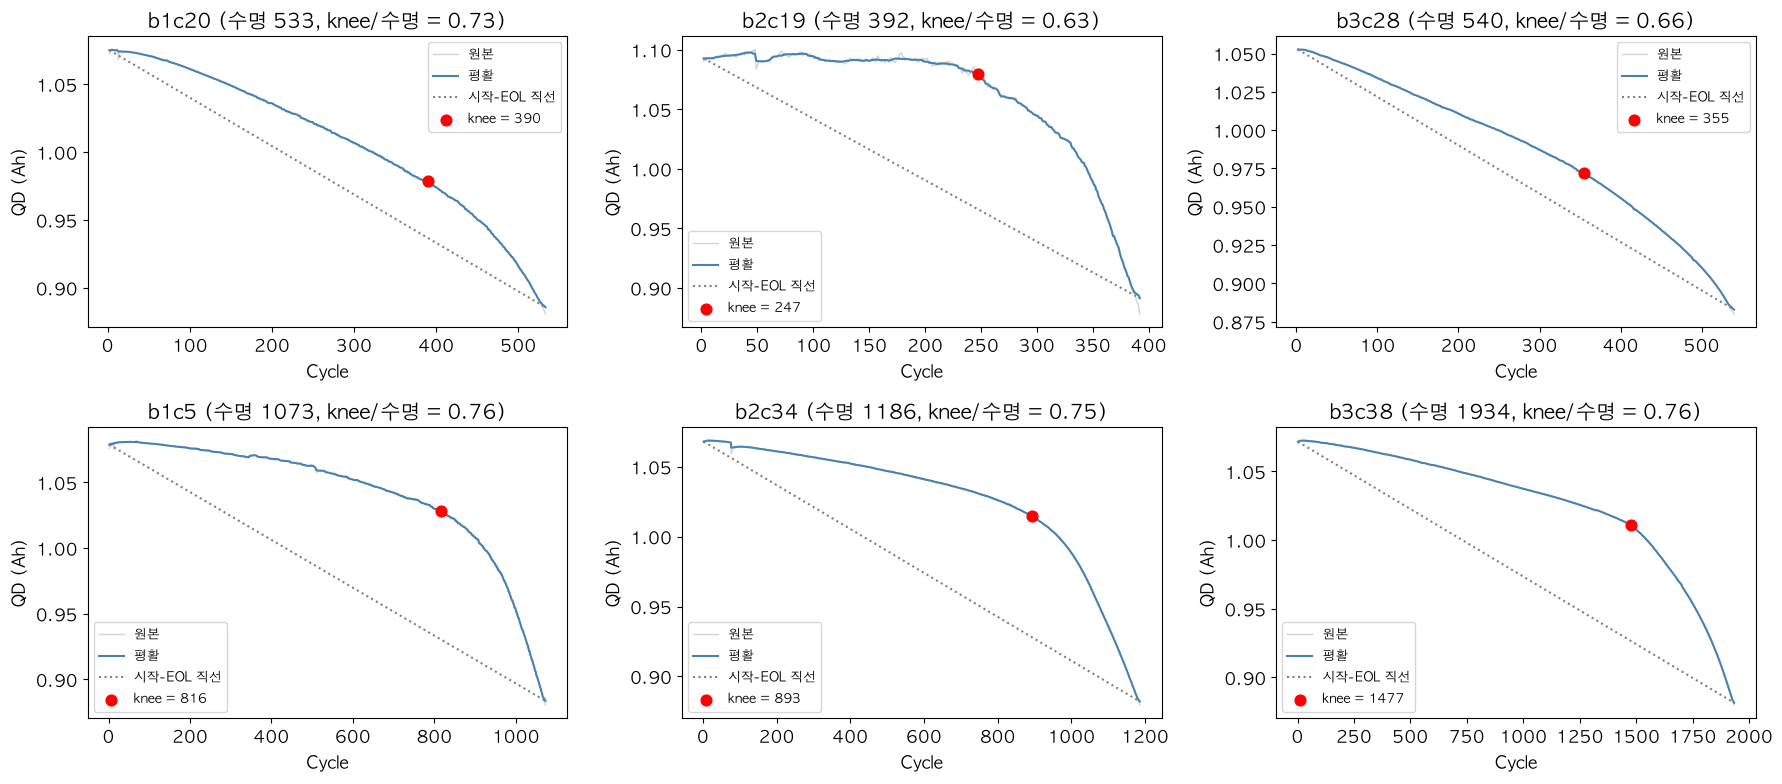

In [38]:
def find_knee(g):
    """한 셀의 (cycle, QD)에서 knee 위치를 찾는다. g는 cycle 순으로 정렬된 DataFrame."""
    k = g['cycle'].values
    q = g['QD'].rolling(15, center=True, min_periods=1).median().values
    x = (k - k[0]) / (k[-1] - k[0])
    y = (q - q[-1]) / (q[0] - q[-1])
    i = int(np.argmax(y - (1 - x)))      # 직선 y = 1 - x 위로 가장 멀리 떨어진 점
    return i, k, q


# EOL 도달 시점까지만 사용 (Batch 2는 0.88Ah 아래까지 기록이 이어지므로 잘라낸다)
dk = d_clean[(d_clean['cycle'] >= 2) & (d_clean['cycle'] <= d_clean['cycle_life'])]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for col, b in enumerate([1, 2, 3]):
    cb = cells2[(cells2['batch'] == b) & cells2['use']].sort_values('cycle_life')
    for row, cid in enumerate([cb['cell_id'].iloc[0], cb['cell_id'].iloc[-1]]):
        g = dk[dk['cell_id'] == cid]
        i, k, q = find_knee(g)
        ax = axes[row, col]
        ax.plot(g['cycle'], g['QD'], color='lightgray', linewidth=1, label='원본')
        ax.plot(k, q, color='steelblue', linewidth=1.5, label='평활')
        ax.plot([k[0], k[-1]], [q[0], q[-1]], color='gray', linestyle=':', label='시작-EOL 직선')
        ax.scatter(k[i], q[i], color='red', s=60, zorder=5, label=f'knee = {k[i]}')
        ax.set_title(f'{cid} (수명 {k[-1]}, knee/수명 = {k[i] / k[-1]:.2f})')
        ax.set_xlabel('Cycle')
        ax.set_ylabel('QD (Ah)')
        ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q2_knee_examples.png'), dpi=150)
plt.show()

**전체 셀의 knee 통계**

예시 그래프에서 확인한 방법을 분석 대상 119셀 전체에 적용한다. knee의 위치(수명 대비 비율), knee 전후의 열화 속도, 가속 배수를 배치별로 요약한다.

In [39]:
rows = []
for cid, g in dk.groupby('cell_id'):
    i, k, q = find_knee(g)
    rows.append({
        'cell_id': cid,
        'batch': g['batch'].iloc[0],
        'cycle_life': g['cycle_life'].iloc[0],
        'knee': k[i],
        'knee_ratio': k[i] / k[-1],
        'rate_before': (q[0] - q[i]) / (k[i] - k[0]) * 1000,     # mAh/cycle
        'rate_after': (q[i] - q[-1]) / (k[-1] - k[i]) * 1000,
    })
knee = pd.DataFrame(rows)
knee['accel'] = knee['rate_after'] / knee['rate_before']

print(knee.groupby('batch')[['knee_ratio', 'knee', 'rate_before', 'rate_after', 'accel']].median().round(3))
print()
print('knee_ratio 표준편차')
print(knee.groupby('batch')['knee_ratio'].std().round(3))
print()
print('가장 이른 knee (사이클)')
print(knee.groupby('batch')['knee'].min())
print()
print('knee가 100사이클 이내인 셀 수:', (knee['knee'] <= 100).sum())

       knee_ratio   knee  rate_before  rate_after   accel
batch                                                    
1           0.710  550.0        0.070       0.674   9.476
2           0.686  328.0        0.084       1.139  10.984
3           0.759  764.5        0.059       0.568   8.975

knee_ratio 표준편차
batch
1    0.027
2    0.056
3    0.035
Name: knee_ratio, dtype: float64

가장 이른 knee (사이클)
batch
1    390
2    243
3    355
Name: knee, dtype: int64

knee가 100사이클 이내인 셀 수: 0


**결과 해석 — Knee point**

- **knee는 수명의 약 70% 지점에서 나타난다.** `knee_ratio`의 중앙값이 Batch 1 0.71, Batch 2 0.69, Batch 3 0.76이고, 표준편차는 0.03~0.06으로 작다. 수명은 셀마다 크게 달라도 knee의 상대적 위치는 비슷하다.
- **knee 이후 열화 속도는 이전의 약 9~11배다.** 이전에는 사이클당 0.06~0.08mAh, 이후에는 0.57~1.14mAh씩 줄어든다.
- **모델이 볼 수 있는 구간에는 knee가 없다.** 가장 이른 knee가 243사이클이고, 100사이클 이내에 knee가 있는 셀은 0개다.
- Batch 2는 knee 이후 열화 속도(1.14mAh/사이클)가 다른 배치(0.57~0.67)보다 빠르다.
- 예시 그래프에서 수명이 긴 셀은 꺾임이 뚜렷하고, 수명이 짧은 셀(b1c20, b3c28)은 처음부터 꾸준히 감소해 꺾임이 완만하다. 다만 배치당 두 셀만 확인한 관찰이다.

**시사점**
- 수명을 결정하는 급격한 열화는 관측 구간(100사이클) 밖에서 시작된다. 초기 데이터로 수명을 예측한다는 것은, **아직 일어나지 않은 knee의 시점을 그 전의 신호로 맞히는 문제**다.
- 열화 곡선의 겉모습(용량 값)에는 그 신호가 드러나지 않으므로(Q2-6), 곡선 안쪽의 변화를 봐야 한다.

### Q2 결론

**확인한 사실**
1. 원본 데이터에 측정 오류가 있다. 절대 범위(0.8~1.15Ah)로 59행, 주변 값 비교로 11행을 제외했다. 후자 중 8행은 초기 100사이클 안에 있었다.
2. Batch 1의 첫 사이클은 46셀 모두 기록이 비어 있다. 배치 간 사이클 번호가 한 칸 어긋난다.
3. EOL에 도달하지 않은 셀이 있다. Batch 1의 10셀은 `cycle_life`가 수명이 아니라 시험 종료 시점이었다. 분석 대상은 Batch 1 36셀, Batch 2 39셀, Batch 3 44셀이다.
4. 열화는 일정하지 않다. knee는 수명의 약 70% 지점에 있고, 이후 열화가 약 9~11배 빨라진다.
5. 초기 100사이클 안에는 knee가 없고, 그 구간의 용량 변화는 중앙값 +0.001~+0.002Ah로 잡음 수준이다.
6. 초기 용량 변화와 수명의 상관은 Batch 1 +0.47, Batch 2 −0.20으로 방향이 다르다.

**모델 설계에 주는 시사점**
- **학습 데이터는 Batch 1의 36셀이다.** 표본이 작으므로 단순한 모델과 적은 수의 피처가 필요하다. (사실 3)
- **방전 용량의 크기나 변화량은 핵심 피처가 될 수 없다.** (사실 5, 6)
- **피처를 고를 때 Batch 1에서의 상관만 보면 안 된다.** 배치 간에 관계의 방향이 유지되는지 확인해야 한다. (사실 6)
- **피처 계산 전에 두 단계의 정제를 적용한다.** (사실 1)
- 초기 사이클을 기준으로 피처를 만들 때 배치 간 사이클 번호를 맞춘다. (사실 2)

**남은 질문**
- 용량 값에 신호가 없다면, 초기 100사이클의 어떤 신호가 수명을 구분하는가 → Q3

> **정정 (Q5-2 이후)**: 사실 6은 Batch 2의 두 집단을 합쳐 계산한 결과다. 집단을 나누면 방향이 같다. "Batch 1의 상관만으로 피처를 고르면 안 된다"는 원칙의 근거는 Q4의 `C_avg`와 `chargetime`이다.

## Q3. ΔQ(V) 곡선: 초기 사이클에서 차이가 보이는가?

**목적**: Q2에서 초기 100사이클의 방전 용량 값은 수명을 구분하지 못했다. 같은 구간에서 방전 곡선의 모양 변화는 수명을 구분하는지 확인한다.
- 100번째와 10번째 사이클의 Q(V) 차이인 ΔQ(V)를 계산한다
- 장수명 셀과 단수명 셀의 ΔQ(V) 형태를 비교한다
- 둘을 구분할 수 있는 통계값을 피처로 뽑는다

### Q3-1. Qdlin 곡선 추출

**목적**: ΔQ(V) 계산에 필요한 `Qdlin`(전압 축으로 보간된 방전 용량, 1,000포인트)을 원본 파일에서 추출해 저장한다.
`summary`에는 없는 사이클 내부 데이터이므로 원본을 다시 읽어야 한다. 셀마다 처음 101개 사이클을 저장한다.

In [40]:
# 최초 1회만 실행. 이후에는 아래 np.load 셀부터 실행한다.
FILES = {
    1: '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    2: '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    3: '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}
N_KEEP = 101      # 셀마다 저장할 사이클 수
N_POINTS = 1000   # Qdlin 한 곡선의 포인트 수

qdlin = {}
for b, fname in FILES.items():
    print(f'Batch {b} 로딩 중...')
    mat = load_mat(os.path.join(DATA_DIR, fname))
    batch = mat['batch']
    if b == 1:
        vdlin = np.array(batch['Vdlin'][0])
    for i in range(len(batch['cycles'])):
        q = batch['cycles'][i]['Qdlin']
        arr = np.full((N_KEEP, N_POINTS), np.nan, dtype=np.float32)
        for j in range(min(N_KEEP, len(q))):
            if q[j] is not None and np.size(q[j]) == N_POINTS:
                arr[j] = q[j]
        qdlin[f'b{b}c{i}'] = arr
    del mat, batch

np.savez_compressed(os.path.join(PROC_DIR, 'qdlin.npz'), Vdlin=vdlin, **qdlin)
print('저장한 셀 수:', len(qdlin))

Batch 1 로딩 중...
Batch 2 로딩 중...
Batch 3 로딩 중...
저장한 셀 수: 139


**저장된 곡선 불러오기**

위 추출 셀은 원본 파일 3개를 읽느라 약 5분이 걸리므로 최초 1회만 실행한다.
노트북을 다시 열었을 때는 추출 셀을 건너뛰고 이 셀부터 실행한다.

- `vdlin`: 전압 축. 3.5V → 2.0V, 1,000포인트
- `qdlin`: 셀 ID를 키로 하는 dict. 값은 (101, 1000) 배열로, 행이 사이클이고 열이 전압 포인트다

In [41]:
z = np.load(os.path.join(PROC_DIR, 'qdlin.npz'))
vdlin = z['Vdlin']
qdlin = {k: z[k] for k in z.files if k != 'Vdlin'}
print(len(qdlin), qdlin['b1c0'].shape, vdlin[:3], vdlin[-3:])

139 (101, 1000) [3.5       3.4984985 3.496997 ] [2.003003  2.0015015 2.       ]


**사이클 위치 확인**

Q2에서 Batch 1은 첫 사이클의 summary 기록이 비어 있었다. `Qdlin`에서도 같은지 확인한다.
ΔQ(V)는 "10번째 사이클"과 "100번째 사이클"의 차이인데, 배치마다 비어 있는 위치가 다르면 배열의 같은 위치가 서로 다른 사이클을 가리키게 된다.

In [42]:
for cid in ['b1c0', 'b2c0', 'b3c0']:
    empty = np.isnan(qdlin[cid]).all(axis=1)
    print(cid, '비어 있는 위치:', np.where(empty)[0])

b1c0 비어 있는 위치: [0]
b2c0 비어 있는 위치: []
b3c0 비어 있는 위치: []


**결과 해석 — 추출 결과와 사이클 위치**

- 139셀의 `Qdlin`을 추출했다. 셀마다 (101, 1000) 배열이고, 전압 축은 3.5V → 2.0V다.
- **Batch 1의 대표 셀(b1c0)은 배열의 첫 위치가 비어 있고**, Batch 2와 Batch 3의 대표 셀은 비어 있는 위치가 없다. Q2에서 확인한 "Batch 1은 첫 사이클의 summary가 비어 있다"와 같은 현상이다.
- 따라서 배열의 같은 위치가 배치마다 다른 사이클을 가리킨다. Batch 1에서 위치 9는 9번째 측정이고, Batch 2·3에서는 10번째 측정이다.

### Q3-2. 사이클 기준 맞추기

**목적**: 대표 셀에서 본 "Batch 1은 첫 위치가 비어 있다"가 전체 셀에서도 성립하는지 확인하고, 세 배치에 같은 기준으로 10번째·100번째 사이클을 꺼낼 방법을 정한다.

In [43]:
rows = []
for cid, arr in qdlin.items():
    empty = np.isnan(arr).all(axis=1)
    rows.append({
        'cell_id': cid,
        'batch': int(cid[1]),
        'n_empty': int(empty.sum()),
        'first_valid': int(np.argmax(~empty)),
    })
pos = pd.DataFrame(rows)
print(pos.groupby('batch')[['n_empty', 'first_valid']].agg(['min', 'max']))

      n_empty     first_valid    
          min max         min max
batch                            
1           1   1           1   1
2           0   0           0   0
3           0   0           0   0


**결과 해석 — 전체 셀의 사이클 위치**

- **Batch 1은 46셀 모두 배열의 첫 위치(0)만 비어 있고**, 위치 1부터 값이 있다.
- **Batch 2와 Batch 3은 전 셀이 위치 0부터 값이 있다.** 비어 있는 위치가 없다.
- 배치 안에서 예외가 없으므로, 배치 단위로 한 칸의 차이만 보정하면 된다.
- 처음 101개 위치 안에서 중간에 비어 있는 사이클은 없다. 10번째와 100번째 사이클을 모든 셀에서 꺼낼 수 있다.

**결정: 측정 순서 기준으로 사이클을 센다**

각 셀에서 처음 값이 있는 위치부터 세어 10번째와 100번째 측정을 사용한다.
- Batch 1: 배열 위치 10과 100
- Batch 2, 3: 배열 위치 9와 99

**이유**: ΔQ(V)는 셀이 충방전을 반복하는 동안 방전 곡선이 얼마나 변했는지를 재는 값이다. 배치 간에 비교하려면 각 셀이 실제로 겪은 충방전 횟수가 같은 시점끼리 비교해야 한다. 배열 위치를 그대로 쓰면 Batch 1만 한 사이클 앞선 측정을 쓰게 된다.

**ΔQ(V) 계산**: `ΔQ(V) = Q₁₀₀(V) − Q₁₀(V)`. 분석 대상 119셀에 대해 계산한다.

In [44]:
K_EARLY, K_LATE = 10, 100
first_valid = pos.set_index('cell_id')['first_valid']

dq = {}
for cid in cells2.loc[cells2['use'], 'cell_id']:
    arr = qdlin[cid]
    off = first_valid[cid]
    dq[cid] = arr[off + K_LATE - 1] - arr[off + K_EARLY - 1]

print(len(dq), dq['b1c5'].shape)

119 (1000,)


**결과 확인**: 분석 대상 119셀 모두 ΔQ(V)가 계산됐다. 셀마다 길이 1,000의 곡선이고, 각 값은 전압 축 `vdlin`의 한 포인트에 대응한다.

### Q3-3. ΔQ(V) 곡선 비교

**목적**: ΔQ(V) 곡선의 형태가 수명에 따라 다른지 배치별로 확인한다.
Q2-4에서 방전 용량 곡선은 초기 100사이클에서 수명별로 구분되지 않았다. 같은 구간의 정보로 만든 ΔQ(V)는 구분되는지 본다.


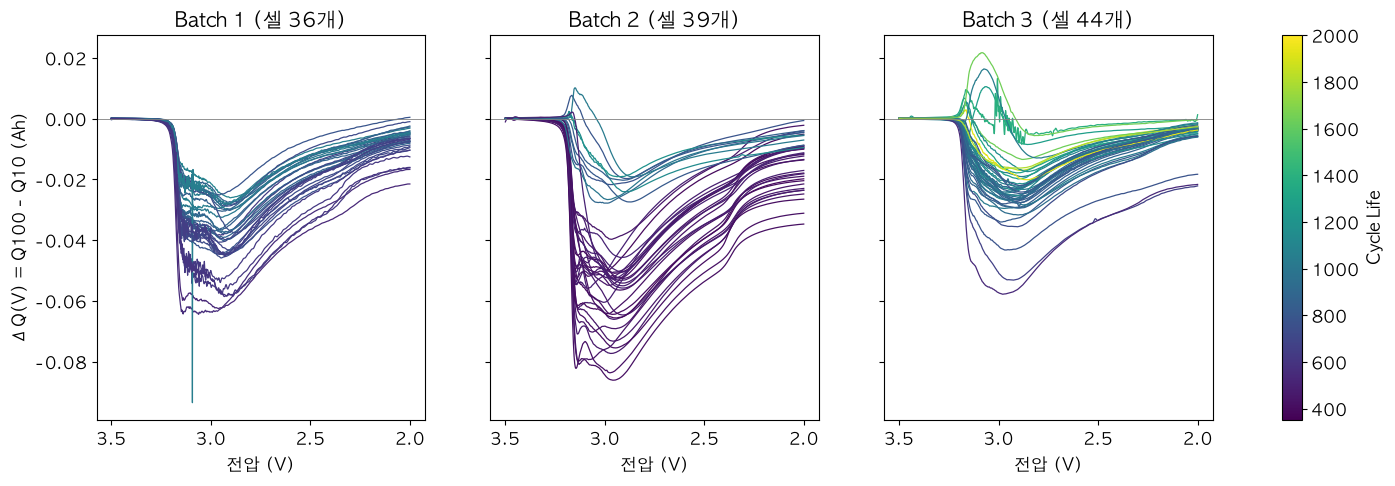

In [45]:
life = cells2.set_index('cell_id')['cycle_life']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, b in zip(axes, [1, 2, 3]):
    ids = [cid for cid in dq if cid.startswith(f'b{b}c')]
    for cid in ids:
        ax.plot(vdlin, dq[cid], color=cmap(norm(life[cid])), linewidth=0.9)
    ax.axhline(0, color='gray', linewidth=0.6)
    ax.invert_xaxis()
    ax.set_title(f'Batch {b} (셀 {len(ids)}개)')
    ax.set_xlabel('전압 (V)')
axes[0].set_ylabel('ΔQ(V) = Q100 - Q10 (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label='Cycle Life')
plt.savefig(os.path.join(FIG_DIR, 'q3_deltaQ_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — ΔQ(V) 곡선**

**곡선의 공통된 형태**
- 세 배치 모두 3.5V~3.2V 구간에서는 ΔQ가 0에 붙어 있다. 방전 초반에는 10번째와 100번째 사이클의 차이가 없다.
- 약 3.2V에서 급격히 아래로 떨어져 3.0V 부근에서 가장 깊어지고, 2.0V로 갈수록 다시 0에 가까워진다.
- 2.0V에서의 값(총 방전 용량의 차이)은 대부분 0~−0.02Ah에 모여 있다. 반면 3.0V 부근에서는 −0.02~−0.085Ah까지 넓게 퍼진다. **총 용량은 비슷해도 방전 경로는 셀마다 다르게 변했다.**

**수명에 따른 차이**
- **수명이 짧은 셀일수록 곡선이 깊게 파인다.** 세 배치 모두 보라색(단수명) 곡선이 아래쪽에, 청록·노란색(장수명) 곡선이 위쪽에 있다.
- Batch 2에서 이 차이가 가장 뚜렷하다. 보라색 곡선들은 −0.03~−0.085Ah까지 내려가고, 청록색 곡선들은 −0.02Ah 부근에 따로 모여 있다. Q1에서 확인한 두 집단이 ΔQ(V)에서도 갈라진다.
- Q2-4에서 방전 용량 곡선은 초기 100사이클 구간에서 색이 구분되지 않았다. 같은 구간의 정보로 만든 ΔQ(V)에서는 색이 구분된다.

**배치 간 차이**
- 곡선의 깊이가 배치마다 다르다. Batch 2가 가장 깊고(최대 약 −0.085Ah), Batch 3이 가장 얕다(대부분 −0.01~−0.03Ah). 수명 중앙값의 순서(Batch 2 < Batch 1 < Batch 3)와 같은 방향이다.
- Batch 3과 Batch 2의 일부 장수명 셀은 3.1V 부근에서 ΔQ가 0보다 커진다(최대 약 +0.02Ah). Batch 1에는 이런 곡선이 없다.

**데이터 품질**
- Batch 1에 한 점만 −0.093Ah까지 떨어지는 곡선이 하나 있다(약 3.1V). 앞뒤 값과 이어지지 않는 측정 스파이크로 보인다.
- Batch 3에 3.0V 부근에서 톱니처럼 흔들리는 곡선이 하나 있다.

**시사점**
- ΔQ(V) 곡선의 깊이나 퍼진 정도를 숫자로 요약하면 수명을 구분하는 피처가 될 수 있다.
- 다만 곡선의 최솟값 같은 통계는 스파이크 한 점에 좌우될 수 있으므로, 통계를 계산하기 전에 스파이크를 처리해야 한다.

### Q3-4. ΔQ(V) 곡선의 측정 오류 확인

**목적**: Q3-3 그래프에서 다른 곡선과 어긋나는 값이 두 군데 보였다. 어느 셀에서 온 값인지 확인하고, 통계값을 계산하기 전에 처리 방법을 정한다.
- **Batch 1의 스파이크**: 한 곡선이 약 3.1V에서 한 점만 −0.093Ah까지 떨어진다.
- **Batch 3의 톱니**: 한 곡선이 3.0V 부근에서 여러 점에 걸쳐 위아래로 흔들린다.
- 그래프에서 눈에 띄지 않은 다른 셀에도 같은 문제가 있는지 함께 점검한다.

**방법**: 각 곡선에서 전압 축 방향으로 주변 9포인트의 중앙값을 구하고, 실제 값과의 차이가 가장 큰 지점을 찾는다. Q2-5에서 사이클 방향으로 적용한 방법과 같은 원리다.
- 한 점만 튀는 스파이크는 중앙값에 영향을 주지 못하므로 제거된다.
- 여러 점에 걸친 톱니는 완전히 제거되지 않을 수 있으므로, 필터 전후의 값을 비교해 영향을 확인한다.

In [46]:
from scipy.signal import medfilt

rows = []
for cid, curve in dq.items():
    smooth = medfilt(curve.astype(float), 9)
    dev = np.abs(curve - smooth)
    i = int(np.argmax(dev))
    rows.append({
        'cell_id': cid,
        'max_dev': dev[i],
        'at_voltage': vdlin[i],
        'dq_min_raw': curve.min(),
        'dq_min_smooth': smooth.min(),
    })
spk = pd.DataFrame(rows).sort_values('max_dev', ascending=False)
print(spk.head(10).round(4))

    cell_id  max_dev  at_voltage  dq_min_raw  dq_min_smooth
31    b1c41   0.0717      3.0931     -0.0936        -0.0279
110   b3c37   0.0079      3.0060     -0.0084        -0.0074
34    b1c44   0.0051      3.1306     -0.0584        -0.0583
33    b1c43   0.0044      3.1291     -0.0455        -0.0451
32    b1c42   0.0031      3.1441     -0.0448        -0.0447
29    b1c39   0.0030      3.1366     -0.0540        -0.0533
28    b1c38   0.0028      3.0946     -0.0577        -0.0573
35    b1c45   0.0027      3.1456     -0.0586        -0.0585
30    b1c40   0.0017      3.1096     -0.0284        -0.0284
18    b1c28   0.0011      3.1351     -0.0379        -0.0378


**결과 해석 — ΔQ(V) 곡선의 측정 오류**

- **b1c41: 한 점짜리 스파이크.** 주변 값과의 차이가 0.0717Ah로, 그다음 셀(0.0079Ah)의 9배다. 위치는 3.09V다. 이 한 점 때문에 곡선의 최솟값이 −0.0936Ah로 계산되는데, 필터 후에는 −0.0279Ah다. 스파이크가 최솟값을 3배 이상 과장하고 있었다.
- **b3c37: 톱니 형태의 잡음.** 차이는 0.0079Ah이고 위치는 3.01V다. 필터 전후 최솟값의 차이는 작다(−0.0084 → −0.0074Ah). 이 셀은 Q2-5에서도 방전 용량 스파이크(사이클 597~598)가 확인된 셀이다.
- **그 외 셀은 측정 오류가 아니다.** 차이가 0.005Ah 이하이고 필터 전후 최솟값이 거의 같다. 위치가 모두 3.09~3.15V로, 곡선이 0에서 급격히 떨어지는 구간이어서 차이가 난 것이다.

**결정**: ΔQ(V) 곡선에 전압 축 방향 9포인트 중앙값 필터를 적용한 뒤 통계값을 계산한다.
- b1c41의 스파이크는 필터로 제거된다.
- 정상 곡선은 필터 전후 차이가 0.005Ah 이하이므로, 필터가 정상 데이터를 왜곡하지 않는다.
- b3c37은 필터로 톱니가 완화되지만, 두 종류의 측정 이상이 확인된 셀이므로 이후 분석에서 따로 지켜본다.

In [47]:
dq_s = {cid: medfilt(curve.astype(float), 9) for cid, curve in dq.items()}

### Q3-5. ΔQ(V) 통계값과 수명의 관계

**목적**: Q3-3에서 눈으로 본 "수명이 짧은 셀일수록 ΔQ(V) 곡선이 깊다"를 숫자로 확인한다.
- 곡선을 통계값(분산, 최솟값, 평균, 왜도, 첨도)으로 요약한다
- 각 통계값과 수명의 상관을 배치별로 계산한다
- 상관의 크기와 방향이 세 배치에서 일관되는지 확인한다 (Q2-6에서 용량 변화량은 배치마다 방향이 달랐다)

필터를 적용한 곡선(`dq_s`)을 사용한다.

In [48]:
from scipy.stats import skew, kurtosis

rows = []
for cid, c in dq_s.items():
    rows.append({
        'cell_id': cid,
        'dq_var': np.var(c),
        'dq_min': np.min(c),
        'dq_mean': np.mean(c),
        'dq_skew': skew(c),
        'dq_kurt': kurtosis(c),
    })
feat = pd.DataFrame(rows).merge(
    cells2[['cell_id', 'batch', 'newstructure', 'cycle_life']], on='cell_id')

# 로그 변환
feat['log_life'] = np.log10(feat['cycle_life'])
feat['log_var'] = np.log10(feat['dq_var'])
feat['log_min'] = np.log10(feat['dq_min'].abs())
feat['log_mean'] = np.log10(feat['dq_mean'].abs())

print(feat.groupby('batch')[['dq_var', 'dq_min', 'dq_mean']].agg(['min', 'median', 'max']).T)

batch                  1         2         3
dq_var  min     0.000070  0.000036  0.000007
        median  0.000168  0.000326  0.000067
        max     0.000455  0.000821  0.000353
dq_min  min    -0.064026 -0.086140 -0.057788
        median -0.038737 -0.054162 -0.024778
        max    -0.025089 -0.019112 -0.005589
dq_mean min    -0.033066 -0.046485 -0.030256
        median -0.017491 -0.024683 -0.010344
        max    -0.009003 -0.007448  0.000784


**결과 해석 — 통계값의 범위**

- **분산의 범위가 매우 넓다.** 전체 최소(0.000007)와 최대(0.000821)가 100배 넘게 차이 난다. 배치 안에서도 Batch 1은 약 6.5배, Batch 3은 약 50배다. 원본 값으로는 큰 값 몇 개가 관계를 좌우하므로 로그 변환이 타당하다.
- **수명이 짧은 배치일수록 곡선이 깊고 분산이 크다.** 분산의 중앙값은 Batch 2 > Batch 1 > Batch 3 순이고, 수명 중앙값은 그 반대 순서다.
- **Batch 2의 일부 셀은 피처 값이 Batch 1의 범위를 벗어난다.** 분산의 최대가 Batch 1은 0.000455, Batch 2는 0.000821이다. 타깃(수명)뿐 아니라 피처도 학습 범위 밖에 있다.
- **Batch 3에 평균이 양수인 셀이 있다**(최대 +0.000784). 평균이 0에 가까운 셀은 로그를 취하면 값이 불안정해지므로, `log_mean`은 피처로 쓰기 전에 주의가 필요하다.

**시사점**: 모델은 타깃과 피처 양쪽에서 학습 범위 밖을 예측해야 한다. 학습 범위 밖에서도 관계가 유지되는 형태(예: 직선 관계)여야 예측이 가능하다.

**수명과의 상관계수**

로그 변환 전후를 나란히 계산해, 변환이 관계를 더 잘 드러내는지 확인한다.

In [50]:
def corr_by_batch(x, y):
    return feat.groupby('batch').apply(lambda g: g[x].corr(g[y])).round(2)

corr = pd.DataFrame({
    'var vs life (원본)': corr_by_batch('dq_var', 'cycle_life'),
    'log_var vs log_life': corr_by_batch('log_var', 'log_life'),
    'log_min vs log_life': corr_by_batch('log_min', 'log_life'),
    'log_mean vs log_life': corr_by_batch('log_mean', 'log_life'),
    'skew vs log_life': corr_by_batch('dq_skew', 'log_life'),
    'kurt vs log_life': corr_by_batch('dq_kurt', 'log_life'),
}).T
corr.columns = ['Batch 1', 'Batch 2', 'Batch 3']
corr

,Batch 1,Batch 2,Batch 3
var vs life (원본),-0.80,-0.73,-0.59
log_var vs log_life,-0.84,-0.92,-0.76
log_min vs log_life,-0.83,-0.90,-0.74
log_mean vs log_life,-0.77,-0.87,-0.65
skew vs log_life,-0.43,-0.13,0.18
kurt vs log_life,0.05,0.65,0.34


**결과 해석 — ΔQ(V) 통계값과 수명의 상관**

- **`log_var`가 수명과 가장 강하게 연관된다.** `log_life`와의 상관계수가 Batch 1 −0.84, Batch 2 −0.92, Batch 3 −0.76이다. ΔQ(V)의 분산이 클수록 수명이 짧다.
- **관계의 방향이 세 배치에서 같다.** Q2-6의 용량 변화량은 +0.47, −0.20, +0.28로 배치마다 방향이 달랐다. 같은 초기 100사이클의 정보지만, 방전 곡선의 모양 변화(ΔQ)는 배치를 넘어 일관된 신호를 준다.
- **로그 변환이 관계를 더 잘 드러낸다.** 원본 값의 상관(−0.80, −0.73, −0.59)보다 로그 변환 후(−0.84, −0.92, −0.76)가 세 배치 모두에서 강하다.
- `log_min`(−0.83, −0.90, −0.74)과 `log_mean`(−0.77, −0.87, −0.65)도 비슷한 수준이다. 세 통계가 같은 정보를 담고 있을 가능성이 있다.
- **왜도와 첨도는 피처로 쓰기 어렵다.** 왜도는 Batch 3에서 부호가 바뀌고(−0.43, −0.13, +0.18), 첨도는 Batch 1에서 상관이 없다(0.05).

**시사점**
- **`log_var`를 핵심 피처로 삼는다.** 상관이 가장 강하고, 학습에 쓰지 않는 Batch 2·3에서도 같은 방향으로 유지된다.
- 타깃도 로그 변환한 `log_life`를 쓴다. 로그-로그 공간에서 관계가 더 뚜렷하다.

**로그 변환을 쓰는 이유**

- ΔQ(V)의 분산은 셀마다 100배 넘게 차이 난다. 원본 값으로는 대부분의 셀이 한쪽에 몰리고 큰 값 몇 개가 관계를 좌우한다. log10을 취하면 "10배 차이"가 "1 차이"가 되어 셀들이 고르게 퍼진다.
- 로그는 크기 순서를 바꾸지 않는다. "분산이 클수록 수명이 짧다"는 해석은 로그 전후가 같다.
- 로그-로그 공간에서의 직선 관계는 원본에서 비율 관계를 뜻한다. "분산이 몇 배가 되면 수명이 몇 % 줄어든다"는 형태다.
- 수명에도 로그를 취한다. 꼬리가 긴 분포를 완화하고, 평가 지표인 MAPE(비율 오차)와 오차의 성격을 맞추기 위해서다.

**산점도로 확인**

상관계수만으로는 관계의 형태를 알 수 없다. 세 배치를 한 그래프에 그려 다음을 확인한다.
- 관계가 직선에 가까운가
- 세 배치가 같은 선 위에 놓이는가, 배치마다 어긋나는가
- Batch 2의 높은 상관(−0.92)이 두 집단의 분리 때문인가

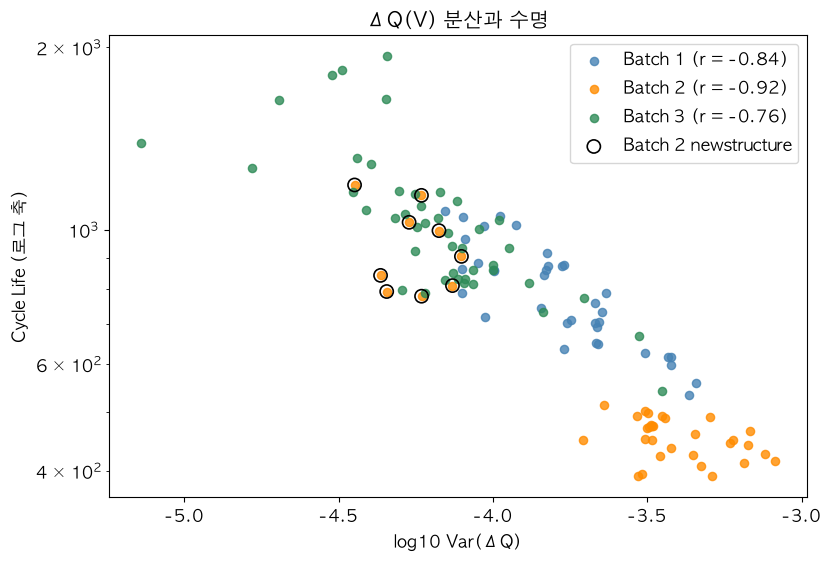

In [51]:
fig, ax = plt.subplots(figsize=(9, 6))
for b in [1, 2, 3]:
    g = feat[feat['batch'] == b]
    r = g['log_var'].corr(g['log_life'])
    ax.scatter(g['log_var'], g['cycle_life'], color=colors[b], s=35, alpha=0.8,
               label=f'Batch {b} (r = {r:.2f})')

# Batch 2의 newstructure 셀을 검은 테두리로 표시
ns = feat[(feat['batch'] == 2) & feat['newstructure']]
ax.scatter(ns['log_var'], ns['cycle_life'], facecolors='none', edgecolors='black', s=90,
           linewidths=1.2, label='Batch 2 newstructure')

ax.set_yscale('log')
ax.set_xlabel('log10 Var(ΔQ)')
ax.set_ylabel('Cycle Life (로그 축)')
ax.set_title('ΔQ(V) 분산과 수명')
ax.legend()
plt.savefig(os.path.join(FIG_DIR, 'q3_var_vs_life.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — ΔQ(V) 분산과 수명의 산점도**

- **관계는 직선에 가깝다.** 분산이 작고 수명이 긴 쪽에서 분산이 크고 수명이 짧은 쪽으로 점들이 띠 모양으로 이어진다.
- **Batch 1과 Batch 3은 같은 띠 위에 있다.** 두 배치의 점이 서로 섞여 있다. Batch 2의 `newstructure` 9셀도 이 띠 위에서 Batch 3과 섞여 있다.
- **Batch 2의 일반 30셀은 그 띠보다 아래에 있다.** `log_var`가 약 −3.5일 때 Batch 1 셀의 수명은 약 600~650인데, Batch 2 일반 셀은 약 450~500이다. 같은 ΔQ 분산에서 수명이 더 짧다.
- **Batch 2의 상관계수 −0.92는 두 집단의 분리에서 나온 값이다.** `newstructure` 9셀은 왼쪽 위에, 일반 30셀은 오른쪽 아래에 떨어져 있다. 일반 30셀 안에서는 수명 범위가 좁아(392~514) 기울기가 뚜렷하지 않다.
- Batch 2 일반 셀의 일부는 `log_var`가 Batch 1의 최댓값보다 크다. 피처가 학습 범위를 벗어난다.

**시사점**
- `log_var`와 `log_life`의 관계는 직선이므로 선형 모델로 표현할 수 있고, 학습 범위 밖으로 연장할 수 있다.
- 그러나 **Batch 1로 학습한 직선을 Batch 2 일반 셀에 적용하면 수명을 실제보다 길게 예측하게 된다.** 관계의 기울기는 비슷해 보여도 위치(절편)가 다르다.
- 상관계수가 높다는 것만으로 "잘 예측될 것"이라고 결론 내릴 수 없다. 상관은 배치 안의 관계이고, 예측 오차는 배치 간 위치 차이에 좌우된다.

### Q3-6. 배치 간 어긋남의 크기

**목적**: 산점도에서 Batch 2 일반 셀이 Batch 1·3의 띠보다 아래에 있었다. 그 차이를 숫자로 잰다.
- Batch 1의 점들로 `log_life`와 `log_var`의 직선을 구한다
- 각 셀이 그 직선에서 얼마나 떨어져 있는지(잔차)를 집단별로 비교한다
- 잔차의 평균은 "집단 전체가 얼마나 위아래로 치우쳤는가", 표준편차는 "집단 안에서 얼마나 흩어졌는가"를 나타낸다

**주의**: 이 단계는 배치 간 차이를 파악하기 위한 EDA다. Batch 2·3의 결과를 보고 모델이나 피처를 조정하지 않는다.

In [52]:
# Batch 1로만 직선 구하기
b1 = feat[feat['batch'] == 1]
slope, intercept = np.polyfit(b1['log_var'], b1['log_life'], 1)
print(f'Batch 1 직선: log_life = {slope:.3f} * log_var + {intercept:.3f}')

# 모든 셀의 잔차 (실제 - 직선 예측)
feat['pred_log'] = slope * feat['log_var'] + intercept
feat['resid'] = feat['log_life'] - feat['pred_log']

# 집단 구분: Batch 2는 둘로 나눔
feat['group'] = 'Batch ' + feat['batch'].astype(str)
feat.loc[(feat['batch'] == 2) & feat['newstructure'], 'group'] = 'Batch 2 newstructure'
feat.loc[(feat['batch'] == 2) & ~feat['newstructure'], 'group'] = 'Batch 2 일반'

res = feat.groupby('group')['resid'].agg(셀수='size', 잔차_평균='mean', 잔차_표준편차='std')
res['실제/예측 비율'] = 10 ** res['잔차_평균']
print(res.round(3))

# 배치별로 직선을 따로 구했을 때의 기울기
print()
for b in [1, 2, 3]:
    g = feat[feat['batch'] == b]
    print(f'Batch {b} 자체 기울기: {np.polyfit(g["log_var"], g["log_life"], 1)[0]:.3f}')

Batch 1 직선: log_life = -0.300 * log_var + 1.752
                      셀수  잔차_평균  잔차_표준편차  실제/예측 비율
group                                             
Batch 1               36 -0.000    0.045     1.000
Batch 2 newstructure   9 -0.062    0.069     0.868
Batch 2 일반            30 -0.118    0.046     0.762
Batch 3               44 -0.004    0.077     0.992

Batch 1 자체 기울기: -0.300
Batch 2 자체 기울기: -0.328
Batch 3 자체 기울기: -0.304


**결과 해석 — 배치 간 어긋남의 크기**

- **Batch 1의 직선**: `log_life = −0.300 × log_var + 1.752`. ΔQ 분산이 10배가 되면 수명이 약 절반(10^−0.3 ≈ 0.50)이 되는 관계다.
- **Batch 2 일반 30셀은 직선보다 아래에 있다.** 잔차 평균이 −0.118이고, 실제 수명은 직선 예측의 약 76%다. Batch 1 직선으로 예측하면 약 31% 과대예측한다.
- **이 어긋남은 흩어짐이 아니라 평행 이동이다.** Batch 2 일반 셀의 잔차 표준편차(0.046)가 Batch 1(0.045)과 거의 같다.
- **Batch 3은 어긋남이 없다.** 잔차 평균 −0.004, 실제/예측 비율 0.99다. 다만 표준편차가 0.077로 Batch 1보다 커서 개별 셀의 오차는 더 크다.
- Batch 2 `newstructure` 9셀은 비율 0.87이지만, 표본이 작고 표준편차(0.069)가 커서 치우침이 있다고 단정하기 어렵다.
- **기울기는 세 배치가 거의 같다**(−0.300, −0.328, −0.304). 관계의 형태는 유지되고, 달라진 것은 직선의 위치다.

**시사점**
- `log_var`와 수명의 관계는 배치를 넘어 같은 형태로 유지된다. 선형 모델과 이 피처의 조합이 타당하다.
- 그러나 **Batch 2 일반 셀에서는 약 31%의 과대예측이 예상된다.** Batch 1 안에는 이 차이를 설명할 정보가 없으므로, 모델을 바꿔도 이 편향은 줄이기 어렵다.
- 테스트 성능을 보고할 때 오차를 두 부분으로 나눠 본다: **편향**(집단 전체가 치우친 정도)과 **분산**(치우침을 빼고 남는 오차). 이 표의 잔차 평균과 표준편차가 각각에 해당한다.
- 원 논문의 성능(MAPE 9.1%)과 차이가 난다면, 그 원인의 상당 부분은 이 배치 간 위치 차이에서 올 것으로 예상한다.

### Q3-7. 배치 간 시험 조건 확인

**목적**: Batch 2 일반 셀은 같은 ΔQ 분산에서 수명이 약 24% 짧다(Q3-6). Q1에서 남긴 질문("Batch 2의 두 집단은 왜 수명이 다른가")에 답하기 위해, 시험 조건이 실제로 같았는지 사이클 내부의 전류 시계열에서 확인한다.
- 사이클 한 번의 길이
- 충전 후, 방전 후 휴지 시간 (전류가 0에 가까운 구간의 길이)
- 방전 전류의 크기

각 셀의 50번째 측정 사이클을 사용한다.

In [53]:
# 최초 1회만 실행. 약 5분 소요.
K_PROBE = 50       # 확인할 사이클 (측정 순서 기준)
REST_I = 0.02      # |I| < 0.02A 이면 휴지로 본다


def longest_rest(t, rest):
    """rest가 True인 연속 구간 중 가장 긴 것의 길이(분)."""
    best, start = 0.0, None
    for n, r in enumerate(rest):
        if r and start is None:
            start = n
        if not r and start is not None:
            best, start = max(best, t[n] - t[start]), None
    if start is not None:
        best = max(best, t[-1] - t[start])
    return best


rows = []
for b, fname in FILES.items():
    print(f'Batch {b} 로딩 중...')
    mat = load_mat(os.path.join(DATA_DIR, fname))
    batch = mat['batch']
    for i in range(len(batch['cycles'])):
        cid = f'b{b}c{i}'
        j = first_valid[cid] + K_PROBE - 1
        t = np.ravel(batch['cycles'][i]['t'][j])
        cur = np.ravel(batch['cycles'][i]['I'][j])
        dis = np.where(cur < -0.5)[0]            # 방전 구간
        rest = np.abs(cur) < REST_I
        rows.append({
            'cell_id': cid,
            'cycle_min': t[-1],
            'rest_after_charge': longest_rest(t[:dis[0]], rest[:dis[0]]),
            'rest_after_discharge': longest_rest(t[dis[-1]:], rest[dis[-1]:]),
            'discharge_C': -np.median(cur[dis]) / 1.1,
        })
    del mat, batch

proto = pd.DataFrame(rows)
proto.to_parquet(os.path.join(PROC_DIR, 'protocol.parquet'))

Batch 1 로딩 중...
Batch 2 로딩 중...
Batch 3 로딩 중...


**집단별 시험 조건 비교**

분석 대상 119셀을 Q3-6과 같은 네 집단으로 나눠 중앙값을 비교한다.

In [54]:
proto = pd.read_parquet(os.path.join(PROC_DIR, 'protocol.parquet'))
p = proto.merge(feat[['cell_id', 'group', 'cycle_life']], on='cell_id')
print(p.groupby('group')[['cycle_min', 'rest_after_charge', 'rest_after_discharge', 'discharge_C']]
      .median().round(2))
print()
print('집단 안에서의 범위 (충전 후 휴지)')
print(p.groupby('group')['rest_after_charge'].agg(['min', 'max']).round(2))

                      cycle_min  rest_after_charge  rest_after_discharge  discharge_C
group                                                                                
Batch 1                   51.71               1.01                  0.00         3.64
Batch 2 newstructure      47.67               0.17                  0.15         3.64
Batch 2 일반                71.85               4.94                  5.00         3.64
Batch 3                   46.18               0.18                  0.07         3.64

집단 안에서의 범위 (충전 후 휴지)
                       min   max
group                           
Batch 1               1.01  1.10
Batch 2 newstructure  0.17  0.25
Batch 2 일반            4.94  5.02
Batch 3               0.17  0.18


**결과 해석 — 배치 간 시험 조건**

- **방전 조건은 모든 집단이 같다.** 방전 C-rate가 3.64(4A ÷ 1.1Ah)로 동일하다.
- **휴지 시간이 집단마다 다르다.** Batch 1은 충전 후 약 1분, Batch 2 일반 셀은 충전 후와 방전 후 각 약 5분, Batch 3은 약 10초다.
- **Batch 2 안의 두 집단은 시험 조건이 다르다.** 일반 30셀은 5분 휴지이고, `newstructure` 9셀은 약 10초 휴지로 Batch 3과 같다. Q1에서 남긴 질문("두 집단은 왜 다른가")에 대한 답의 단서다.
- **집단 안에서는 조건이 균일하다.** 충전 후 휴지의 최소와 최대가 거의 같다.
- 사이클 한 번의 길이는 Batch 2 일반 셀이 약 72분, 나머지는 46~52분이다.

**Q3-6과의 연결**
- 같은 ΔQ 분산에서 수명이 약 24% 짧았던 집단(Batch 2 일반 30셀)은 휴지 시간이 5분인 집단과 일치한다.
- 조건이 Batch 3과 같은 `newstructure` 9셀은 산점도에서도 Batch 3과 섞여 있었다.
- 다만 **휴지 시간이 수명 차이의 원인이라고 단정할 수는 없다.** 집단 간에는 시험 시기, 셀 제조 로트 등 다른 차이도 함께 있을 수 있고, 이 데이터로는 분리할 수 없다. 확인된 것은 "시험 조건이 다른 집단에서 어긋남이 나타난다"는 사실까지다.

**시사점**
- Batch 1 안에는 휴지 시간의 변동이 없다(1.01~1.10분). 따라서 Batch 1만으로 학습한 모델은 이 조건 차이의 영향을 배울 수 없다.
- 테스트 배치의 오차 중 일부는 모델의 한계가 아니라 **학습 데이터에 없는 시험 조건**에서 온다.

### Q3 결론

**확인한 사실**
1. Batch 1은 `Qdlin`도 첫 위치가 비어 있다(46셀 전부). 측정 순서 기준으로 10번째와 100번째 사이클을 사용해 세 배치의 기준을 맞췄다.
2. ΔQ(V) 곡선은 3.2V 부근에서 급격히 떨어져 3.0V 부근에서 가장 깊어진다. 2.0V에서의 값(총 용량 차이)은 셀 간 차이가 작지만, 3.0V 부근에서는 크게 벌어진다.
3. 수명이 짧은 셀일수록 곡선이 깊다. Q2에서 방전 용량 곡선은 초기 100사이클에서 구분되지 않았지만, 같은 구간으로 만든 ΔQ(V)는 구분된다.
4. 측정 오류가 두 건 있다. b1c41은 한 점짜리 스파이크로 최솟값이 3배 이상 과장됐고(−0.0936 → −0.0279Ah), b3c37은 톱니 형태의 잡음이 있다. 전압 축 9포인트 중앙값 필터를 적용했다.
5. `log_var`(ΔQ 분산의 로그)가 `log_life`와 가장 강하게 연관된다. 상관계수가 Batch 1 −0.84, Batch 2 −0.92, Batch 3 −0.76으로 세 배치에서 방향이 같다. 왜도와 첨도는 일관되지 않는다.
6. 관계는 로그-로그 공간에서 직선이다. 기울기가 세 배치에서 거의 같다(−0.300, −0.328, −0.304). ΔQ 분산이 10배가 되면 수명은 약 절반이 된다.
7. Batch 2 일반 30셀은 Batch 1의 직선보다 아래에 있다. 실제 수명이 직선 예측의 약 76%이고, 잔차의 표준편차(0.046)는 Batch 1(0.045)과 같다. 흩어짐이 아니라 평행 이동이다. Batch 3은 어긋남이 없다(비율 0.99).
8. Batch 2의 상관 −0.92는 두 집단이 떨어져 있어서 나온 값이다. 일반 30셀 안에서는 기울기가 뚜렷하지 않다.
9. 시험 조건이 집단마다 다르다. 휴지 시간이 Batch 1은 약 1분, Batch 2 일반은 약 5분, Batch 2 `newstructure`와 Batch 3은 약 10초다. 평행 이동이 나타난 집단은 5분 휴지 집단과 일치한다.

**모델 설계에 주는 시사점**
- **핵심 피처는 `log_var`다.** 상관이 가장 강하고, 학습에 쓰지 않는 배치에서도 관계의 방향과 기울기가 유지된다. (사실 5, 6)
- **타깃은 `log_life`, 모델은 선형 계열이 적합하다.** 관계가 로그-로그 직선이므로 학습 범위 밖으로 연장할 수 있다. Q1에서 확인한 "학습 범위 밖 예측" 요구와 맞는다. (사실 6)
- **피처 계산 전에 ΔQ(V) 곡선에 중앙값 필터를 적용한다.** (사실 4)
- **Batch 2에서 약 31%의 과대예측이 예상된다.** Batch 1에는 휴지 시간의 변동이 없어 이 차이를 학습할 수 없다. 모델을 바꿔도 줄이기 어려운 오차다. (사실 7, 9)
- **테스트 성능은 편향과 분산으로 나눠 보고한다.** 집단 전체의 치우침(편향)과 그것을 빼고 남는 오차(분산)를 구분하고, Batch 2는 두 집단을 따로 본다. (사실 7, 8)
- **상관계수만으로 예측 성능을 기대하면 안 된다.** 상관은 배치 안의 관계이고, 예측 오차는 배치 간 위치 차이에 좌우된다. (사실 7, 8)

**Q1의 남은 질문에 대한 답**
- `newstructure`의 의미와 Batch 2 두 집단의 차이: 두 집단은 시험 조건(휴지 시간)이 다르다. `newstructure` 9셀은 Batch 3과 같은 조건이다. 다만 휴지 시간이 수명 차이의 원인인지는 이 데이터로 단정할 수 없다.

**남은 질문**
- 충전 조건(C-rate)은 수명과 어떤 관계인가. 피처로 쓸 수 있는가 → Q4
- `log_var` 외에 함께 쓸 만한 피처가 있는가. 서로 중복되지는 않는가 → Q5

## Q4. 충전 조건(C-rate)과 수명의 관계는?

**목적**: 충전 조건이 수명과 어떤 관계인지, 그리고 그 관계를 피처로 쓸 수 있는지 확인한다.
- 충전 정책별로 수명이 다른가. 고속 충전 셀이 정말 수명이 짧은가
- 그 관계가 Batch 1뿐 아니라 테스트 배치에서도 성립하는가
- 같은 충전 정책을 쓴 셀들은 수명이 비슷한가

### Q4-1. 충전 정책을 숫자로 풀기

**목적**: 정책 문자열 `C1(Q1%)-C2`에서 1단계 속도(C1), 전환 시점(Q1), 2단계 속도(C2)를 뽑고, 0→80% 구간의 평균 충전 속도(`C_avg`)와 충전 시간(`charge_min`)을 계산한다.
- 각 단계의 소요 시간 = SOC 구간 ÷ C-rate
- `C_avg` = 0.8 ÷ (두 단계의 소요 시간 합)

집단별로 정책이 어떤 범위에 분포하는지 비교한다.

In [55]:
import re

def parse_policy(p):
    m = re.match(r'([\d.]+)C\((\d+)%\)-([\d.]+)C', p)
    c1, q1, c2 = float(m.group(1)), float(m.group(2)), float(m.group(3))
    q = min(q1, 80) / 100
    hours = q / c1 + (0.8 - q) / c2
    return pd.Series({'C1': c1, 'Q1': q1, 'C2': c2,
                      'C_avg': 0.8 / hours, 'charge_min': hours * 60})

policy = feat['cell_id'].map(cells2.set_index('cell_id')['charging_policy'])
feat['policy'] = policy.str.replace('-newstructure', '', regex=False)
feat[['C1', 'Q1', 'C2', 'C_avg', 'charge_min']] = feat['policy'].apply(parse_policy)

print('집단별 정책 수')
print(feat.groupby('group')['policy'].nunique())
print()
print(feat.groupby('group')[['C1', 'C2', 'C_avg', 'charge_min']].agg(['min', 'max']).round(2).T)

집단별 정책 수
group
Batch 1                 20
Batch 2 newstructure     3
Batch 2 일반               9
Batch 3                  8
Name: policy, dtype: int64

group           Batch 1  Batch 2 newstructure  Batch 2 일반  Batch 3
C1         min     4.40                  4.80        3.60     3.70
           max     8.00                  5.60        6.00     5.90
C2         min     3.00                  4.00        3.00     3.10
           max     5.40                  4.80        6.00     5.90
C_avg      min     4.00                  4.80        4.79     4.79
           max     5.40                  4.81        4.81     4.81
charge_min min     8.89                  9.99        9.99     9.97
           max    12.00                 10.00       10.02    10.01


**결과 해석 — 집단별 충전 정책의 범위**

- **Batch 1은 평균 충전 속도가 다양하다.** `C_avg`가 4.00~5.40, 0→80% 충전 시간이 8.89~12.00분이다. 정책은 20가지로, 정책당 1~2셀이다.
- **나머지 세 집단은 충전 시간이 10분으로 고정되어 있다.** `C_avg`가 4.79~4.81, 충전 시간이 9.97~10.02분이다. 정책의 가짓수는 여럿이지만 1단계와 2단계 속도의 조합만 다르고, 평균 속도는 같다.
- **단계별 속도의 조합이 Batch 1과 다르다.** Batch 2 일반과 Batch 3에는 C1이 3.6~3.7까지 낮고 C2가 5.9~6.0까지 높은 정책이 있다. Batch 1의 범위(C1 4.4~8.0, C2 3.0~5.4)에는 없는 조합이다.

**시사점**
- `C_avg`와 충전 시간은 Batch 1 안에서만 셀마다 다른 값이다. 테스트 배치에서는 모든 셀이 같은 값이므로 셀을 구분하는 정보가 되지 못한다.
- C1, C2를 따로 피처로 쓰더라도, 테스트 배치의 정책 조합은 학습 배치에서 본 적 없는 영역에 있다.

### Q4-2. 평균 충전 속도와 수명

**목적**: "빠르게 충전할수록 수명이 짧다"가 성립하는지 집단별로 확인한다. 상관계수와 산점도를 함께 본다.

C_avg와 log_life의 상관계수
group
Batch 1                -0.59
Batch 2 newstructure    0.34
Batch 2 일반              0.33
Batch 3                -0.02
dtype: float64


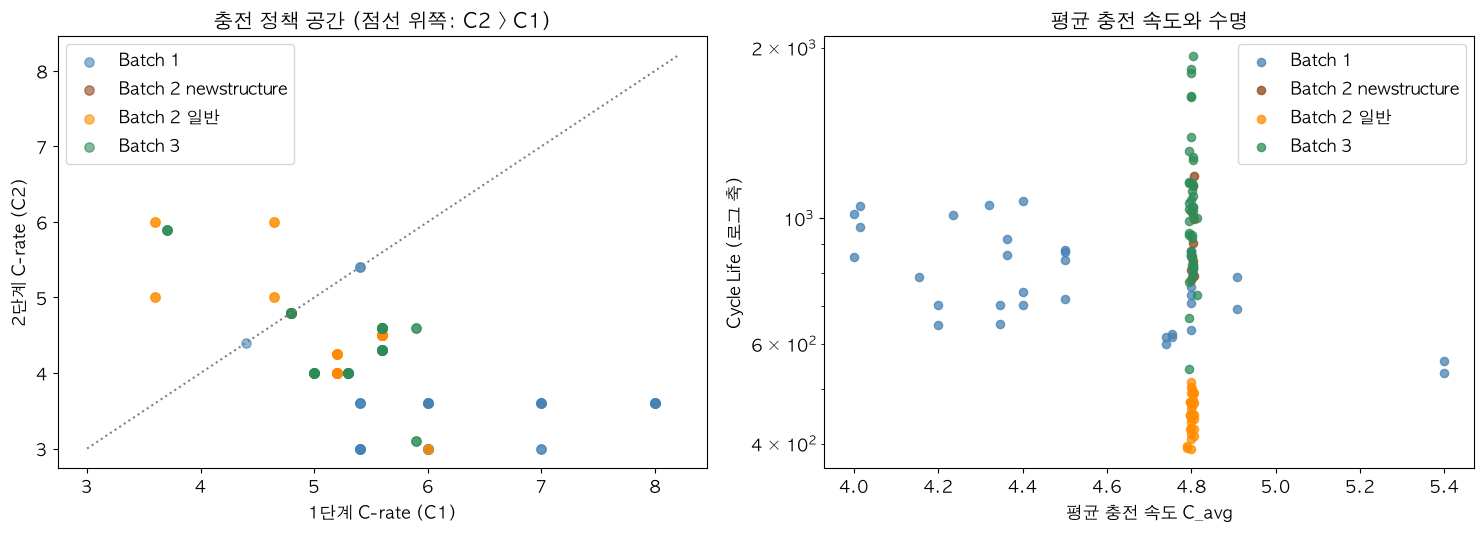

In [56]:
print('C_avg와 log_life의 상관계수')
print(feat.groupby('group').apply(lambda g: g['C_avg'].corr(g['log_life'])).round(2))

gcolors = {'Batch 1': 'steelblue', 'Batch 2 일반': 'darkorange',
           'Batch 2 newstructure': 'saddlebrown', 'Batch 3': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name, g in feat.groupby('group'):
    axes[0].scatter(g['C1'], g['C2'], color=gcolors[name], s=45, alpha=0.6, label=name)
    axes[1].scatter(g['C_avg'], g['cycle_life'], color=gcolors[name], s=35, alpha=0.75, label=name)

axes[0].plot([3, 8.2], [3, 8.2], color='gray', linestyle=':')
axes[0].set_xlabel('1단계 C-rate (C1)')
axes[0].set_ylabel('2단계 C-rate (C2)')
axes[0].set_title('충전 정책 공간 (점선 위쪽: C2 > C1)')
axes[0].legend()

axes[1].set_yscale('log')
axes[1].set_xlabel('평균 충전 속도 C_avg')
axes[1].set_ylabel('Cycle Life (로그 축)')
axes[1].set_title('평균 충전 속도와 수명')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q4_policy.png'), dpi=150)
plt.show()

**결과 해석 — 평균 충전 속도와 수명**

- **Batch 1에서는 빠르게 충전할수록 수명이 짧다.** `C_avg`와 `log_life`의 상관계수가 −0.59다. 가장 빠른 정책(`C_avg` 5.4)의 두 셀이 수명 550 안팎으로 가장 짧다.
- **나머지 집단의 상관계수(+0.34, +0.33, −0.02)는 의미가 없다.** `C_avg`의 범위가 4.79~4.81로 사실상 하나의 값이어서, 관계가 아니라 미세한 차이에서 계산된 숫자다.
- **같은 평균 충전 속도에서 수명이 크게 다르다.** `C_avg` 4.8인 셀들의 수명이 약 390부터 1,930까지 걸쳐 있다. 충전 속도가 같아도 수명은 5배 가까이 차이 난다.
- **정책 공간이 다르다.** Batch 1의 정책은 모두 1단계가 2단계보다 빠르거나 같다(C1 ≥ C2). Batch 2 일반과 Batch 3에는 2단계가 더 빠른 정책(C2 > C1)이 있고, Batch 1에는 이 영역의 정책이 없다.

**시사점**
- "고속 충전 셀이 수명이 짧다"는 **Batch 1 안에서만 확인되는 관계**다. Batch 1이 충전 속도를 다양하게 바꿔 가며 실험했기 때문에 나타난다.
- 테스트 배치는 충전 속도가 고정되어 있으므로, `C_avg`나 충전 시간을 피처로 넣으면 Batch 1에서는 성능이 좋아지지만 테스트에서는 도움이 되지 않는다. 오히려 Batch 1에만 맞는 관계를 학습해 일반화를 해칠 수 있다.
- 충전 조건(입력)이 같아도 수명이 크게 다르므로, 조건이 아니라 **셀이 그 조건에 어떻게 반응했는지**(ΔQ 같은 측정 신호)를 봐야 한다.

### Q4-3. Batch 1의 상관이 일부 셀에 좌우되는가

**목적**: Q4-2에서 Batch 1의 `C_avg`와 `log_life`의 상관이 −0.59였다. 그런데 산점도에서 `C_avg` 5.4인 두 셀이 다른 셀들과 멀리 떨어져 있다. 멀리 떨어진 점은 상관계수를 크게 좌우하므로, 이 관계가 두 셀에 의존하는지 확인한다.
- 두 셀을 제외하고 상관을 다시 계산한다
- 순위 상관(Spearman)도 함께 본다. 값의 크기가 아니라 순위만 쓰므로 멀리 떨어진 점의 영향을 덜 받는다

In [58]:
b1 = feat[feat['batch'] == 1]
rest = b1[b1['C_avg'] < 5.0]

print('Batch 1 전체 (36셀)')
print('  Pearson :', round(b1['C_avg'].corr(b1['log_life']), 2))
print('  Spearman:', round(b1['C_avg'].corr(b1['log_life'], method='spearman'), 2))
print(f'C_avg 5.4인 셀 제외 ({len(rest)}셀)')
print('  Pearson :', round(rest['C_avg'].corr(rest['log_life']), 2))
print('  Spearman:', round(rest['C_avg'].corr(rest['log_life'], method='spearman'), 2))

Batch 1 전체 (36셀)
  Pearson : -0.59
  Spearman: -0.43
C_avg 5.4인 셀 제외 (34셀)
  Pearson : -0.45
  Spearman: -0.33


**결과 해석 — Batch 1 상관의 안정성**

- **`C_avg` 5.4인 두 셀을 제외하면 상관이 약해진다.** Pearson이 −0.59에서 −0.45로, Spearman이 −0.43에서 −0.33으로 내려간다.
- **방향은 유지된다.** 네 값 모두 음수다. 빠르게 충전할수록 수명이 짧다는 경향은 두 셀 없이도 남아 있다.
- 순위 상관(Spearman)이 Pearson보다 일관되게 약하다. Pearson의 −0.59는 멀리 떨어진 점들의 영향을 받은 값이다.
- 따라서 Batch 1에서 충전 속도와 수명의 관계는 **있지만 약한 편**이다(−0.33 ~ −0.59). `log_var`의 상관(−0.84)에 비해 훨씬 약하다.

**해석 시 유의할 점**: 이 값은 가장 느린 충전 정책(3.6C, 4C)의 5셀이 빠진 상태로 계산됐다. 이 셀들은 EOL 미도달로 제외됐는데(Q2-3), 수명이 가장 길었을 것으로 보인다. 실제 관계는 계산된 값보다 강할 수 있으나, 실제 수명을 알 수 없어 확인할 수 없다.

**시사점**: `C_avg`는 Batch 1 안에서도 수명을 강하게 설명하지 못한다. 테스트 배치에서 변동이 없다는 점(Q4-1)과 함께, 피처로 쓸 근거가 약하다.

### Q4-4. 충전 프로토콜별 수명 비교

**목적**: 충전 정책에 따라 수명이 어떻게 다른지 집단별로 비교한다.
- 정책별 평균 수명의 순서에 규칙이 있는가 (빠른 정책일수록 짧은가)
- 같은 정책 안에서 셀들의 수명은 얼마나 흩어져 있는가
- 정책 간 차이가 정책 내 흩어짐보다 큰가

정책당 셀 수가 적으므로(Batch 1은 1~2개) 막대와 오차 막대 대신 셀 하나하나를 점으로 표시하고, 정책별 평균을 가로선으로 그린다.

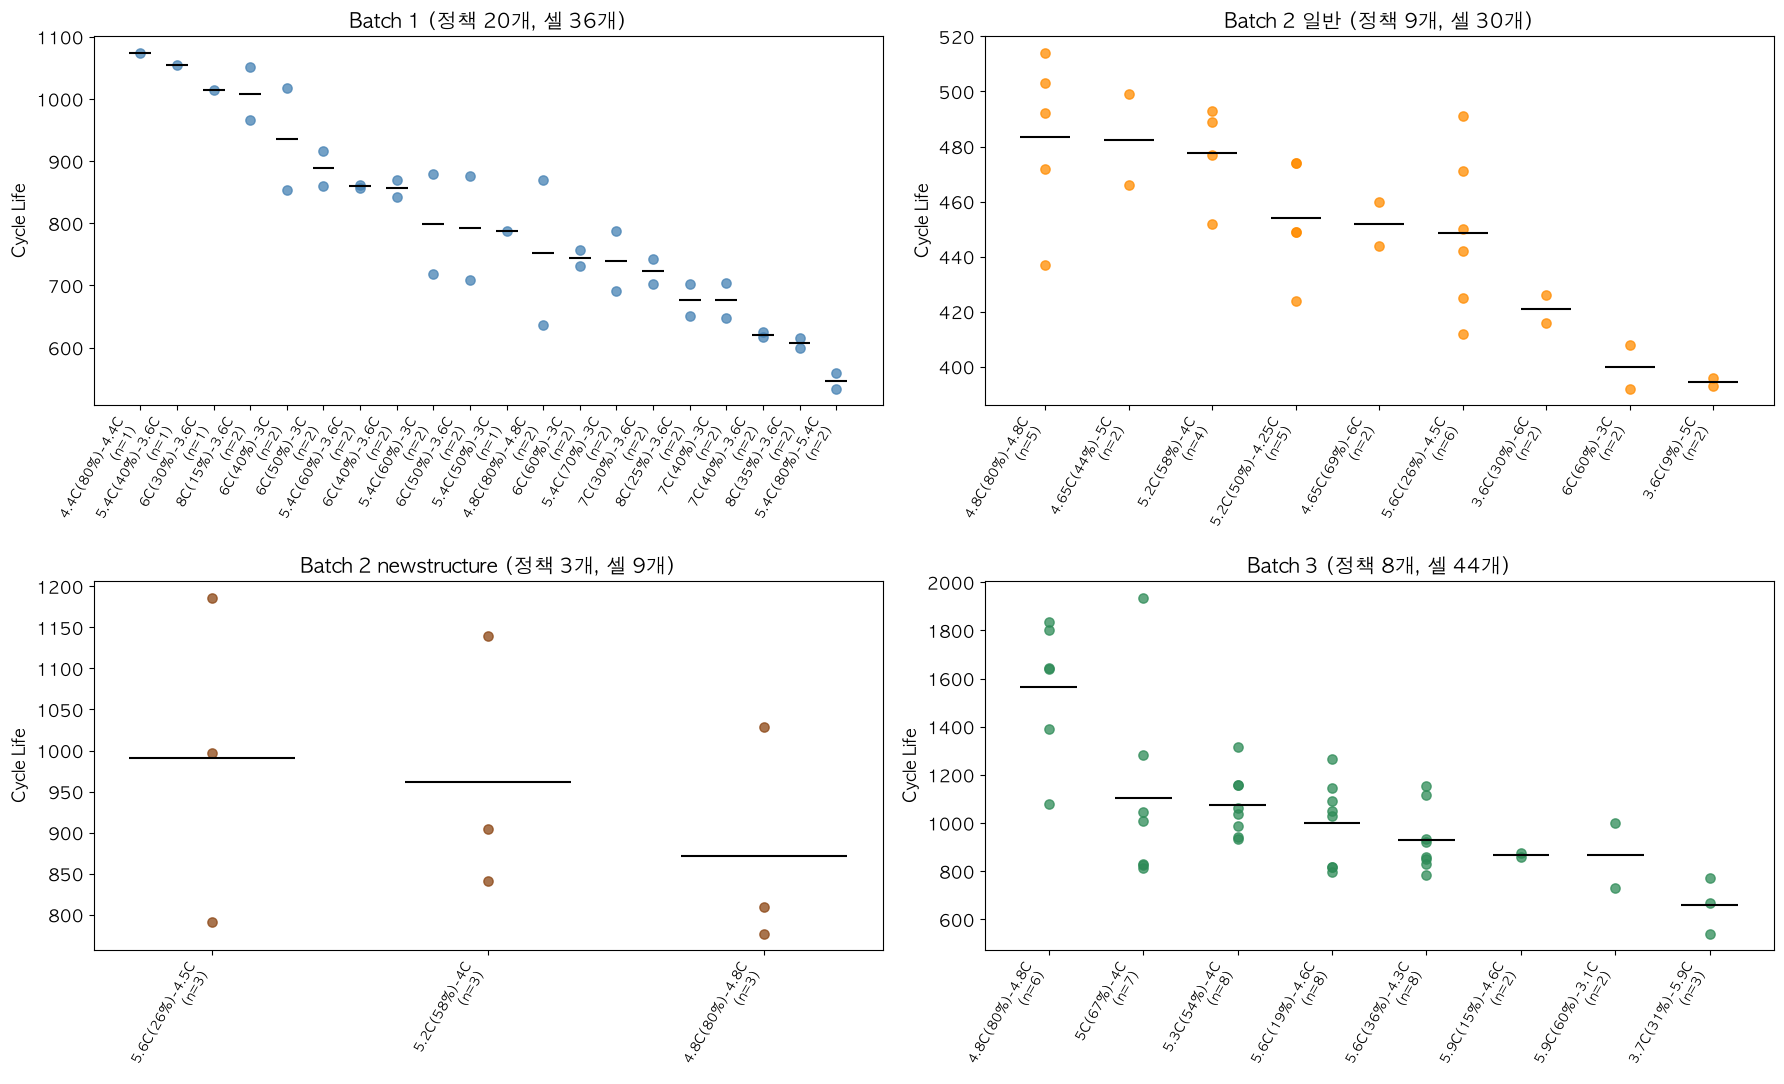

In [59]:
order = ['Batch 1', 'Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

for ax, name in zip(axes.ravel(), order):
    g = feat[feat['group'] == name]
    stat = g.groupby('policy')['cycle_life'].agg(['mean', 'size']).sort_values('mean', ascending=False)
    for x, (pol, row) in enumerate(stat.iterrows()):
        y = g.loc[g['policy'] == pol, 'cycle_life']
        ax.scatter([x] * len(y), y, color=gcolors[name], s=45, alpha=0.75)
        ax.hlines(row['mean'], x - 0.3, x + 0.3, color='black', linewidth=1.5)
    ax.set_xticks(range(len(stat)))
    ax.set_xticklabels([f'{p}\n(n={n})' for p, n in zip(stat.index, stat['size'])],
                       rotation=60, ha='right', fontsize=9)
    ax.set_ylabel('Cycle Life')
    ax.set_title(f'{name} (정책 {len(stat)}개, 셀 {len(g)}개)')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q4_policy_life.png'), dpi=150)
plt.show()

**같은 내용을 가로형으로 다시 그림**

위 그래프는 정책 이름이 기울어져 있고 집단마다 세로축 범위가 달라 읽기 어렵다. 정책 이름을 세로축에 두고, 충전 시간이 10분으로 고정된 세 집단은 수명 축을 공유하도록 다시 그린다.

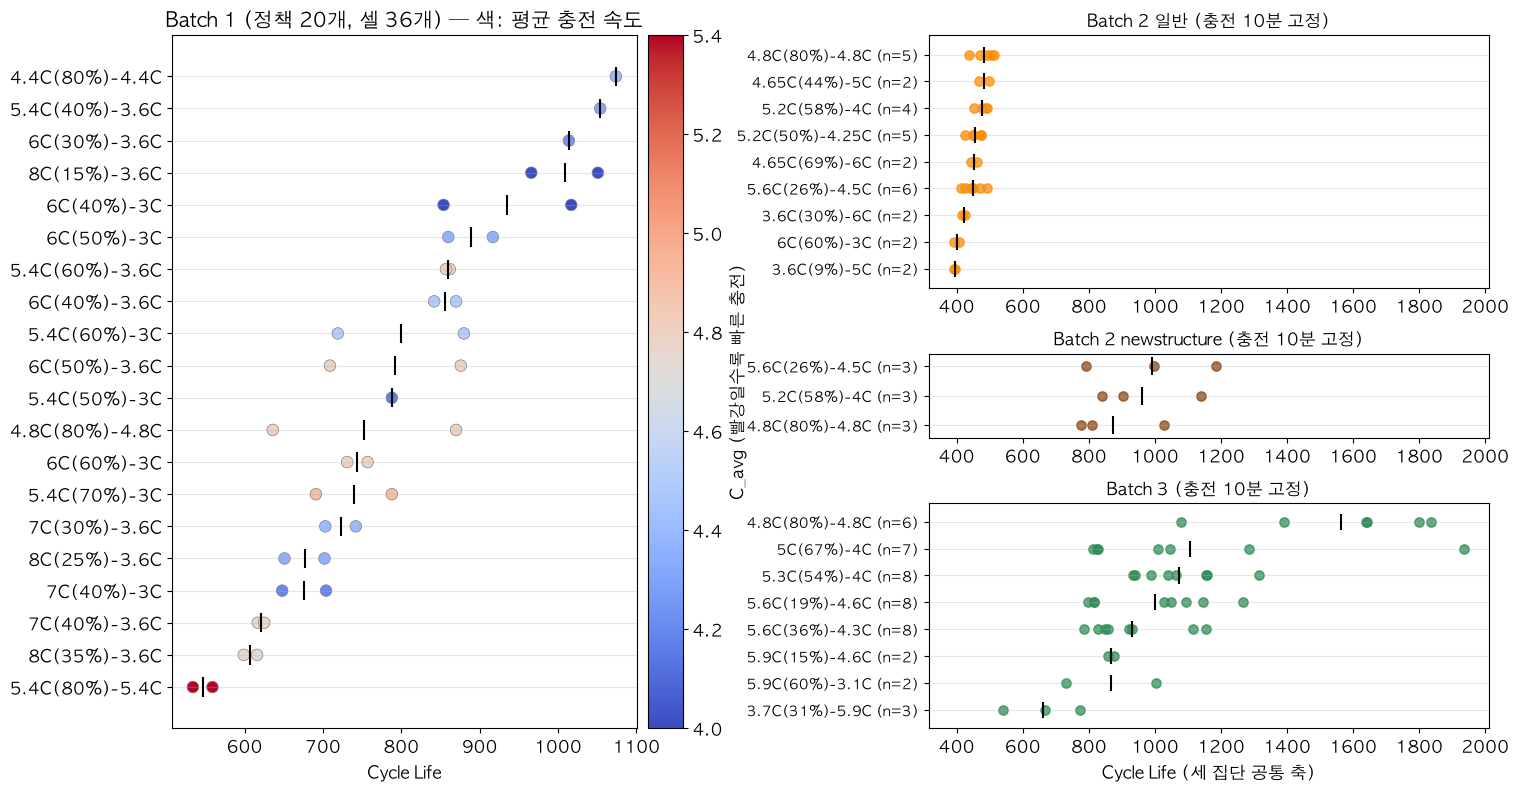

In [60]:
fig = plt.figure(figsize=(17, 9))
gs = fig.add_gridspec(3, 2, height_ratios=[9, 3, 8], width_ratios=[1, 1], hspace=0.35, wspace=0.35)

# 왼쪽: Batch 1 (색 = 평균 충전 속도)
ax1 = fig.add_subplot(gs[:, 0])
g = feat[feat['group'] == 'Batch 1']
stat = g.groupby('policy').agg(mean=('cycle_life', 'mean'), C_avg=('C_avg', 'first')).sort_values('mean')
ypos = {p: i for i, p in enumerate(stat.index)}
sc = ax1.scatter(g['cycle_life'], g['policy'].map(ypos), c=g['C_avg'], cmap='coolwarm', s=70,
                 edgecolors='gray', linewidths=0.5)
for p, row in stat.iterrows():
    ax1.vlines(row['mean'], ypos[p] - 0.3, ypos[p] + 0.3, color='black', linewidth=1.5)
ax1.set_yticks(range(len(stat)))
ax1.set_yticklabels(stat.index)
ax1.set_xlabel('Cycle Life')
ax1.set_title('Batch 1 (정책 20개, 셀 36개) — 색: 평균 충전 속도')
ax1.grid(axis='y', alpha=0.3)
fig.colorbar(sc, ax=ax1, label='C_avg (빨강일수록 빠른 충전)', pad=0.02)

# 오른쪽: 충전 시간 10분 고정인 세 집단 (수명 축 공유)
names = ['Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']
ax_ref = None
for i, name in enumerate(names):
    ax = fig.add_subplot(gs[i, 1], sharex=ax_ref)
    ax_ref = ax_ref or ax
    g = feat[feat['group'] == name]
    stat = g.groupby('policy')['cycle_life'].agg(['mean', 'size']).sort_values('mean')
    ypos = {p: k for k, p in enumerate(stat.index)}
    ax.scatter(g['cycle_life'], g['policy'].map(ypos), color=gcolors[name], s=45, alpha=0.75)
    for p, row in stat.iterrows():
        ax.vlines(row['mean'], ypos[p] - 0.3, ypos[p] + 0.3, color='black', linewidth=1.5)
    ax.set_yticks(range(len(stat)))
    ax.set_yticklabels([f'{p} (n={n})' for p, n in zip(stat.index, stat['size'])], fontsize=10)
    ax.set_title(f'{name} (충전 10분 고정)', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
ax.set_xlabel('Cycle Life (세 집단 공통 축)')

plt.savefig(os.path.join(FIG_DIR, 'q4_policy_life.png'), dpi=150, bbox_inches='tight')
plt.show()

### Q4-4-1. 충전 프로토콜별 평균 수명 비교(가독성이 좋지않아 추가)

**목적**: Batch 1에서 충전 정책별 평균 수명을 비교해, 빠른 충전 정책일수록 수명이 짧은지 확인한다.
- 정책을 평균 수명 순으로 나열하고, 평균 충전 속도(`C_avg`)를 세 구간(느림, 중간, 빠름)으로 나눠 색으로 표시한다
- Batch 1만 대상으로 한다. 나머지 집단은 평균 충전 속도가 모두 같아(Q4-1) 이 비교가 성립하지 않는다

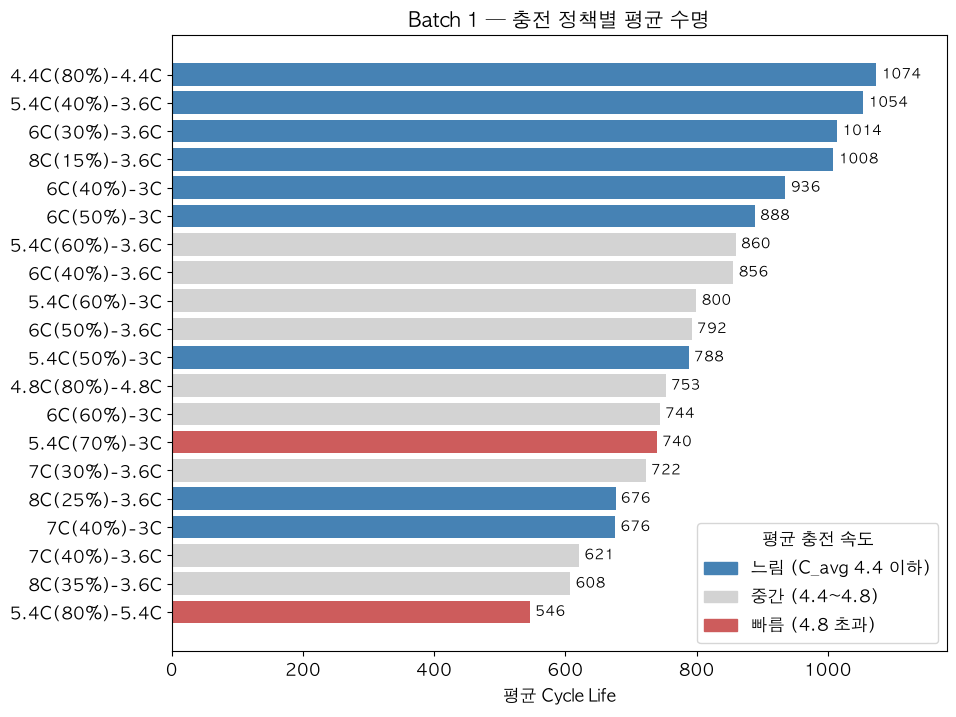

speed
느림    9
중간    9
빠름    2
Name: count, dtype: int64


In [61]:
g = feat[feat['group'] == 'Batch 1']
stat = (g.groupby('policy')
        .agg(mean=('cycle_life', 'mean'), n=('cycle_life', 'size'), C_avg=('C_avg', 'first'))
        .sort_values('mean'))

# 충전 속도를 세 구간으로 나눔
stat['speed'] = pd.cut(stat['C_avg'], bins=[0, 4.4, 4.8, 10], labels=['느림', '중간', '빠름'])
palette = {'느림': 'steelblue', '중간': 'lightgray', '빠름': 'indianred'}

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(stat.index, stat['mean'], color=stat['speed'].map(palette).tolist())
for i, (p, row) in enumerate(stat.iterrows()):
    ax.text(row['mean'] + 8, i, f"{row['mean']:.0f}", va='center', fontsize=10)

ax.set_xlabel('평균 Cycle Life')
ax.set_title('Batch 1 — 충전 정책별 평균 수명')
ax.set_xlim(0, stat['mean'].max() * 1.1)
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in palette.values()],
          labels=['느림 (C_avg 4.4 이하)', '중간 (4.4~4.8)', '빠름 (4.8 초과)'],
          title='평균 충전 속도', loc='lower right')
plt.savefig(os.path.join(FIG_DIR, 'q4_policy_life.png'), dpi=150, bbox_inches='tight')
plt.show()

print(stat['speed'].value_counts())

**결과 해석 — Batch 1의 충전 정책별 평균 수명**

- **느린 충전 정책이 대체로 수명이 길다.** 평균 수명 상위 6개 정책(888~1,074)이 모두 평균 충전 속도가 느린 구간(`C_avg` 4.4 이하)이다. 가장 짧은 정책(546)은 가장 빠른 `5.4C(80%)-5.4C`다.
- **평균 속도만으로는 순서가 설명되지 않는다.** 느린 구간에 속하는데도 수명이 짧은 정책이 있다. `8C(25%)-3.6C`와 `7C(40%)-3C`는 676으로, 같은 구간의 다른 정책보다 200~400사이클 짧다.
- **1단계 속도와 그 지속 구간이 함께 작용하는 것으로 보인다.** 8C로 시작하는 세 정책을 보면, 8C 구간이 15%일 때 1,008, 25%일 때 676, 35%일 때 608이다. 빠른 구간이 길어질수록 수명이 짧다.
- 구간별 정책 수는 느림 9개, 중간 9개, 빠름 2개다. 빠른 구간은 정책이 2개뿐이라 이 구간만으로 경향을 말하기는 어렵다.

**시사점**
- Q4-3에서 `C_avg`와 수명의 상관이 약했던 것(−0.33 ~ −0.59)이 그림으로 확인된다. 평균 충전 속도는 수명의 일부만 설명한다.
- 충전 조건의 영향은 평균 속도 하나로 요약되지 않고, 단계별 속도와 전환 시점의 조합에 달려 있다. 정책 20가지에 셀이 36개뿐이어서, 이 조합의 효과를 Batch 1만으로 학습하기는 어렵다.

### Q4-5. 충전 전류 패턴과 열화 속도

**목적**: 충전 패턴이 열화의 어느 부분과 관련되는지 확인한다.
- 충전 패턴: 1단계 속도(`C1`), 전환 시점(`Q1`), 2단계 속도(`C2`), 평균 속도(`C_avg`)
- 열화 지표(Q2-7): knee 이전 열화 속도(`rate_before`), knee 이후 열화 속도(`rate_after`), knee 시점(`knee`)
- Q4-4에서 평균 속도만으로는 수명 순서가 설명되지 않았다. 단계별 속도와 전환 시점이 열화와 어떻게 관련되는지 본다

집단별로 상관계수를 계산한다. 충전 시간이 10분으로 고정된 집단에서는 `C_avg`에 변동이 없으므로 `C1`, `Q1`, `C2`만 의미가 있다.

In [62]:
pat = feat[['cell_id', 'group', 'C1', 'Q1', 'C2', 'C_avg', 'log_life']].merge(
    knee[['cell_id', 'knee', 'rate_before', 'rate_after']], on='cell_id')

x_cols = ['C1', 'Q1', 'C2', 'C_avg']
y_cols = ['rate_before', 'rate_after', 'knee', 'log_life']

for name in ['Batch 1', 'Batch 2 일반', 'Batch 3']:
    g = pat[pat['group'] == name]
    c = pd.DataFrame({y: [g[x].corr(g[y]) for x in x_cols] for y in y_cols}, index=x_cols)
    print(f'=== {name} (셀 {len(g)}개) ===')
    print(c.round(2))
    print()

=== Batch 1 (셀 36개) ===
       rate_before  rate_after  knee  log_life
C1           -0.10        0.28 -0.28     -0.24
Q1            0.41        0.05 -0.13     -0.18
C2            0.67        0.18 -0.17     -0.29
C_avg         0.66        0.41 -0.55     -0.59

=== Batch 2 일반 (셀 30개) ===
       rate_before  rate_after  knee  log_life
C1           -0.37        0.29  0.14      0.16
Q1           -0.33        0.18  0.47      0.49
C2            0.59       -0.57 -0.15      0.04
C_avg         0.17       -0.09  0.16      0.33

=== Batch 3 (셀 44개) ===
       rate_before  rate_after  knee  log_life
C1           -0.63        0.43 -0.06      0.02
Q1           -0.35       -0.15  0.59      0.52
C2            0.67       -0.55 -0.12     -0.13
C_avg        -0.24        0.28 -0.00     -0.02



**결과 해석 — 충전 패턴과 열화 속도**

- **`C2`와 초반 열화 속도(`rate_before`)의 상관은 세 집단에서 +0.59 ~ +0.67로 나타난다.** Batch 1 +0.67, Batch 2 일반 +0.59, Batch 3 +0.67이다. 다만 산점도를 보면 이 관계는 `C2`가 가장 큰 소수의 셀이 만든 것이다(아래 그래프 해석 참고).
- **그러나 이 관계는 수명으로 이어지지 않는다.** `C2`와 `log_life`의 상관은 −0.29, +0.04, −0.13이다. Batch 2 일반과 Batch 3에서는 `C2`가 클수록 knee 이후의 열화가 오히려 완만하다(`rate_after`와의 상관 −0.57, −0.55). 초반과 후반의 효과가 반대 방향이다.
- **수명과 가장 관련되는 변수가 집단마다 다르다.** Batch 1에서는 `C_avg`(−0.59)이고, Batch 2 일반과 Batch 3에서는 `Q1`(+0.49, +0.52)이다. Batch 1에서 `Q1`과 수명의 상관은 −0.18로 부호가 반대다.
- **부호가 뒤집히는 관계가 여럿이다.** `Q1`과 `rate_before`는 Batch 1 +0.41, Batch 2 일반 −0.33, Batch 3 −0.35다. `C2`와 `rate_after`는 Batch 1 +0.18, 나머지 −0.57, −0.55다.
- 집단마다 관계가 다른 것은 실험 설계가 다르기 때문이다. Batch 1은 평균 충전 속도를 바꿔 가며 실험했고, 나머지는 충전 시간을 10분으로 고정한 채 속도의 배분만 바꿨다(Q4-1).

**시사점**
- 충전 패턴 변수는 열화의 일부 구간(초반 열화)과는 일관되게 관련되지만, **최종 수명과의 관계는 집단마다 방향이 다르다.** Batch 1에서 학습한 관계를 테스트 배치에 적용하면 반대 방향의 예측을 하게 될 수 있다.
- Q2-6에서 얻은 원칙("학습 배치에서의 상관만으로 피처를 고르면 안 된다")이 충전 패턴 변수에서도 확인된다.

**그래프: 2단계 충전 속도와 열화**

상관표에서 세 집단에 걸쳐 일관된 관계는 `C2`와 `rate_before`였다. 이 관계를 산점도로 확인하고, 같은 `C2`가 수명과는 어떤 관계인지 나란히 비교한다.

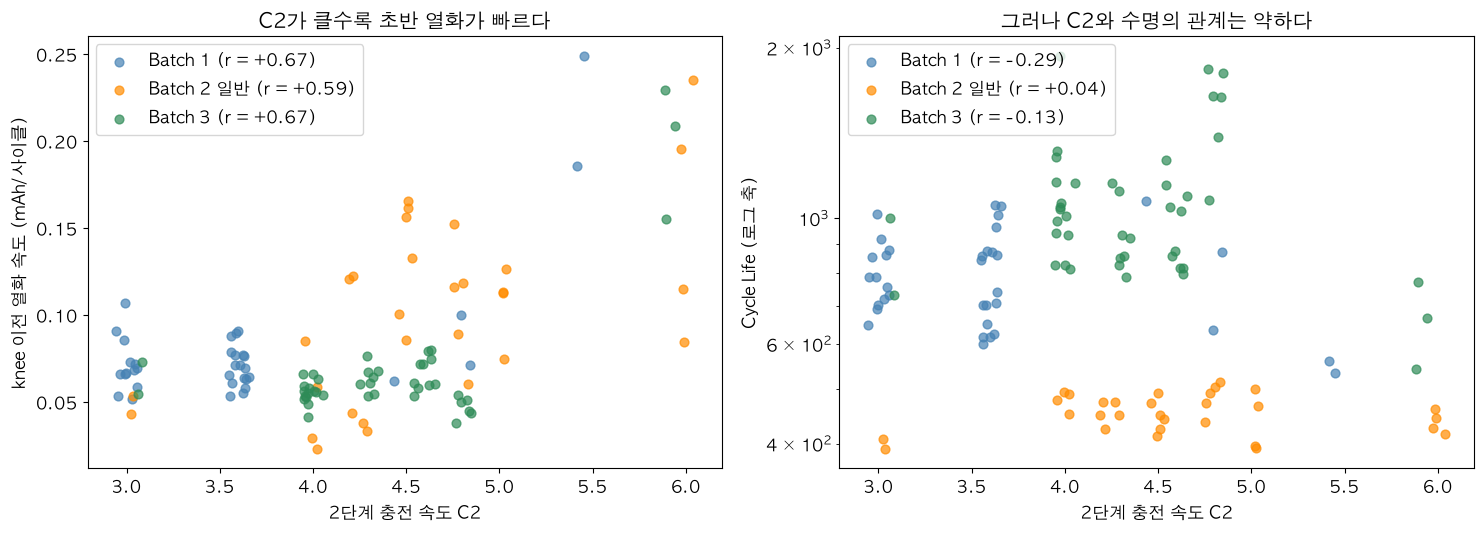

In [63]:
rng = np.random.default_rng(SEED)
names = ['Batch 1', 'Batch 2 일반', 'Batch 3']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for name in names:
    g = pat[pat['group'] == name]
    x = g['C2'] + rng.uniform(-0.06, 0.06, len(g))     # 겹친 점이 보이도록 좌우로 살짝 흩뜨림
    r1 = g['C2'].corr(g['rate_before'])
    r2 = g['C2'].corr(g['log_life'])
    axes[0].scatter(x, g['rate_before'], color=gcolors[name], s=40, alpha=0.7,
                    label=f'{name} (r = {r1:+.2f})')
    axes[1].scatter(x, 10 ** g['log_life'], color=gcolors[name], s=40, alpha=0.7,
                    label=f'{name} (r = {r2:+.2f})')

axes[0].set_xlabel('2단계 충전 속도 C2')
axes[0].set_ylabel('knee 이전 열화 속도 (mAh/사이클)')
axes[0].set_title('C2와 knee 이전 열화 속도')
axes[0].legend()

axes[1].set_yscale('log')
axes[1].set_xlabel('2단계 충전 속도 C2')
axes[1].set_ylabel('Cycle Life (로그 축)')
axes[1].set_title('C2와 수명')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q4_c2_degradation.png'), dpi=150)
plt.show()

**결과 해석 — 2단계 충전 속도와 열화 (그래프)**

- **`C2`와 초반 열화의 관계는 전 구간에 걸친 것이 아니다.** `C2`가 3.0~5.0인 구간에서는 대부분의 셀이 0.04~0.10mAh/사이클에 모여 있고, `C2`에 따른 증가가 뚜렷하지 않다. 높은 값(0.15~0.25)은 `C2`가 5.4 이상인 소수의 셀에서만 나타난다.
- **상관계수 +0.59 ~ +0.67은 이 소수의 셀에 좌우된 값이다.** Q4-3에서 `C_avg`의 상관이 두 셀에 좌우됐던 것과 같은 현상이다.
- **Batch 1의 오른쪽 끝 두 셀은 한 단계짜리 정책(`5.4C(80%)-5.4C`)이다.** 2단계 구간이 없으므로, 이 두 셀의 빠른 열화는 2단계 속도가 아니라 전 구간을 5.4C로 충전한 결과다.
- **같은 `C2`에서도 집단에 따라 초반 열화 속도가 다르다.** `C2` 4.2~4.8에서 Batch 2 일반 셀은 0.10~0.17, Batch 3 셀은 0.04~0.08이다.
- **`C2`와 수명의 관계는 보이지 않는다.** 세 집단 모두 `C2`에 따른 경향이 없고, 집단 간 수명 수준의 차이가 훨씬 크다.

**시사점**
- 상관계수가 세 집단에서 같은 부호로 나왔더라도, 산점도로 확인하면 소수의 셀이 만든 관계일 수 있다. **상관계수는 산점도와 함께 봐야 한다.**
- 매우 빠른 충전(5.4C 이상)이 초반 열화를 빠르게 한다는 것까지는 말할 수 있으나, 그 이하 구간에서 충전 속도와 열화 속도의 관계는 이 데이터로 확인되지 않는다.

### Q4 결론

**확인한 사실**
1. Batch 1은 평균 충전 속도가 다양하다(`C_avg` 4.00~5.40, 충전 시간 8.89~12.00분). 나머지 집단은 충전 시간이 10분으로 고정되어 `C_avg`가 4.79~4.81이다. 정책 공간도 달라, Batch 1에는 없는 C2 > C1 정책이 테스트 배치에 있다.
2. Batch 1에서 빠르게 충전할수록 수명이 짧은 경향이 있으나 관계는 약하다. `C_avg`와 `log_life`의 상관이 −0.59이고, 가장 빠른 두 셀을 제외하면 −0.45, 순위 상관으로는 −0.33 ~ −0.43이다.
3. 같은 평균 충전 속도(`C_avg` 4.8)에서 수명이 약 390부터 1,930까지 걸쳐 있다.
4. Batch 1에서 평균 수명 상위 6개 정책은 모두 느린 충전이지만, 느린 충전인데 수명이 짧은 정책도 있다(`8C(25%)-3.6C`, `7C(40%)-3C`는 676). 8C로 시작하는 정책은 8C 구간이 15%, 25%, 35%로 길어질수록 수명이 1,008, 676, 608로 짧아진다. 평균 속도만으로는 순서가 설명되지 않는다.
5. `C2`와 초반 열화 속도의 상관은 세 집단에서 +0.59 ~ +0.67이지만, `C2`가 5.4 이상인 소수의 셀이 만든 값이다. 그 이하 구간에서는 관계가 뚜렷하지 않고, 수명과의 관계는 보이지 않는다.
6. 수명과 가장 관련되는 충전 변수가 집단마다 다르다. Batch 1에서는 `C_avg`(−0.59)이고, Batch 2 일반과 Batch 3에서는 `Q1`(+0.49, +0.52)이다. Batch 1에서 `Q1`과 수명의 상관은 −0.18로 부호가 반대다.

**모델 설계에 주는 시사점**
- **충전 정책에서 나온 변수(`C1`, `Q1`, `C2`, `C_avg`)와 충전 시간은 피처에서 제외한다.**
  - 테스트 배치에서는 `C_avg`에 변동이 없어 셀을 구분하지 못한다. (사실 1)
  - Batch 1 안에서도 관계가 약하고 일부 셀에 좌우된다. (사실 2, 4, 5)
  - 수명과의 관계가 집단마다 방향이 달라, Batch 1에서 학습한 관계가 테스트 배치에서 반대로 작동할 수 있다. (사실 6)
- **조건(입력)이 아니라 셀의 반응(측정 신호)을 피처로 쓴다.** 충전 조건이 같아도 수명은 크게 다르다. (사실 3)
- **충전 조건의 효과는 Batch 1만으로 안정적으로 학습하기 어렵다.** 효과가 평균 속도 하나가 아니라 단계별 속도와 전환 시점의 조합으로 나타나는데, Batch 1은 정책 20가지에 셀이 36개뿐이다. (사실 4)
- **상관계수는 산점도와 함께 확인한다.** `C_avg`와 수명(Q4-3), `C2`와 초반 열화(Q4-5) 모두 소수의 셀이 상관계수를 끌어올리고 있었다. (사실 2, 5)

**해석 시 유의할 점**
- Batch 1의 수치는 가장 느린 충전 정책(3.6C, 4C)의 5셀이 빠진 상태로 계산됐다. 이 셀들은 EOL 미도달로 제외됐는데(Q2-3) 수명이 가장 길었을 것으로 보인다. 충전 속도와 수명의 실제 관계는 계산된 값보다 강할 수 있다.
- Q4-4의 관찰(8C 구간이 길수록 수명이 짧다)은 정책 3개, 셀 6개에서 본 것이다.

**남은 질문**
- 충전 정책 외의 피처(온도, 내부 저항, 용량 관련 값)는 수명과 어떤 관계인가. 배치 간에 일관되는가 → Q5

## Q5. 상관관계: 어떤 신호가 수명과 연관되어 있는가?

**목적**: 초기 100사이클로 만들 수 있는 피처들을 수명과 비교해, 모델에 쓸 피처를 고른다.
- 수명과 가장 강하게 연관된 피처는 무엇인가
- 그 관계의 방향이 집단 간에 유지되는가 (Q2-6, Q4에서 Batch 1의 상관이 다른 집단에서 뒤집히는 사례를 확인했다)
- 피처끼리 서로 중복되지는 않는가 (다중공선성)

### Q5-1. 초기 사이클 피처 만들기

**목적**: 사이클별 요약(`summary`)에서 초기 100사이클의 방전 용량, 온도, 내부 저항, 충전 시간 피처를 셀 단위로 계산한다.
- 사이클은 측정 순서 기준으로 센다(Q3-2). Batch 1은 첫 사이클이 비어 있으므로 `cycle − 1`이 측정 순서다.
- 2번째부터 100번째 측정 사이클을 사용한다.
- 정제된 데이터(`d_clean`)를 사용하고, 내부 저항이 0인 행과 충전 시간이 60분을 넘는 행은 제외한다.

In [64]:
e = d_clean.copy()
e['k'] = e['cycle'] - e['cell_id'].map(first_valid)     # 측정 순서 (1부터)
e = e[e['k'].between(2, 100)]

rows = []
for cid, g in e.groupby('cell_id'):
    g = g.sort_values('k')
    last = g[g['k'] >= 91]
    ir = g.loc[g['IR'] > 0, 'IR']
    ct = g.loc[(g['k'] <= 6) & (g['chargetime'] < 60), 'chargetime']
    rows.append({
        'cell_id': cid,
        'qd_2': g['QD'].iloc[0],
        'qd_100': g['QD'].iloc[-1],
        'qd_change': g['QD'].iloc[-1] - g['QD'].iloc[0],
        'qd_slope_all': np.polyfit(g['k'], g['QD'], 1)[0],
        'qd_slope_last': np.polyfit(last['k'], last['QD'], 1)[0],
        'T_avg': g['Tavg'].mean(),
        'T_max': g['Tmax'].max(),
        'T_min': g['Tmin'].min(),
        'ir_2': ir.iloc[0] if len(ir) else np.nan,
        'ir_min': ir.min() if len(ir) else np.nan,
        'ir_change': ir.iloc[-1] - ir.iloc[0] if len(ir) else np.nan,
        'chargetime': ct.mean(),
    })
early_feat = pd.DataFrame(rows)

feat5 = feat[['cell_id', 'batch', 'group', 'cycle_life', 'log_life',
              'log_var', 'log_min', 'log_mean', 'C_avg']].merge(early_feat, on='cell_id')

print(feat5.shape)
print('결측치:')
print(feat5.isna().sum()[feat5.isna().sum() > 0])

(119, 21)
결측치:
ir_2         6
ir_min       6
ir_change    6
dtype: int64


**결과 해석 — 초기 사이클 피처**

- 분석 대상 119셀 모두 피처가 계산됐다.
- **내부 저항 피처 3개(`ir_2`, `ir_min`, `ir_change`)에 결측이 6셀 있다.** 세 피처의 결측 수가 같으므로, 같은 6셀에서 초기 100사이클의 내부 저항이 기록되지 않은 것으로 보인다. 어느 집단의 셀인지 확인이 필요하다.
- 나머지 피처에는 결측이 없다.

### 점검 1. 내부 저항 결측과 0 값

결측 6셀이 어느 집단에 있는지, 왜 결측인지 확인한다. 초기 100사이클의 IR 값이 모두 0이면 결측으로 처리되도록 계산했다.

In [65]:
miss = feat5[feat5['ir_2'].isna()]
print(miss[['cell_id', 'group', 'cycle_life']])

# 이 셀들의 초기 IR 원본 값
print(e[e['cell_id'].isin(miss['cell_id'])].groupby('cell_id')['IR'].agg(['min', 'max', 'count']))

   cell_id                 group  cycle_life
69   b2c41            Batch 2 일반       442.0
70   b2c42            Batch 2 일반       474.0
71   b2c43  Batch 2 newstructure      1029.0
72   b2c44  Batch 2 newstructure       841.0
73   b2c45  Batch 2 newstructure       997.0
74   b2c46            Batch 2 일반       503.0
         min  max  count
cell_id                 
b2c41    0.0  0.0     99
b2c42    0.0  0.0     99
b2c43    0.0  0.0     99
b2c44    0.0  0.0     99
b2c45    0.0  0.0     98
b2c46    0.0  0.0     99


**결과 해석 — 내부 저항 결측 셀**

- **결측 6셀은 모두 Batch 2다.** 일반 3셀(b2c41, b2c42, b2c46)과 `newstructure` 3셀(b2c43, b2c44, b2c45)이다.
- **셀 번호가 b2c41~b2c46으로 연속이다.** 파일의 마지막 6셀에서 내부 저항이 기록되지 않았다.
- **초기 100사이클의 IR 값이 전부 0.0이다.** 실제 저항이 0일 수는 없으므로 측정되지 않은 값이다.

**시사점**
- 결측이 테스트 배치에만 있다. 내부 저항을 피처로 쓰면 Batch 2의 39셀 중 6셀(15%)을 예측할 수 없다.
- 결측을 다른 값으로 채워 예측하면 테스트 평가의 신뢰도가 떨어진다. **내부 저항 피처는 수명과의 상관과 무관하게 사용하기 어렵다.**

**점검: 다른 셀에도 IR이 0인 사이클이 있는가**

결측 6셀 외에도 초기 100사이클 중 일부 사이클에서 IR이 0으로 기록된 셀이 있는지 확인한다. 있다면 `ir_2`나 `ir_change`가 의도와 다른 사이클의 값으로 계산됐을 수 있다.

In [66]:
ir0 = e.assign(ir_zero=e['IR'] <= 0).groupby('cell_id')['ir_zero'].mean()
print('초기 100사이클에서 IR이 0인 비율이 0보다 큰 셀:')
print(ir0[ir0 > 0].round(2))

초기 100사이클에서 IR이 0인 비율이 0보다 큰 셀:
cell_id
b1c11    0.01
b1c16    0.01
b1c20    0.01
b1c21    0.01
b1c6     0.01
b1c7     0.01
b2c41    1.00
b2c42    1.00
b2c43    1.00
b2c44    1.00
b2c45    1.00
b2c46    1.00
Name: ir_zero, dtype: float64


**점검: Batch 1에서 IR이 0인 사이클의 위치**

Batch 1의 6셀에 IR이 0인 사이클이 하나씩 있다. 그 사이클이 맨 앞이나 맨 뒤라면 `ir_2`, `ir_change`가 의도와 다른 사이클의 값으로 계산됐을 수 있다. 위치를 확인한다.

In [67]:
b1_zero = e[(e['batch'] == 1) & (e['IR'] <= 0)]
print(b1_zero[['cell_id', 'cycle', 'k', 'IR', 'QD', 'chargetime']])

      cell_id  cycle   k   IR        QD  chargetime
11418   b1c11     12  11  0.0  1.063239   11.651725
15600   b1c16     13  12  0.0  1.081716   10.096540
18794   b1c20     13  12  0.0  1.068321    8.986702
19327   b1c21     13  12  0.0  1.078456    8.896768
7079     b1c6     13  12  0.0  1.077595   10.008047
7714     b1c7     13  12  0.0  1.094176   10.092503


**결과 해석 — IR이 0인 사이클의 분포와 위치**

- **Batch 2의 6셀은 초기 100사이클 전체가 0이다**(비율 1.00). 앞에서 확인한 결측 셀이다.
- **Batch 1의 6셀에도 IR이 0인 사이클이 하나씩 있다**(b1c6, b1c7, b1c11, b1c16, b1c20, b1c21).
- **그 위치가 거의 같다.** 5셀은 12번째 측정, 1셀은 11번째 측정이다. 서로 다른 셀이 같은 시점에 영향을 받았으므로 개별 셀이 아니라 시험 장비 쪽의 문제로 보인다.
- 같은 사이클의 방전 용량(1.06~1.09Ah)과 충전 시간(8.9~11.7분)은 정상 범위다. IR 측정만 빠진 것이다.
- 그 외 107셀은 초기 100사이클에서 IR이 0인 사이클이 없다.

**피처에 주는 영향**
- **Batch 1의 6셀은 영향이 없다.** `ir_2`는 2번째 측정, `ir_change`는 100번째와 2번째의 차이를 쓰는데, 0인 사이클은 11~12번째다. `ir_min`은 0보다 큰 값만으로 계산했으므로 0이 최솟값으로 잡히지 않는다.
- Batch 2의 6셀은 IR 피처가 결측이다.

### 점검 2. 피처 값의 범위

**목적**: 계산한 피처가 믿을 만한 값인지, 집단마다 수준이 다른지 확인한다.
- 물리적으로 나올 수 없는 값이 있는가 (예: 온도 0도, 음수 저항, 비정상적으로 긴 충전 시간)
- 집단 간에 값의 수준이 다른가. 수준이 다르면 그 피처는 셀의 특성과 함께 집단(시험 조건)의 차이도 담고 있다

피처별로 집단마다 최소, 중앙값, 최대를 비교한다.

In [68]:
check = ['qd_2', 'qd_change', 'qd_slope_all', 'qd_slope_last',
         'T_avg', 'T_max', 'T_min', 'ir_2', 'ir_change', 'chargetime']
order = ['Batch 1', 'Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']

for col in check:
    t = feat5.groupby('group')[col].agg(['min', 'median', 'max']).reindex(order)
    print(f'--- {col} ---')
    print(t.round(4))
    print()

--- qd_2 ---
                         min  median     max
group                                       
Batch 1               1.0550  1.0796  1.0959
Batch 2 일반            1.0697  1.0959  1.1093
Batch 2 newstructure  1.0672  1.0906  1.1030
Batch 3               1.0463  1.0653  1.0742

--- qd_change ---
                         min  median     max
group                                       
Batch 1              -0.0127  0.0011  0.0049
Batch 2 일반           -0.0229  0.0030  0.0128
Batch 2 newstructure -0.0046 -0.0007  0.0068
Batch 3              -0.0188  0.0014  0.0038

--- qd_slope_all ---
                         min  median     max
group                                       
Batch 1              -0.0001 -0.0000  0.0000
Batch 2 일반           -0.0002  0.0000  0.0001
Batch 2 newstructure -0.0001 -0.0001  0.0001
Batch 3              -0.0002 -0.0000  0.0000

--- qd_slope_last ---
                         min  median     max
group                                       
Batch 1              -0

**기울기 피처 다시 보기**

`qd_slope_all`과 `qd_slope_last`는 값이 매우 작아 소수점 넷째 자리에서 모두 0으로 표시됐다. 1,000을 곱해 mAh/사이클 단위로 다시 확인한다.

In [69]:
# 기울기 피처: 값이 작으므로 1000을 곱해 mAh/사이클 단위로 본다
for col in ['qd_slope_all', 'qd_slope_last']:
    t = (feat5.groupby('group')[col].agg(['min', 'median', 'max']).reindex(order) * 1000)
    print(f'--- {col} (mAh/사이클) ---')
    print(t.round(4))
    print()

--- qd_slope_all (mAh/사이클) ---
                         min  median     max
group                                       
Batch 1              -0.1434 -0.0097  0.0250
Batch 2 일반           -0.1990  0.0314  0.1201
Batch 2 newstructure -0.0825 -0.0546  0.0535
Batch 3              -0.2024 -0.0069  0.0097

--- qd_slope_last (mAh/사이클) ---
                         min  median     max
group                                       
Batch 1              -0.2343 -0.0364 -0.0006
Batch 2 일반           -0.4373 -0.0049  0.2377
Batch 2 newstructure  0.0028  0.0271  0.2309
Batch 3              -0.2673 -0.0518 -0.0072



**온도, 내부 저항, 충전 시간 다시 보기**

위 출력이 중간에 잘려 나머지 피처를 따로 출력한다.

In [70]:
# 온도, 내부 저항, 충전 시간
for col in ['T_avg', 'T_max', 'T_min', 'ir_2', 'ir_change', 'chargetime']:
    t = feat5.groupby('group')[col].agg(['min', 'median', 'max']).reindex(order)
    print(f'--- {col} ---')
    print(t.round(4))
    print()

--- T_avg ---
                          min   median      max
group                                          
Batch 1               30.3751  33.0249  33.8964
Batch 2 일반            29.8815  32.9374  33.9381
Batch 2 newstructure  32.1689  33.7697  35.6679
Batch 3               31.2629  34.1124  36.7903

--- T_max ---
                          min   median      max
group                                          
Batch 1               31.6589  37.3625  38.7287
Batch 2 일반            31.8673  37.2651  40.4669
Batch 2 newstructure  34.7536  37.5800  39.6977
Batch 3               31.9999  37.9223  41.6459

--- T_min ---
                          min   median      max
group                                          
Batch 1               28.9148  29.9688  30.4957
Batch 2 일반             0.0000  29.9607  30.7335
Batch 2 newstructure  29.8334  30.3693  31.9959
Batch 3               30.1836  31.0143  32.0208

--- ir_2 ---
                         min  median     max
group                            

**Batch 3에서 충전 시간이 긴 셀**

Batch 3의 `chargetime`은 중앙값이 10.04분인데 최댓값이 11.05분이다. 따로 떨어진 셀이 어느 셀인지 확인한다.

In [71]:
print(feat5[feat5['group'] == 'Batch 3'].nlargest(3, 'chargetime')[['cell_id', 'chargetime', 'cycle_life']])

   cell_id  chargetime  cycle_life
85   b3c10   11.045003      1078.0
91   b3c16   11.043366      1638.0
82    b3c7   11.041577      1836.0


**점검: 온도가 0으로 기록된 행**

`T_min`의 최솟값이 0.0도인 셀이 있다. 시험 챔버가 30도이므로 나올 수 없는 값이다. 온도 열에 0이 얼마나 있고 어느 셀, 어느 사이클에 있는지 확인한다.

In [72]:
# 온도가 비정상적으로 낮은 행 (초기 100사이클)
t0 = e[(e['Tmin'] < 20) | (e['Tavg'] < 20) | (e['Tmax'] < 20)]
print('행 수:', len(t0))
print(t0.groupby('cell_id').agg(n=('k', 'size'), k_min=('k', 'min'), k_max=('k', 'max'),
                                Tmin=('Tmin', 'min'), Tavg=('Tavg', 'min'), Tmax=('Tmax', 'min')))

# 전체 수명에 걸쳐서도 확인
tall = d_clean[(d_clean['Tmin'] < 20) | (d_clean['Tavg'] < 20) | (d_clean['Tmax'] < 20)]
print()
print('전체 사이클에서:', len(tall), '행')
print(tall.groupby('batch').size())

행 수: 2
         n  k_min  k_max  Tmin       Tavg       Tmax
cell_id                                             
b2c41    1     79     79   0.0  30.284209  32.368301
b2c46    1     75     75   0.0  29.462520  30.448952

전체 사이클에서: 23 행
batch
2    23
dtype: int64


**내부 저항과 충전 시간 (자릿수를 늘려 다시 출력)**

In [73]:
# 잘린 부분 다시 출력
for col in ['ir_2', 'ir_change']:
    print(f'--- {col} ---')
    print(feat5.groupby('group')[col].agg(['min', 'median', 'max']).reindex(order).round(5))
    print()

print('--- chargetime ---')
print(feat5.groupby('group')['chargetime'].agg(['min', 'median', 'max']).reindex(order).round(3))

--- ir_2 ---
                          min   median      max
group                                          
Batch 1               0.01527  0.01666  0.01989
Batch 2 일반            0.01601  0.01707  0.01841
Batch 2 newstructure  0.01481  0.01508  0.01648
Batch 3               0.01317  0.01552  0.01854

--- ir_change ---
                          min   median      max
group                                          
Batch 1              -0.00399  0.00005  0.00019
Batch 2 일반           -0.00109 -0.00030  0.00019
Batch 2 newstructure -0.00012 -0.00006  0.00003
Batch 3              -0.00056 -0.00010  0.00044

--- chargetime ---
                         min  median     max
group                                       
Batch 1                8.964  10.781  12.147
Batch 2 일반            10.170  10.175  10.224
Batch 2 newstructure  10.036  10.040  10.042
Batch 3               10.041  10.043  11.045


**충전 시간이 긴 세 셀의 충전 정책**

세 셀의 값이 11.04분으로 거의 같다. 측정 오류인지, 정책에 따른 차이인지 확인한다.

In [74]:
# Batch 3에서 충전 시간이 긴 세 셀의 정책
print(feat[feat['cell_id'].isin(['b3c7', 'b3c10', 'b3c16'])][['cell_id', 'policy', 'charge_min']])

   cell_id          policy  charge_min
82    b3c7  4.8C(80%)-4.8C        10.0
85   b3c10  4.8C(80%)-4.8C        10.0
91   b3c16  4.8C(80%)-4.8C        10.0


**온도 값을 어떻게 다룰 것인가**

- `Tmin`이 0.0도인 행은 제거한다. 30도 챔버에서 나올 수 없는 값이고, 정상 값(최소 28.9도)과의 사이가 비어 있다. 초기 100사이클에서 2행이다.
- 다만 0을 제거한다고 온도 측정이 정확해지는 것은 아니다. 공식 데이터 설명에 열전대의 접촉 상태가 일정하지 않고 사이클 중 접촉을 잃기도 한다고 되어 있다.
- 0을 그대로 두면 `T_min`은 정상 범위(폭 약 3도)에서 30도 떨어진 두 셀이 상관계수를 좌우하게 된다. `T_avg`와 `T_max`는 영향을 받지 않는다.
- 문제의 행은 모두 Batch 2에 있어 모델 학습에는 영향이 없다. 수정의 목적은 온도 피처와 수명의 관계를 공정하게 비교하기 위해서다.

In [75]:
g = feat5[feat5['group'] == 'Batch 2 일반']
print('수정 전 T_min과 log_life의 상관:', round(g['T_min'].corr(g['log_life']), 2))
print('0도인 두 셀을 뺀 상관        :',
      round(g[g['T_min'] > 20]['T_min'].corr(g[g['T_min'] > 20]['log_life']), 2))

수정 전 T_min과 log_life의 상관: -0.17
0도인 두 셀을 뺀 상관        : -0.4


**결과 해석 — 온도의 0 값이 상관에 미치는 영향**

- Batch 2 일반 집단에서 `T_min`과 `log_life`의 상관은 0도인 두 셀을 포함하면 −0.17, 제외하면 −0.40이다.
- **30셀 중 2셀이 상관계수를 −0.17에서 −0.40으로 바꾼다.** 0 값을 그대로 두면 `T_min`과 수명의 관계를 실제보다 약하게 평가하게 된다.
- 따라서 20도 미만의 온도 값을 제외하고 온도 피처를 다시 계산한다.
- 다만 수정 후의 상관(−0.40)이 다른 집단에서도 같은 방향인지, 소수의 셀에 좌우되지 않는지는 Q5-2에서 확인한다.

In [76]:
T_VALID = 20.0   # 이보다 낮은 온도는 측정 오류로 본다

t_fix = (e.groupby('cell_id')
         .apply(lambda g: pd.Series({
             'T_avg': g.loc[g['Tavg'] > T_VALID, 'Tavg'].mean(),
             'T_max': g.loc[g['Tmax'] > T_VALID, 'Tmax'].max(),
             'T_min': g.loc[g['Tmin'] > T_VALID, 'Tmin'].min(),
         }))
         .reset_index())

feat5 = feat5.drop(columns=['T_avg', 'T_max', 'T_min']).merge(t_fix, on='cell_id')

print(feat5.groupby('group')['T_min'].agg(['min', 'median', 'max']).reindex(order).round(2))
print(feat5.loc[feat5['cell_id'].isin(['b2c41', 'b2c46']), ['cell_id', 'T_min', 'T_avg', 'T_max']])

g = feat5[feat5['group'] == 'Batch 2 일반']
print('수정 후 T_min과 log_life의 상관 (30셀):', round(g['T_min'].corr(g['log_life']), 2))

                        min  median    max
group                                     
Batch 1               28.91   29.97  30.50
Batch 2 일반            27.91   29.96  30.73
Batch 2 newstructure  29.83   30.37  32.00
Batch 3               30.18   31.01  32.02
   cell_id      T_min      T_avg      T_max
69   b2c41  28.373512  30.193787  34.984870
74   b2c46  27.912967  29.881509  31.867259
수정 후 T_min과 log_life의 상관 (30셀): -0.4


**결과 해석 — 온도 피처 수정**

- **`T_min`이 정상 범위로 돌아왔다.** Batch 2 일반의 최솟값이 0.00도에서 27.91도가 됐다. 다른 집단의 최솟값(28.9~30.2도)과 비슷한 수준이다.
- **상관이 안정됐다.** `T_min`과 `log_life`의 상관이 수정 전 −0.17에서 수정 후 −0.40이 됐고, 두 셀을 제외했을 때의 값(−0.40)과 같다.
- **b2c46은 수정 후에도 온도가 집단에서 가장 낮다.** `T_min` 27.91도, `T_avg` 29.88도, `T_max` 31.87도가 모두 Batch 2 일반의 최솟값이다. 0으로 기록된 행 외에도 이 셀의 온도가 전반적으로 낮게 측정됐을 가능성이 있다.
- b2c41과 b2c46은 내부 저항이 전부 0이었던 6셀에도 포함된다. 같은 셀에서 온도와 내부 저항의 기록이 함께 불안정하다.

**시사점**: 명백한 오류(0도)는 제거했지만, 온도 측정의 신뢰도 문제는 남아 있다. 온도 피처를 쓸지는 Q5-2에서 집단 간 일관성을 본 뒤 판단한다.

**점검: 내부 저항 변화량이 동떨어진 셀**

Batch 1에서 `ir_change`의 최솟값이 −0.00399로, 중앙값(+0.00005)에서 크게 벗어나 있다. `ir_2`의 약 20%에 해당하는 크기다. 어느 셀인지, 2번째 사이클의 IR이 유난히 높게 측정된 것인지 확인한다.

In [77]:
print(feat5.nsmallest(3, 'ir_change')[['cell_id', 'group', 'ir_2', 'ir_min', 'ir_change']].round(5))

worst = feat5.nsmallest(1, 'ir_change')['cell_id'].iloc[0]
print()
print(f'{worst}의 초기 IR')
print(e[e['cell_id'] == worst][['k', 'IR']].head(8).round(5).to_string(index=False))

   cell_id       group     ir_2   ir_min  ir_change
9    b1c18     Batch 1  0.01989  0.01585   -0.00399
49   b2c13  Batch 2 일반  0.01697  0.01561   -0.00109
64   b2c30  Batch 2 일반  0.01783  0.01668   -0.00106

b1c18의 초기 IR
 k      IR
 2 0.01989
 3 0.01989
 4 0.01989
 5 0.01989
 6 0.01989
 7 0.01989
 8 0.01989
 9 0.01989


**점검: IR 값이 고정된 구간**

b1c18은 초기 사이클의 IR이 같은 값으로 반복된다. 실제 측정이라면 사이클마다 달라야 하므로, 측정이 갱신되지 않은 구간으로 보인다. 고정이 얼마나 이어지는지, 다른 셀에도 같은 현상이 있는지 확인한다.
- 바로 앞 사이클과 IR 값이 완전히 같은 사이클의 수를 셀별로 센다

In [79]:
ir_e = e[e['IR'] > 0].sort_values(['cell_id', 'k']).copy()
ir_e['same_as_prev'] = ir_e.groupby('cell_id')['IR'].diff() == 0

rep = ir_e.groupby('cell_id')['same_as_prev'].sum().astype(int)
print('앞 사이클과 IR이 같은 사이클 수의 분포 (셀 수)')
print(rep.value_counts().sort_index())
print()
print('반복이 5회 이상인 셀')
print(rep[rep >= 5].sort_values(ascending=False))

# b1c18의 IR이 처음으로 바뀌는 지점
g = ir_e[ir_e['cell_id'] == 'b1c18']
first_change = g[~g['same_as_prev'] & (g['k'] > 2)]['k'].min()
print()
print('b1c18의 IR이 처음 바뀌는 측정 순서:', first_change)
print(g[g['k'].between(first_change - 2, first_change + 3)][['k', 'IR']].round(5).to_string(index=False))

앞 사이클과 IR이 같은 사이클 수의 분포 (셀 수)
same_as_prev
0     112
49      1
Name: count, dtype: int64

반복이 5회 이상인 셀
cell_id
b1c18    49
Name: same_as_prev, dtype: int64

b1c18의 IR이 처음 바뀌는 측정 순서: 53
 k      IR
51 0.01989
52 0.01989
53 0.01593
54 0.01589
55 0.01585
56 0.01585


**처리: b1c18의 내부 저항 피처를 결측으로 변경**

b1c18의 초기 IR은 측정되지 않은 값이므로 `ir_2`와 `ir_change`를 결측으로 바꾼다. 2번째 사이클의 실제 IR은 알 수 없으므로 다른 값으로 대체하지 않는다. `ir_min`은 53번째 이후의 정상 값에서 계산됐으므로 그대로 둔다.

In [80]:
feat5.loc[feat5['cell_id'] == 'b1c18', ['ir_2', 'ir_change']] = np.nan
print(feat5.groupby('group')[['ir_2', 'ir_min', 'ir_change']].apply(lambda g: g.isna().sum()))

                      ir_2  ir_min  ir_change
group                                        
Batch 1                  1       0          1
Batch 2 newstructure     3       3          3
Batch 2 일반               3       3          3
Batch 3                  0       0          0


**결과 해석 — b1c18의 내부 저항 기록**

- **b1c18은 초기 IR이 측정되지 않았다.** 2번째부터 52번째 측정까지 IR이 0.01989로 완전히 같고, 53번째에서 0.01593으로 한 번에 떨어진 뒤 정상적으로 변한다.
- **정상적인 측정은 값이 매번 달라진다.** IR 값이 있는 113셀 중 112셀은 앞 사이클과 같은 값이 한 번도 없다. 49번 반복되는 것은 b1c18뿐이다.
- 한 사이클 만에 저항이 약 20% 변할 수는 없다. 고정 구간의 값은 실제 저항이 아니고, 53번째 이후의 약 0.0159Ω이 이 셀의 실제 수준으로 보인다.
- 이 때문에 b1c18의 `ir_2`(0.01989, Batch 1 최댓값)와 `ir_change`(−0.00399, 전체 최솟값)가 틀린 값으로 계산됐다. `ir_min`은 53번째 이후의 값이라 영향이 없다.

**처리**: b1c18의 `ir_2`와 `ir_change`를 결측으로 바꾼다. 2번째 사이클의 실제 IR은 알 수 없으므로 다른 값으로 대체하지 않는다.

**시사점**
- 내부 저항 피처의 문제가 **학습 배치에도** 있다. 테스트 배치의 결측 6셀(점검 1)에 더해, 학습 배치에서도 한 셀의 값을 신뢰할 수 없다.
- 0이나 범위 밖의 값이 아니어서 범위 점검만으로는 드러나지 않았다. `ir_change`의 최솟값이 동떨어져 있다는 점에서 추적해 찾았다.

### 점검 3. 셀별 사용 사이클 수

**목적**: 피처를 2~100번째 측정 사이클로 계산했으므로 셀당 99개가 쓰여야 한다. Q2-5에서 스파이크로 제거한 행이 있는 셀은 그보다 적다. 지나치게 적은 셀이 있는지, 측정 순서 기준이 제대로 적용됐는지 확인한다.

In [82]:
n_used = e.groupby('cell_id').size()
print('셀당 사용 사이클 수의 분포')
print(n_used.value_counts().sort_index())
print()
print('k의 범위:', e['k'].min(), '~', e['k'].max())
print()
print('99개 미만인 셀')
print(n_used[n_used < 99])

셀당 사용 사이클 수의 분포
98      9
99    110
Name: count, dtype: int64

k의 범위: 2 ~ 100

99개 미만인 셀
cell_id
b1c18    98
b2c10    98
b2c11    98
b2c2     98
b2c21    98
b2c33    98
b2c45    98
b2c5     98
b2c8     98
dtype: int64


**점검: 빠진 사이클의 위치**

9셀에서 초기 100사이클 중 한 사이클이 정제 과정에서 제외됐다. 빠진 사이클이 피처 계산에 쓰는 위치(2번째, 100번째, 91~100번째)에 해당하는지 확인한다. b1c18은 Q2-5의 스파이크 목록에 없던 셀이므로 어떤 값이 제거됐는지도 함께 본다.

In [83]:
short = n_used[n_used < 99].index
for cid in short:
    have = set(e.loc[e['cell_id'] == cid, 'k'])
    missing = sorted(set(range(2, 101)) - have)
    print(cid, '빠진 측정 순서:', missing)

off = first_valid['b1c18']
raw = df[(df['cell_id'] == 'b1c18') & (df['cycle'] - off).between(2, 100)]
print()
print('b1c18에서 정상 범위(0.8~1.15Ah)를 벗어난 행')
print(raw[~raw['qd_ok']][['cycle', 'QD', 'QC', 'IR', 'chargetime']].round(4))

b1c18 빠진 측정 순서: [39]
b2c10 빠진 측정 순서: [47]
b2c11 빠진 측정 순서: [46]
b2c2 빠진 측정 순서: [47]
b2c21 빠진 측정 순서: [48]
b2c33 빠진 측정 순서: [75]
b2c45 빠진 측정 순서: [69]
b2c5 빠진 측정 순서: [48]
b2c8 빠진 측정 순서: [68]

b1c18에서 정상 범위(0.8~1.15Ah)를 벗어난 행
       cycle      QD      QC      IR  chargetime
17344     40  2.8841  2.9659  0.0199      9.9584


**결과 해석 — 셀별 사용 사이클 수와 빠진 위치**

- 측정 순서 기준이 의도대로 적용됐다. `k`의 범위가 2~100이고, 119셀 중 110셀이 99개 사이클을 모두 사용했다.
- **9셀은 한 사이클이 빠져 98개다.** 모두 Q2의 정제 과정에서 제거된 행이다.
  - Batch 2의 8셀: 46~48번째(5셀)와 68~75번째(3셀). Q2-5에서 스파이크로 제거한 행이다.
  - b1c18: 39번째. 방전 용량이 2.884Ah로 기록된 행으로, Q2-1의 절대 범위로 제거됐다.
- **빠진 위치가 피처 계산에 쓰는 위치와 겹치지 않는다.** 2번째, 100번째, 91~100번째 구간에 해당하는 것이 없으므로 `qd_2`, `qd_100`, `qd_change`, `qd_slope_last`는 의도한 사이클로 계산됐다.

**b1c18에 대해**
- 이 셀은 초기 100사이클에서 문제가 두 번 확인됐다. IR이 2~52번째 측정 동안 고정돼 있었고, 그 구간 안인 39번째에 용량 스파이크가 있었다. 초기 50여 사이클 동안 측정이 불안정했던 것으로 보인다.
- ΔQ(V) 곡선에는 이상이 없다. Q3-4의 곡선 점검에서 이 셀은 편차 상위에 없었고, 용량 스파이크는 ΔQ 계산에 쓰는 10번째와 100번째 사이클이 아니다.
- 따라서 분석 대상에 그대로 두되, DAY 2의 오류 분석에서 이 셀을 따로 확인한다.

### Q5-1 정리

**점검에서 발견하고 처리한 것**
| 발견 | 범위 | 처리 |
|---|---|---|
| 내부 저항이 전부 0 | Batch 2의 6셀 (b2c41~b2c46) | 결측 유지 |
| 내부 저항이 한 사이클만 0 | Batch 1의 6셀, 11~12번째 | 영향 없음 (계산에서 0 제외) |
| 내부 저항이 고정된 값으로 반복 | b1c18, 2~52번째 | `ir_2`, `ir_change` 결측 처리 |
| 온도가 0.0도 | b2c41, b2c46의 한 사이클씩 | 20도 미만 제외 후 재계산 |
| 한 사이클이 빠진 셀 | 9셀, 39~75번째 | 영향 없음 (피처 계산 위치와 무관) |

**피처의 신뢰도에 대한 판단**
- **방전 용량 피처**: 신뢰할 수 있다. Q2의 정제가 적용됐고 빠진 사이클이 계산 위치와 겹치지 않는다.
- **내부 저항 피처**: 신뢰하기 어렵다. 테스트 배치에 결측이 6셀 있고, 학습 배치에도 측정되지 않은 구간이 있다.
- **온도 피처**: 신뢰도가 낮다. 명백한 오류는 제거했으나 측정 자체가 불안정하다는 공식 언급이 있고, 일부 셀은 수정 후에도 값이 낮다.
- **충전 시간**: 값은 정확하나 테스트 배치에서 변동이 없다(Q4-1).

**데이터 오류가 한쪽에 몰려 있다**: 내부 저항 결측과 온도 0은 Batch 2 파일의 마지막 셀들(b2c41~b2c46)에 집중되어 있다.

### Q5-2. 피처와 수명의 상관

**목적**: 각 피처와 `log_life`의 상관을 집단별로 계산하고, 관계의 방향이 집단 간에 유지되는지 확인한다.
- Batch 1에서 상관이 강한 피처는 무엇인가
- 그 피처의 상관이 다른 집단에서도 같은 부호로 나타나는가
- Batch 1의 상관만 보고 피처를 고르면 어떤 문제가 생기는가

Batch 2는 수명이 겹치지 않는 두 집단의 혼합이므로(Q1) 일반 30셀만 사용한다. `newstructure` 9셀은 표본이 작아 제외한다.
내부 저항 피처는 결측을 제외한 셀로 계산한다(Batch 1 35~36셀, Batch 2 일반 27셀).

In [84]:
cand = ['log_var', 'log_min', 'log_mean',
        'qd_2', 'qd_100', 'qd_change', 'qd_slope_all', 'qd_slope_last',
        'T_avg', 'T_max', 'T_min', 'ir_2', 'ir_min', 'ir_change',
        'chargetime', 'C_avg']
names = ['Batch 1', 'Batch 2 일반', 'Batch 3']

corr5 = pd.DataFrame({
    n: feat5[feat5['group'] == n][cand].corrwith(feat5[feat5['group'] == n]['log_life'])
    for n in names})

sign = np.sign(corr5[names])
corr5['부호 일치'] = sign.nunique(axis=1) == 1
corr5['최소 |r|'] = corr5[names].abs().min(axis=1)
corr5 = corr5.reindex(corr5['Batch 1'].abs().sort_values(ascending=False).index)

print(corr5.round(2))

               Batch 1  Batch 2 일반  Batch 3  부호 일치  최소 |r|
log_var          -0.84       -0.38    -0.76   True    0.38
log_min          -0.83       -0.31    -0.74   True    0.31
log_mean         -0.77       -0.32    -0.65   True    0.32
C_avg            -0.59        0.33    -0.02  False    0.02
chargetime        0.58       -0.25     0.60  False    0.25
qd_slope_all      0.56        0.21     0.43   True    0.21
qd_change         0.55        0.29     0.37   True    0.29
qd_slope_last     0.50        0.26     0.38   True    0.26
qd_100            0.35        0.55     0.33   True    0.33
ir_min            0.34        0.30     0.17   True    0.17
ir_2              0.33        0.12     0.27   True    0.12
T_avg            -0.16       -0.25    -0.01   True    0.01
qd_2              0.15        0.47     0.17   True    0.15
ir_change         0.13        0.29    -0.46  False    0.13
T_max            -0.10       -0.31    -0.09   True    0.09
T_min            -0.06       -0.40    -0.02   True    0.

**결과 해석 — 피처와 수명의 상관**

- **ΔQ 피처가 가장 강하고 부호가 유지된다.** `log_var`는 −0.84, −0.38, −0.76으로 세 집단 모두 음수다. `log_min`, `log_mean`도 같다.
- **Batch 2 일반에서는 모든 피처의 상관이 약하다.** `log_var`도 −0.38이다. 이 집단은 수명 범위가 392~514로 좁아 상관이 낮게 나오기 쉽다.
- **Batch 1의 4~5위 피처는 다른 집단에서 부호가 다르다.** `C_avg`는 −0.59, +0.33, −0.02이고 `chargetime`은 +0.58, −0.25, +0.60이다. Batch 1의 상관만으로 고르면 이 둘을 선택하게 된다.
- Batch 3의 `chargetime` +0.60은 충전 시간이 11.04분인 세 셀(수명 1,078~1,836)이 만든 값이다. 나머지 41셀은 10.04분에 몰려 있다.
- **방전 용량 피처는 세 집단에서 부호가 같다.** `qd_change`는 +0.55, +0.29, +0.37이고 `qd_100`은 +0.35, +0.55, +0.33이다.
- **온도 피처는 Batch 1에서 상관이 거의 없다**(−0.06 ~ −0.16). 부호는 같지만 `최소 |r|`이 0.01~0.09다.
- **내부 저항 피처는 약하다.** `ir_change`는 Batch 3에서 부호가 바뀐다(+0.13, +0.29, −0.46).

**Q2-6에 대한 정정**
- Q2-6에서 용량 변화량과 수명의 상관을 Batch 1 +0.47, Batch 2 −0.20, Batch 3 +0.28로 계산하고 "배치마다 방향이 다르다"고 해석했다.
- 그 −0.20은 Batch 2 전체 39셀로 계산한 값이다. 일반 30셀만으로 계산하면 +0.29다.
- 각 집단 안에서는 양의 관계인데 성격이 다른 두 집단을 합쳐 부호가 뒤집힌 것이다. **용량 변화량의 방향은 집단 간에 일관된다.** Q2-6의 해당 해석은 이 결과로 정정한다.

**시사점**
- 집단을 나누지 않고 계산한 상관은 관계를 과장할 수도(Q3-5의 −0.92), 부호를 뒤집을 수도(Q2-6의 −0.20) 있다. 상관은 성격이 같은 집단 안에서 계산해야 한다.
- 부호가 일치하고 상관이 유지되는 후보는 ΔQ 피처(`log_var`, `log_min`, `log_mean`)와 방전 용량 피처(`qd_100`, `qd_change`, `qd_slope_last`)다.
- 다만 이 표는 각 집단 **안**의 관계만 보여 준다. 집단 **사이**의 위치 차이는 보이지 않으므로(Q3-6), 후보 피처는 산점도로 다시 확인한다.

### Q5-3. 후보 피처의 산점도

**목적**: 상관표에서 부호가 일치한 방전 용량 피처가 집단 **사이**에서도 같은 관계를 보이는지 확인한다.
Q3-6에서 `log_var`는 집단 안의 관계는 같았지만 Batch 2 일반 셀이 아래로 평행 이동해 있었다. 방전 용량 피처는 집단마다 값의 수준이 달라(점검 2) 같은 문제가 더 클 수 있다.|

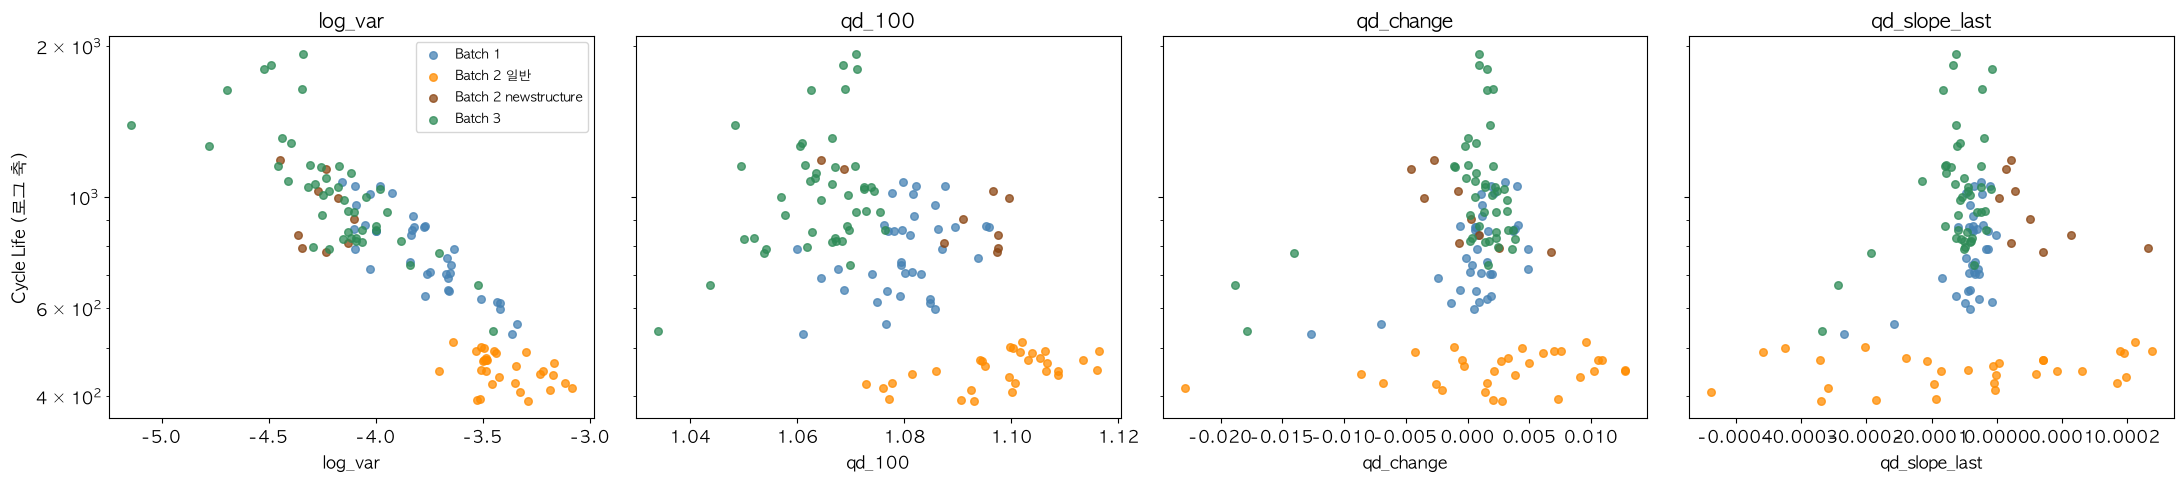

In [85]:
order = ['Batch 1', 'Batch 2 일반', 'Batch 2 newstructure', 'Batch 3']
plot_cols = ['log_var', 'qd_100', 'qd_change', 'qd_slope_last']

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, col in zip(axes, plot_cols):
    for name in order:
        g = feat5[feat5['group'] == name]
        ax.scatter(g[col], g['cycle_life'], color=gcolors[name], s=30, alpha=0.75, label=name)
    ax.set_yscale('log')
    ax.set_xlabel(col)
    ax.set_title(col)
axes[0].set_ylabel('Cycle Life (로그 축)')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q5_candidates.png'), dpi=150)
plt.show()

**결과 해석 — 후보 피처의 산점도**

- **`log_var`만 네 집단이 하나의 띠를 이룬다.** 분산이 작고 수명이 긴 쪽에서 분산이 크고 수명이 짧은 쪽으로 이어진다. Batch 2 일반 셀이 띠보다 조금 아래에 있는 것은 Q3-6에서 확인한 대로다.
- **`qd_100`은 집단 안과 집단 사이의 관계가 반대다.** 상관표에서는 세 집단 모두 양수였지만(+0.35, +0.55, +0.33), 산점도에서는 `qd_100`이 가장 큰 Batch 2 일반 셀이 수명이 가장 짧고, 작은 편인 Batch 3 셀이 수명이 길다. Batch 1에서 "용량이 클수록 수명이 길다"를 학습하면 Batch 2 일반 셀을 가장 길다고 예측하게 된다.
- **`qd_change`와 `qd_slope_last`는 대부분의 셀이 0 근처에 몰려 있다.** Batch 1과 Batch 3은 값이 거의 같은데 수명은 550~1,900으로 퍼져 세로 기둥 모양이다. Batch 1의 상관(+0.55, +0.50)은 왼쪽으로 떨어진 소수의 셀이 만든 것으로 보인다.
- Batch 2 일반 셀은 `qd_change`와 `qd_slope_last`가 가로로 넓게 퍼져 있지만 수명은 400~500으로 거의 같다. 이 집단에서는 두 피처가 수명을 구분하지 못한다.

**시사점**
- **상관표에서 부호가 일치해도 피처로 쓸 수 있다는 뜻은 아니다.** 상관표는 집단 안의 관계만 보여 준다. `qd_100`처럼 집단 사이에서 관계가 반대인 피처는 다른 배치에 적용하면 예측 방향이 틀린다.
- 피처를 고르는 기준은 세 가지를 모두 만족해야 한다.
  1. 학습 배치에서 수명과 관련이 있다
  2. 다른 집단 안에서도 같은 방향이다
  3. 집단 사이에서도 같은 관계 위에 놓인다
- 세 기준을 모두 만족하는 것은 ΔQ 피처다. 방전 용량 피처는 3번에서 탈락하거나(`qd_100`) 소수의 셀에 의존한다(`qd_change`, `qd_slope_last`).

### Q5-4. 피처 간 상관 (다중공선성)

**목적**: 피처끼리 서로 얼마나 중복되는지 확인하고, 함께 쓸 피처를 정한다.
- ΔQ 피처 세 개(`log_var`, `log_min`, `log_mean`)는 서로 다른 정보를 담고 있는가
- 상관이 높은 피처 쌍은 무엇인가
- `log_var`와 중복이 적으면서 함께 쓸 만한 피처가 있는가

학습에 쓸 Batch 1(36셀)을 기준으로 계산한다. 선형 모델은 서로 강하게 상관된 피처를 함께 넣으면 계수가 불안정해지고, 표본이 작을수록 그 영향이 크다.

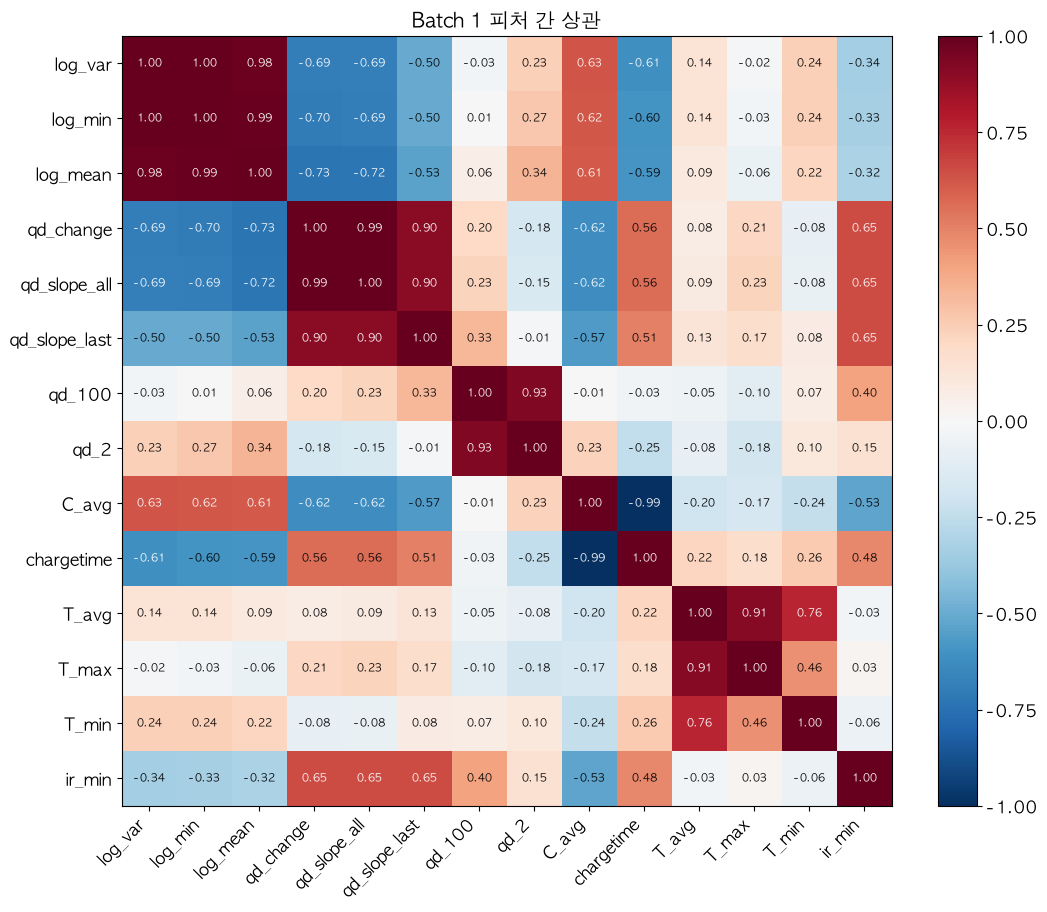

In [86]:
mc_cols = ['log_var', 'log_min', 'log_mean',
           'qd_change', 'qd_slope_all', 'qd_slope_last', 'qd_100', 'qd_2',
           'C_avg', 'chargetime', 'T_avg', 'T_max', 'T_min', 'ir_min']

b1f = feat5[feat5['group'] == 'Batch 1']
cm = b1f[mc_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(cm.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(mc_cols)))
ax.set_xticklabels(mc_cols, rotation=45, ha='right')
ax.set_yticks(range(len(mc_cols)))
ax.set_yticklabels(mc_cols)
for i in range(len(mc_cols)):
    for j in range(len(mc_cols)):
        v = cm.iloc[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(v) > 0.6 else 'black')
ax.set_title('Batch 1 피처 간 상관')
fig.colorbar(im, ax=ax, fraction=0.046)
plt.savefig(os.path.join(FIG_DIR, 'q5_multicollinearity.png'), dpi=150, bbox_inches='tight')
plt.show()

**결과 해석 — 피처 간 상관 (히트맵)**

**피처는 다섯 묶음으로 나뉜다**
- **ΔQ 피처**: `log_var`–`log_min` 1.00, `log_var`–`log_mean` 0.98, `log_min`–`log_mean` 0.99. 세 피처는 사실상 같은 정보다.
- **방전 용량의 변화**: `qd_change`–`qd_slope_all` 0.99, 두 피처와 `qd_slope_last` 0.90.
- **방전 용량의 수준**: `qd_100`–`qd_2` 0.93.
- **충전 조건**: `C_avg`–`chargetime` −0.99.
- **온도**: `T_avg`–`T_max` 0.91, `T_avg`–`T_min` 0.76.

**묶음 사이의 관계**
- ΔQ 피처와 용량 변화 피처는 −0.69 ~ −0.73으로 상당히 겹친다. 용량 변화 피처는 `log_var`가 가진 정보의 일부를 다시 담고 있다.
- ΔQ 피처와 충전 조건은 약 ±0.6이다. 빠르게 충전한 셀일수록 ΔQ 분산이 크다. 충전 조건이 수명에 주는 영향의 상당 부분이 ΔQ에 이미 반영되어 있다.
- 용량 변화 묶음 중 `qd_slope_last`가 `log_var`와의 중복이 가장 적다(−0.50).
- `qd_100`(−0.03)과 온도(0.02~0.24)는 `log_var`와 거의 무관하다.

**시사점**
- **ΔQ 피처는 하나만 쓴다.** 세 피처의 상관이 0.98~1.00이어서 함께 넣으면 계수가 불안정해진다. `log_var`를 고른다. 세 집단에서 상관이 가장 강했고(Q5-2), `log_min`은 스파이크 한 점에 값이 크게 달라졌다(Q3-4).
- **충전 정책 피처를 제외해도 잃는 정보가 크지 않다.** ΔQ 분산이 충전 조건과 0.6 수준으로 연결되어 있어, 충전 조건의 효과가 간접적으로 반영된다. Q4의 제외 결정을 뒷받침한다.
- `log_var`와 중복이 적은 피처(`qd_100`, 온도)는 다른 이유로 쓸 수 없다. `qd_100`은 집단 사이의 관계가 반대이고(Q5-3), 온도는 수명과의 상관이 거의 없고 측정 신뢰도가 낮다(Q5-1, Q5-2).
- **`log_var` 하나로 시작한다.** 두 번째 피처의 후보는 `qd_slope_last`이나 소수의 셀에 의존하는 모양이었으므로(Q5-3), 추가 여부는 DAY 2에 Batch 1 안의 교차검증으로 판단한다.

**상관이 높은 쌍**

히트맵에서 상관의 크기가 0.8 이상인 피처 쌍을 뽑고, 각 피처가 `log_var`와 얼마나 중복되는지 따로 정리한다.

In [87]:
pairs = []
for i, a in enumerate(mc_cols):
    for b in mc_cols[i + 1:]:
        if abs(cm.loc[a, b]) >= 0.8:
            pairs.append({'피처 1': a, '피처 2': b, '상관': round(cm.loc[a, b], 2)})
print('상관의 크기가 0.8 이상인 쌍')
print(pd.DataFrame(pairs).sort_values('상관', key=abs, ascending=False).to_string(index=False))

print()
print('log_var와의 상관 (Batch 1)')
print(cm['log_var'].drop('log_var').sort_values(key=abs, ascending=False).round(2))

상관의 크기가 0.8 이상인 쌍
        피처 1          피처 2    상관
     log_var       log_min  1.00
     log_min      log_mean  0.99
   qd_change  qd_slope_all  0.99
       C_avg    chargetime -0.99
     log_var      log_mean  0.98
      qd_100          qd_2  0.93
       T_avg         T_max  0.91
   qd_change qd_slope_last  0.90
qd_slope_all qd_slope_last  0.90

log_var와의 상관 (Batch 1)
log_min          1.00
log_mean         0.98
qd_change       -0.69
qd_slope_all    -0.69
C_avg            0.63
chargetime      -0.61
qd_slope_last   -0.50
ir_min          -0.34
T_min            0.24
qd_2             0.23
T_avg            0.14
qd_100          -0.03
T_max           -0.02
Name: log_var, dtype: float64


**결과 확인 — 상관이 높은 쌍**

- 상관의 크기가 0.8 이상인 쌍은 9개이고, 모두 같은 묶음 안의 피처끼리다. 묶음을 넘는 0.8 이상의 쌍은 없다.
- `log_var`와 거의 독립인 피처(상관 0.34 이하)는 `ir_min`, `T_min`, `qd_2`, `T_avg`, `qd_100`, `T_max`다. 이들은 중복 문제는 없지만 Q5-1 ~ Q5-3에서 다른 이유로 제외됐다(결측, 측정 신뢰도, 집단 사이의 관계 반대).
- `log_var`와 중간 정도로 겹치는 `qd_slope_last`(−0.50)가 두 번째 피처의 후보로 남는다.

### Q5 결론

**확인한 사실**
1. 초기 100사이클의 피처 16개를 계산하고 값을 점검했다. 내부 저항은 Batch 2의 6셀에서 전부 0이고 Batch 1의 b1c18에서 51개 사이클 동안 갱신되지 않았다. 온도는 0.0도로 기록된 행이 있어 제외했다. 이런 오류는 Batch 2 파일의 마지막 셀들(b2c41~b2c46)에 몰려 있다.
2. Batch 1에서 수명과 가장 강하게 연관된 피처는 ΔQ 피처다(`log_var` −0.84, `log_min` −0.83, `log_mean` −0.77). 세 집단 모두에서 부호가 같다.
3. Batch 1에서 그다음으로 강한 `C_avg`(−0.59)와 `chargetime`(+0.58)은 다른 집단에서 부호가 다르다.
4. 방전 용량 피처는 세 집단 안에서 부호가 같지만, 산점도에서는 문제가 드러난다. `qd_100`은 집단 사이의 관계가 반대이고(용량이 가장 큰 Batch 2 일반 셀이 수명이 가장 짧다), `qd_change`와 `qd_slope_last`는 대부분의 셀이 0 근처에 몰려 있어 소수의 셀이 상관을 만든다.
5. 온도 피처는 Batch 1에서 수명과의 상관이 거의 없다(−0.06 ~ −0.16).
6. Batch 2 일반 집단에서는 모든 피처의 상관이 약하다(`log_var`도 −0.38). 수명 범위가 392~514로 좁기 때문이다.
7. 피처는 다섯 묶음으로 나뉘고 묶음 안의 상관은 0.9 이상이다. ΔQ 피처 세 개는 0.98~1.00으로 사실상 같은 정보다.
8. `log_var`는 충전 조건과 약 ±0.6으로 연결되어 있다.

**모델 설계에 주는 시사점**
- **피처를 고르는 기준은 세 가지다.** (사실 2, 3, 4)
  1. 학습 배치에서 수명과 관련이 있다
  2. 다른 집단 안에서도 같은 방향이다
  3. 집단 사이에서도 같은 관계 위에 놓인다
- **세 기준을 모두 만족하는 것은 ΔQ 피처뿐이다.** 그중 `log_var` 하나를 쓴다. 세 피처가 같은 정보이므로 함께 넣으면 계수가 불안정해진다. (사실 2, 7)
- **제외하는 피처와 이유**
  - 충전 조건(`C_avg`, `chargetime`): 집단 간 부호가 다르고 테스트 배치에서 변동이 없다. ΔQ 분산에 그 효과가 간접적으로 반영되어 있어 제외해도 잃는 정보가 크지 않다. (사실 3, 8)
  - 방전 용량 수준(`qd_100`, `qd_2`): 집단 사이의 관계가 반대다. (사실 4)
  - 방전 용량 변화(`qd_change`, `qd_slope_all`): `log_var`와 −0.69로 겹치고 소수의 셀에 의존한다. (사실 4, 7)
  - 온도: 수명과의 상관이 거의 없고 측정 신뢰도가 낮다. (사실 1, 5)
  - 내부 저항: 테스트 배치에 결측이 6셀 있고 학습 배치에도 신뢰할 수 없는 값이 있다. (사실 1)
- **두 번째 피처의 후보는 `qd_slope_last`다.** `log_var`와의 중복이 중간 정도(−0.50)다. 다만 소수의 셀에 의존하는 모양이었으므로, 추가 여부는 Batch 1 안의 교차검증으로 판단한다. (사실 4, 7)
- **상관은 성격이 같은 집단 안에서 계산하고, 산점도로 확인한다.** 집단을 섞어 계산하면 관계가 과장되거나 부호가 뒤집힌다. 상관표에서 통과한 피처도 집단 사이에서는 관계가 다를 수 있다. (사실 4, Q2-6 정정)
- 학습 셀이 36개이고 쓸 수 있는 피처가 1~2개이므로, 단순한 선형 모델이 적합하다.

**테스트 성능에 대한 예상**
- Batch 2 일반 집단은 `log_var`와 수명의 상관이 약하고(사실 6), Batch 1의 관계보다 아래로 이동해 있다(Q3-6). 이 집단에서는 편향(약 31% 과대예측)이 오차의 대부분을 차지할 것으로 예상한다.